In [1]:
# MODEL: GARCH(1,1)
# DISTRIBUTION: Normal (Gaussian) Distribution

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ETH 1D GARCH ANALYSIS - WALK-FORWARD VALIDATION")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA AND CALCULATE RETURNS
# ============================================================================
print("\n[1/7] Loading data and calculating returns...")

raw = np.load("stocks_500.npy", allow_pickle=True).item()
data = {}

for key, df in raw.items():
    stock = key.replace('.csv', '')
    data[stock] = df

frames = []

for stock, df in data.items():
    # 把 index（日期）变成一列
    df = df.reset_index().rename(columns={'index': 'timestamp'})
    # 将日期转换为 datetime，与 sample 完全一致
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    # 加入股票列
    df['stock'] = stock
    df = df.sort_values('timestamp').reset_index(drop=True)
    # Calculate log returns (in %)
    df['returns'] = np.log(df['close'] / df['close'].shift(1)) * 100
    df = df.dropna(subset=['returns'])  # Drop the first row (NaN)
    df['realized_var'] = df['returns'] ** 2

    frames.append(df)




df=frames[6] #选择想处理的股票

print(f"✓ Total observations: {len(df)}")
print(f"✓ Date range: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
print(f"✓ Price range: ${df['close'].min():.2f} → ${df['close'].max():.2f}")

# Return statistics
print(f"\n📊 Return Statistics:")
print(f"    Mean: {df['returns'].mean():.4f}%")
print(f"    Std Dev: {df['returns'].std():.4f}%")
print(f"    Min: {df['returns'].min():.4f}%")
print(f"    Max: {df['returns'].max():.4f}%")
print(f"    Skewness: {df['returns'].skew():.4f}")
print(f"    Kurtosis: {df['returns'].kurtosis():.4f}")

# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (80%-20%)
# ============================================================================
print("\n[2/7] Splitting data (80% train - 20% test)...")

returns_series = df['returns']
rv_series = df['realized_var']   #平方项
train_size = int(len(returns_series) * 0.8)

train_returns = returns_series.iloc[:train_size]
test_returns = returns_series.iloc[train_size:]

train_rv = rv_series.iloc[:train_size]  #平方项
test_rv  = rv_series.iloc[train_size:] 

# Rolling window size (used for naive baseline)
vol_window = 20  

print(f"✓ Training set: {train_size} observations")
print(f"✓ Test set: {len(test_returns)} observations")
print(f"✓ Test period: {df['timestamp'].iloc[train_size]} → {df['timestamp'].iloc[-1]}")

# ============================================================================
# STEP 3: TRAIN BASELINE GARCH(1,1) MODEL
# ============================================================================
print("\n[3/7] Training baseline GARCH(1,1) model...")

# Train the initial model 
baseline_model = arch_model(train_returns, vol='GARCH', p=1, q=1, rescale=False)
baseline_fitted = baseline_model.fit(disp='off')

print(f"\n📊 GARCH(1,1) Model Parameters (Baseline on Train Set):")
print(f"    ω (omega): {baseline_fitted.params['omega']:.6f}")
print(f"    α (alpha): {baseline_fitted.params['alpha[1]']:.6f}")
print(f"    β (beta):  {baseline_fitted.params['beta[1]']:.6f}")
print(f"\n    Volatility Persistence (α + β): {baseline_fitted.params['alpha[1]'] + baseline_fitted.params['beta[1]']:.6f}")

if baseline_fitted.params['alpha[1]'] + baseline_fitted.params['beta[1]'] < 1.0:
    print("    ✅ Model is stationary (α + β < 1)")
else:
    print("    ⚠️ Model is not stationary (α + β ≥ 1)")

# ============================================================================
# STEP 4: WALK-FORWARD VALIDATION
# ============================================================================
print("\n[4/7] Starting walk-forward validation...")
print("      (GARCH model will be refit at each step)")

# Store predictions
predictions_var = []
actual_var = []
naive_var = []
final_fitted_model = None

# For each test point
for i in range(len(test_returns)):
    # Current training data (train + test up to this point)
    if i > 0:
        history = np.concatenate([train_returns, test_returns[:i]])
        rv_history = np.concatenate([train_rv, actual_var[:i]])
    else:
        history = train_returns
        rv_history = train_rv
    
    try:
        # Train GARCH(1,1) model
        model = arch_model(history, vol='GARCH', p=1, q=1, rescale=False)
        fitted = model.fit(disp='off')
        final_fitted_model = fitted 
        
        # 1-step ahead volatility forecast
        forecast = fitted.forecast(horizon=1, reindex=False)
        predicted_variance = float(forecast.variance.values[-1, 0])
        predictions_var.append(predicted_variance)

        
        # ACTUAL VOLATILITY: Simple proxy (absolute return)
        actual_var.append(float(test_rv.iloc[i]))

        
        # NAIVE FORECAST: Mean of all actual volatility seen so far
        window = rv_history[-vol_window:]# 过去 vol_window 个 realized_var 的均值
        naive_pred = float(np.mean(window))
        naive_var.append(naive_pred)

        
    except Exception as e:
        print(f"    ⚠️ Error at step {i+1}: {str(e)[:50]}")
        # In case of error, use the last known volatility
        if len(predictions_var) > 0:
            predictions_var.append(predictions_var[-1])
        else:
            # For the very first prediction, use train volatility
            predictions_var.append(np.mean(np.abs(train_returns[-vol_window:])))
        
        actual_var.append(abs(test_returns[i])**2)
        
        if i > 0:
            naive_var.append(np.mean(actual_var[:i]))
        else:
            naive_var.append(np.mean(np.abs(train_returns[-vol_window:])))
    
    # Show progress
    if (i + 1) % 10 == 0 or i == len(test_returns) - 1:
        print(f"    Progress: {i+1}/{len(test_returns)} completed")

predictions_var = np.array(predictions_var)
actual_var = np.array(actual_var)
naive_var = np.array(naive_var)

# ============================================================================
# STEP 5: PERFORMANCE METRICS  (Variance-level, aligned with GARCH)
# ============================================================================
print("\n[5/7] Calculating performance metrics...")

# Ensure numpy arrays
actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Safety: avoid zeros in denominators / logs
eps = 1e-12
pred_var_safe = np.maximum(predictions_var, eps)
naive_var_safe = np.maximum(naive_var, eps)

# --------------------
# Metrics on variance
# --------------------
rmse_var = np.sqrt(mean_squared_error(actual_var, predictions_var))
mae_var = mean_absolute_error(actual_var, predictions_var)
mape_var = np.mean(np.abs((actual_var - predictions_var) / (actual_var + eps))) * 100

# QLIKE (standard for variance forecasting)
qlike_garch = np.mean(actual_var / pred_var_safe + np.log(pred_var_safe))
qlike_naive = np.mean(actual_var / naive_var_safe + np.log(naive_var_safe))

# Out-of-sample R² relative to naive baseline (Campbell-Thompson style)
ss_res = np.sum((actual_var - predictions_var) ** 2)
ss_tot = np.sum((actual_var - naive_var) ** 2)
r2_oos = 1 - (ss_res / ss_tot)

# Naive model performance (variance)
naive_rmse_var = np.sqrt(mean_squared_error(actual_var, naive_var))
naive_mae_var = mean_absolute_error(actual_var, naive_var)

print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target: r^2 proxy):")
print(f"    GARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline (Rolling Mean of r^2):")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):.2f}%")

# --------------------
# Descriptive stats
# --------------------
print(f"\n📊 Variance Statistics (Test Set):")
print(f"    Actual variance proxy (r^2):")
print(f"    • Mean: {np.mean(actual_var):.6f}")
print(f"    • Std:  {np.std(actual_var):.6f}")
print(f"    • Min:  {np.min(actual_var):.6f}")
print(f"    • Max:  {np.max(actual_var):.6f}")

print(f"\n    GARCH predicted variance (sigma^2):")
print(f"    • Mean: {np.mean(predictions_var):.6f}")
print(f"    • Std:  {np.std(predictions_var):.6f}")

print(f"\n    Naive predicted variance:")
print(f"    • Mean: {np.mean(naive_var):.6f}")
print(f"    • Std:  {np.std(naive_var):.6f}")

# Optional: also report volatility-level (std) for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol = np.sqrt(np.maximum(predictions_var, 0))
naive_vol = np.sqrt(np.maximum(naive_var, 0))

print(f"\n📌 (Optional) Volatility-level summary (sqrt of variance):")
print(f"    Actual vol proxy:")
print(f"    • Mean: {np.mean(actual_vol):.6f}")
print(f"    • Std:  {np.std(actual_vol):.6f}")
print(f"    GARCH predicted vol:")
print(f"    • Mean: {np.mean(pred_vol):.6f}")
print(f"    • Std:  {np.std(pred_vol):.6f}")
print(f"    Naive predicted vol:")
print(f"    • Mean: {np.mean(naive_vol):.6f}")
print(f"    • Std:  {np.std(naive_vol):.6f}")

# ============================================================================
# STEP 6: VISUALIZATION (aligned)
# ============================================================================
print("\n[6/7] Generating plots...")

# Ensure numpy
train_returns_np = np.asarray(train_returns, dtype=float)  # Series/ndarray都可
test_returns_np  = np.asarray(test_returns, dtype=float)

actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Convert variance -> volatility for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol   = np.sqrt(np.maximum(predictions_var, 0))
naive_vol  = np.sqrt(np.maximum(naive_var, 0))

# A consistent "train volatility proxy" for the full-series plot
train_vol_proxy = np.sqrt(np.maximum((train_returns_np**2), 0))  # = abs(train_returns)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# 1. Full series: volatility proxy + forecasts on test
train_x = np.arange(len(train_vol_proxy))
test_x = np.arange(len(train_vol_proxy), len(train_vol_proxy) + len(actual_vol))

axes[0, 0].plot(train_x, train_vol_proxy, label='Train (Vol. Proxy |r|)',
                alpha=0.5, linewidth=1)
axes[0, 0].plot(test_x, actual_vol, label='Test (Vol. Proxy sqrt(r²))',
                linewidth=1.5)
axes[0, 0].plot(test_x, pred_vol, label='GARCH Forecast (sigma)',
                linestyle='--', linewidth=2)
axes[0, 0].plot(test_x, naive_vol, label='Naive Baseline (sqrt of rolling r²)',
                linestyle=':', linewidth=2, alpha=0.7)
axes[0, 0].axvline(x=len(train_vol_proxy), color='black', linestyle=':', linewidth=2)
axes[0, 0].set_title('GARCH(1,1) Volatility Forecast - Walk-Forward', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Time (Index)')
axes[0, 0].set_ylabel('Volatility (%, proxy)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Test detail (volatility scale)
axes[0, 1].plot(actual_vol, label='Actual (sqrt r²)',
                linewidth=2, marker='o', markersize=4)
axes[0, 1].plot(pred_vol, label='GARCH Forecast (sigma)',
                linewidth=2, marker='s', markersize=4)
axes[0, 1].plot(naive_vol, label='Naive Baseline',
                linewidth=2, marker='^', markersize=4, alpha=0.7)
axes[0, 1].fill_between(range(len(actual_vol)), actual_vol, pred_vol, alpha=0.2)
axes[0, 1].set_title(
    f'Test Set Detail (variance-aligned eval)  RMSE_var: {rmse_var:.6f}, Naive: {naive_rmse_var:.6f}',
    fontweight='bold', fontsize=11
)
axes[0, 1].set_xlabel('Test Index')
axes[0, 1].set_ylabel('Volatility (%, proxy)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Error distribution (variance level is more principled)
errors_var = predictions_var - actual_var 
axes[1, 0].hist(errors_var, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, linestyle='--', linewidth=2)
axes[1, 0].axvline(x=np.mean(errors_var), linestyle='--', linewidth=2,
                   label=f'Mean Error: {np.mean(errors_var):.6f}')
axes[1, 0].set_title(f'Variance Forecast Error Distribution (Std: {np.std(errors_var):.6f})',
                     fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Error (variance units)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter plot (variance)
axes[1, 1].scatter(actual_var, predictions_var, alpha=0.6, s=50)
minv = min(actual_var.min(), predictions_var.min())
maxv = max(actual_var.max(), predictions_var.max())
axes[1, 1].plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Perfect Forecast')
axes[1, 1].set_title(f'Actual vs. Predicted Variance (R²_oos={r2_oos:.3f})',
                     fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Actual (r² proxy)')
axes[1, 1].set_ylabel('Predicted (sigma²)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Returns time series
test_x_returns = np.arange(len(test_returns_np))
axes[2, 0].plot(test_x_returns, test_returns_np, linewidth=1.5)
axes[2, 0].axhline(y=0, linestyle='--', linewidth=1)
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np > 0), alpha=0.3, label='Positive')
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np <= 0), alpha=0.3, label='Negative')
axes[2, 0].set_title('Test Set: Returns Series', fontweight='bold', fontsize=12)
axes[2, 0].set_xlabel('Test Index')
axes[2, 0].set_ylabel('Return (%)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Volatility clustering (variance view)
squared_returns = test_returns_np ** 2
axes[2, 1].plot(squared_returns, linewidth=1.5, alpha=0.7, label='Observed (r²)')
axes[2, 1].plot(predictions_var, linewidth=2, linestyle='--', label='GARCH Forecast (sigma²)')
axes[2, 1].plot(naive_var, linewidth=2, linestyle=':', alpha=0.7, label='Naive (rolling r²)')
axes[2, 1].set_title('Volatility Proxy vs Forecasted Variance', fontweight='bold', fontsize=12)
axes[2, 1].set_xlabel('Test Index')
axes[2, 1].set_ylabel('Variance (%²)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('garch_1d_walkforward_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved: garch_1d_walkforward_analysis.png")
plt.show()

# ============================================================================
# STEP 7: SUMMARY REPORT (Variance-aligned)
# ============================================================================
print("\n" + "="*80)
print("📋 SUMMARY REPORT - 1D GARCH(1,1) WALK-FORWARD VALIDATION (Variance-aligned)")
print("="*80)

print(f"\n📁 DATA:")
print(f"    • Total observations: {len(df)}")
print(f"    • Test period: {len(test_returns)} candles (~{len(test_returns)} days)")
print(f"    • Mean return: {df['returns'].mean():.4f}%")
print(f"    • Return std (unconditional): {df['returns'].std():.4f}%")
print(f"    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)")

print(f"\n🔧 MODEL:")
print(f"    • GARCH(1,1) with Gaussian innovations (default)")

# Parameters
if final_fitted_model is not None:
    params = final_fitted_model.params
    print(f"    • Parameters (from final walk-forward fitted model):")
else:
    params = baseline_fitted.params
    print(f"    • Parameters (from baseline model - WARNING: walk-forward loop may have failed):")

omega = float(params.get('omega', np.nan))
alpha = float(params.get('alpha[1]', np.nan))
beta  = float(params.get('beta[1]', np.nan))

print(f"      - ω: {omega:.6f}")
print(f"      - α: {alpha:.6f}")
print(f"      - β: {beta:.6f}")

persistence = alpha + beta
print(f"    • Volatility persistence (α+β): {persistence:.4f}")
print(f"    • Validation: Walk-Forward (expanding window; no data leakage)")
print(f"    • Baseline: Rolling mean of r² (variance proxy)")

# Metrics (variance-level)
print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):")
print(f"    GARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline:")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):+.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):+.2f}%")

print(f"\n💡 EVALUATION:")

# RMSE evaluation (variance-level)
rmse_improvement = ((naive_rmse_var - rmse_var) / naive_rmse_var * 100)
if rmse_improvement > 10:
    print(f"    ✅ GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (substantial)")
elif rmse_improvement > 5:
    print(f"    ✓ GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (moderate)")
elif rmse_improvement > 0:
    print(f"    ⚠️ GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (slight)")
else:
    print(f"    ❌ GARCH worsens RMSE by {abs(rmse_improvement):.1f}% vs naive")

# R²_oos evaluation (variance-level)
if r2_oos > 0.3:
    print(f"    ✅ R²_oos={r2_oos:.3f} - substantially better than naive")
elif r2_oos > 0.1:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - moderately better than naive")
elif r2_oos > 0:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - only slightly better than naive")
else:
    print(f"    ❌ R²_oos={r2_oos:.3f} - worse than naive")

# Parameter interpretation
if persistence > 0.95:
    print("    ⚠️ High persistence: volatility shocks decay very slowly")
elif persistence > 0.85:
    print("    ✓ Moderate persistence: shocks decay gradually")
else:
    print("    ✅ Low persistence: shocks decay relatively quickly")

if alpha > beta:
    print("    • ARCH effect dominant: higher sensitivity to recent shocks")
else:
    print("    • GARCH effect dominant: volatility persistence matters more")

# MAPE caveat (variance)
print("    • Note: MAPE on variance proxies can be unstable when actual_var is near zero; prefer QLIKE for variance forecasts.")

print(f"\n📈 VOLATILITY CLUSTERING (proxy-based):")
# squared_returns should be defined as test_returns**2 in your Step 6 or earlier
acorr_sq_returns = np.corrcoef(squared_returns[:-1], squared_returns[1:])[0, 1]
print(f"    • Squared returns autocorrelation (lag-1): {acorr_sq_returns:.4f}")
if acorr_sq_returns > 0.1:
    print("    ✅ Volatility clustering is present (ARCH-type modeling is plausible)")
else:
    print("    ⚠️ Weak clustering at lag-1 (GARCH may add limited value vs smoothing baselines)")

# Optional: show volatility-scale summary (sqrt(var)) for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol   = np.sqrt(np.maximum(predictions_var, 0))
naive_vol  = np.sqrt(np.maximum(naive_var, 0))

print(f"\n📌 (Optional) VOLATILITY-LEVEL SUMMARY (sqrt of variance proxy):")
print(f"    Actual vol proxy:")
print(f"    • Mean: {np.mean(actual_vol):.6f}")
print(f"    • Std:  {np.std(actual_vol):.6f}")
print(f"    GARCH predicted vol:")
print(f"    • Mean: {np.mean(pred_vol):.6f}")
print(f"    • Std:  {np.std(pred_vol):.6f}")
print(f"    Naive predicted vol:")
print(f"    • Mean: {np.mean(naive_vol):.6f}")
print(f"    • Std:  {np.std(naive_vol):.6f}")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

print("\n💡 NEXT STEPS:")
print("    • Try EGARCH / GJR-GARCH (leverage asymmetry)")
print("    • Test alternative (p,q): e.g., GARCH(2,1), GARCH(1,2)")
print("    • Use heavy-tailed innovations: dist='t'")
print("    • Consider exogenous regressors (GARCH-X): volume, market factor, event dummies")
print("    • Evaluate risk metrics: VaR / ES backtesting")

ETH 1D GARCH ANALYSIS - WALK-FORWARD VALIDATION

[1/7] Loading data and calculating returns...


FileNotFoundError: [Errno 2] No such file or directory: 'stocks_500.npy'

ETH 1D GARCH ANALYSIS (Student's t-Dist) - WALK-FORWARD VALIDATION

[1/7] Loading data and calculating returns...
✓ Total observations: 1401
✓ Date range: 2020-01-03 00:00:00 → 2025-10-17 00:00:00
✓ Price range: $40.64 → $197.02

📊 Return Statistics:
    Mean: 0.0619%
    Std Dev: 3.8496%
    Min: -18.8403%
    Max: 18.2346%
    Skewness: 0.4159
    Kurtosis: 3.0958

[2/7] Splitting data (80% train - 20% test)...
✓ Training set: 1120 observations
✓ Test set: 281 observations
✓ Test period: 2024-08-16 00:00:00 → 2025-10-17 00:00:00

[3/7] Training baseline GARCH(1,1) model (with Student's t-Dist)...

📊 GARCH(1,1) - Student's t-Distribution (Baseline Model):
    ω (omega): 0.020261
    α (alpha): 0.018494
    β (beta):  0.979246
    ν (nu): 6.639447  [Degrees of Freedom for t-Dist]

    📊 Distribution Shape:
    ✓ Fat tails (ν=6.64)
    → Extreme events are more frequent than normal
    ✅ Model is stationary (α + β < 1)

[4/7] Starting walk-forward validation (dist='t')...
      (GARCH m

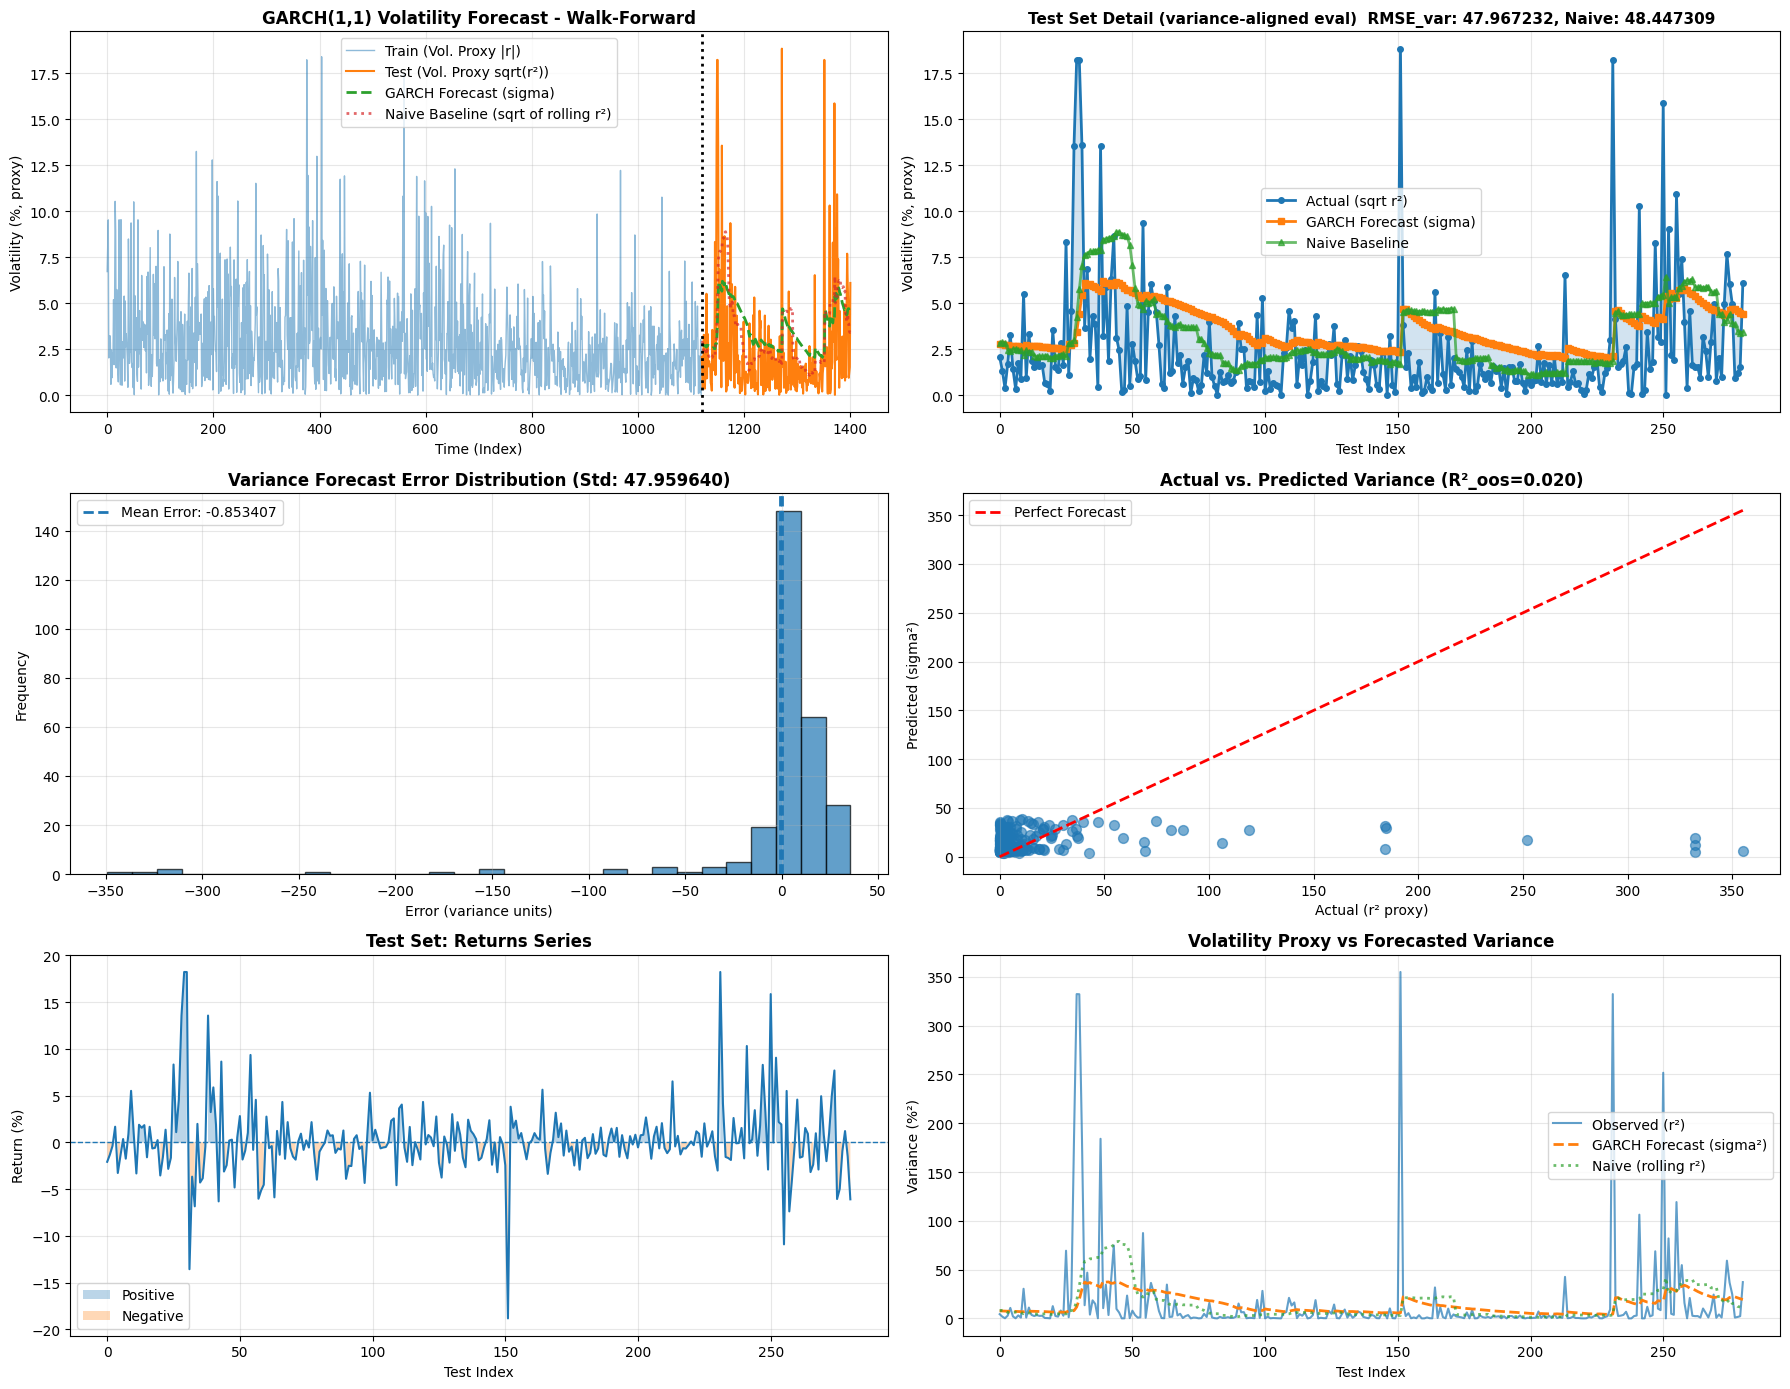


📋 SUMMARY REPORT - 1D GARCH(1,1) WALK-FORWARD VALIDATION (Variance-aligned)

📁 DATA:
    • Total observations: 1401
    • Test period: 281 candles (~281 days)
    • Mean return: 0.0619%
    • Return std (unconditional): 3.8496%
    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)

🔧 MODEL:
    • GARCH(1,1) with Student's t-Distribution
    • Parameters (from final walk-forward model):
      - ω: 0.111826
      - α: 0.045687
      - β: 0.948771
      - ν: 4.564358 (Degrees of Freedom)
    • Volatility persistence (α+β): 0.9945
    • Validation: Walk-Forward (no data leakage)
    • Baseline: Rolling mean of abs(returns)

📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):
    GARCH Model:
    • RMSE (var): 47.967232
    • MAE  (var): 19.244866
    • MAPE (var): 126562.09%
    • QLIKE:      3.857355

    Naive Baseline:
    • RMSE (var): 48.447309
    • MAE  (var): 19.683864
    • QLIKE:      3.987336

    Comparison:
    • R² (Out-of-Sample, vs N

In [ ]:
# MODEL: GARCH(1,1)
# DISTRIBUTION: Student's t-Distribution (dist='t')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ETH 1D GARCH ANALYSIS (Student's t-Dist) - WALK-FORWARD VALIDATION")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA AND CALCULATE RETURNS
# ============================================================================
print("\n[1/7] Loading data and calculating returns...")

raw = np.load("stocks_500.npy", allow_pickle=True).item()
data = {}

for key, df in raw.items():
    stock = key.replace('.csv', '')
    data[stock] = df

frames = []

for stock, df in data.items():
    # 把 index（日期）变成一列
    df = df.reset_index().rename(columns={'index': 'timestamp'})
    # 将日期转换为 datetime，与 sample 完全一致
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    # 加入股票列
    df['stock'] = stock
    df = df.sort_values('timestamp').reset_index(drop=True)
    # Calculate log returns (in %)
    df['returns'] = np.log(df['close'] / df['close'].shift(1)) * 100
    df = df.dropna(subset=['returns'])  # Drop the first row (NaN)
    df['realized_var'] = df['returns'] ** 2

    frames.append(df)




df=frames[6] #选择想处理的股票

print(f"✓ Total observations: {len(df)}")
print(f"✓ Date range: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
print(f"✓ Price range: ${df['close'].min():.2f} → ${df['close'].max():.2f}")

# Return statistics
print(f"\n📊 Return Statistics:")
print(f"    Mean: {df['returns'].mean():.4f}%")
print(f"    Std Dev: {df['returns'].std():.4f}%")
print(f"    Min: {df['returns'].min():.4f}%")
print(f"    Max: {df['returns'].max():.4f}%")
print(f"    Skewness: {df['returns'].skew():.4f}")
print(f"    Kurtosis: {df['returns'].kurtosis():.4f}")

# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (80%-20%)
# ============================================================================
print("\n[2/7] Splitting data (80% train - 20% test)...")

returns_series = df['returns']
rv_series = df['realized_var']   #平方项
train_size = int(len(returns_series) * 0.8)

train_returns = returns_series.iloc[:train_size]
test_returns = returns_series.iloc[train_size:]

train_rv = rv_series.iloc[:train_size]  #平方项
test_rv  = rv_series.iloc[train_size:] 

# Rolling window size (used for naive baseline)
vol_window = 20  

print(f"✓ Training set: {train_size} observations")
print(f"✓ Test set: {len(test_returns)} observations")
print(f"✓ Test period: {df['timestamp'].iloc[train_size]} → {df['timestamp'].iloc[-1]}")

# ============================================================================
# STEP 3: TRAIN BASELINE GARCH(1,1) MODEL (with Student's t-Dist)
# ============================================================================
print("\n[3/7] Training baseline GARCH(1,1) model (with Student's t-Dist)...")

# Train the initial model using 'dist=t'
baseline_model = arch_model(train_returns, vol='GARCH', p=1, q=1,
                            dist='t',  # <-- Use Student's t-distribution
                            rescale=False)
baseline_fitted = baseline_model.fit(disp='off')

print(f"\n📊 GARCH(1,1) - Student's t-Distribution (Baseline Model):")
print(f"    ω (omega): {baseline_fitted.params['omega']:.6f}")
print(f"    α (alpha): {baseline_fitted.params['alpha[1]']:.6f}")
print(f"    β (beta):  {baseline_fitted.params['beta[1]']:.6f}")

# Check for and print the 'nu' parameter (degrees of freedom for t-dist)
if 'nu' in baseline_fitted.params.index:
    nu = baseline_fitted.params['nu']
    print(f"    ν (nu): {nu:.6f}  [Degrees of Freedom for t-Dist]")
    
    # Add interpretation for nu:
    print(f"\n    📊 Distribution Shape:")
    if nu < 5:
        print(f"    ⚠️ Very fat tails (ν={nu:.2f})")
        print(f"    → Extreme events are very frequent!")
    elif nu < 10:
        print(f"    ✓ Fat tails (ν={nu:.2f})")
        print(f"    → Extreme events are more frequent than normal")
    elif nu < 30:
        print(f"    ✅ Moderately fat tails (ν={nu:.2f})")
    else:
        print(f"    ✅ Very close to Normal distribution (ν={nu:.2f})")
else:
    print(f"    ⚠️ 'nu' parameter not found.")

if baseline_fitted.params['alpha[1]'] + baseline_fitted.params['beta[1]'] < 1.0:
    print("    ✅ Model is stationary (α + β < 1)")
else:
    print("    ⚠️ Model is not stationary (α + β ≥ 1)")

# ============================================================================
# STEP 4: WALK-FORWARD VALIDATION
# ============================================================================
print("\n[4/7] Starting walk-forward validation (dist='t')...")
print("      (GARCH model will be refit at each step)")

# Store predictions
predictions_var = []
actual_var = []
naive_var = []
final_fitted_model = None

# For each test point
for i in range(len(test_returns)):
    # Current training data (train + test up to this point)
    if i > 0:
        history = np.concatenate([train_returns, test_returns[:i]])
        rv_history = np.concatenate([train_rv, actual_var[:i]])
    else:
        history = train_returns
        rv_history = train_rv
    
    try:
        # Train GARCH(1,1) model with t-distribution
        model = arch_model(history, vol='GARCH', p=1, q=1,
                           dist='t',  # <-- Use Student's t-distribution
                           rescale=False)
        fitted = model.fit(disp='off')
        final_fitted_model = fitted 
        
        # 1-step ahead volatility forecast
        forecast = fitted.forecast(horizon=1, reindex=False)
        predicted_variance = forecast.variance.values[-1, 0]
        predictions_var.append(predicted_variance)
        
        # ACTUAL VOLATILITY: Simple proxy (absolute return)
        actual_var.append(float(test_rv.iloc[i]))

        # NAIVE FORECAST: Mean of all actual volatility seen so far
        window = rv_history[-vol_window:]# 过去 vol_window 个 realized_var 的均值
        naive_pred = float(np.mean(window))
        naive_var.append(naive_pred)
        
    except Exception as e:
        print(f"    ⚠️ Error at step {i+1}: {str(e)[:50]}")
        # In case of error, use the last known volatility
        if len(predictions_var) > 0:
            predictions_var.append(predictions_var[-1])
        else:
            # For the very first prediction, use train volatility
            predictions_var.append(np.mean(np.abs(train_returns[-vol_window:])))
        
        actual_var.append(abs(test_returns[i])**2)
        
        if i > 0:
            naive_var.append(np.mean(actual_var[:i]))
        else:
            naive_var.append(np.mean(np.abs(train_returns[-vol_window:])))
    
    # Show progress
    if (i + 1) % 10 == 0 or i == len(test_returns) - 1:
        print(f"    Progress: {i+1}/{len(test_returns)} completed")

predictions_var = np.array(predictions_var)
actual_var = np.array(actual_var)
naive_var = np.array(naive_var)

# ============================================================================
# STEP 5: PERFORMANCE METRICS
# ============================================================================
print("\n[5/7] Calculating performance metrics...")

# Ensure numpy arrays
actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Safety: avoid zeros in denominators / logs
eps = 1e-12
pred_var_safe = np.maximum(predictions_var, eps)
naive_var_safe = np.maximum(naive_var, eps)

# --------------------
# Metrics on variance
# --------------------
rmse_var = np.sqrt(mean_squared_error(actual_var, predictions_var))
mae_var = mean_absolute_error(actual_var, predictions_var)
mape_var = np.mean(np.abs((actual_var - predictions_var) / (actual_var + eps))) * 100

# QLIKE (standard for variance forecasting)
qlike_garch = np.mean(actual_var / pred_var_safe + np.log(pred_var_safe))
qlike_naive = np.mean(actual_var / naive_var_safe + np.log(naive_var_safe))

# Out-of-sample R² relative to naive baseline (Campbell-Thompson style)
ss_res = np.sum((actual_var - predictions_var) ** 2)
ss_tot = np.sum((actual_var - naive_var) ** 2)
r2_oos = 1 - (ss_res / ss_tot)

# Naive model performance (variance)
naive_rmse_var = np.sqrt(mean_squared_error(actual_var, naive_var))
naive_mae_var = mean_absolute_error(actual_var, naive_var)

print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target: r^2 proxy):")
print(f"    GARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline (Rolling Mean of r^2):")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):.2f}%")

# --------------------
# Descriptive stats
# --------------------
print(f"\n📊 Variance Statistics (Test Set):")
print(f"    Actual variance proxy (r^2):")
print(f"    • Mean: {np.mean(actual_var):.6f}")
print(f"    • Std:  {np.std(actual_var):.6f}")
print(f"    • Min:  {np.min(actual_var):.6f}")
print(f"    • Max:  {np.max(actual_var):.6f}")

print(f"\n    GARCH predicted variance (sigma^2):")
print(f"    • Mean: {np.mean(predictions_var):.6f}")
print(f"    • Std:  {np.std(predictions_var):.6f}")

print(f"\n    Naive predicted variance:")
print(f"    • Mean: {np.mean(naive_var):.6f}")
print(f"    • Std:  {np.std(naive_var):.6f}")

# Optional: also report volatility-level (std) for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol = np.sqrt(np.maximum(predictions_var, 0))
naive_vol = np.sqrt(np.maximum(naive_var, 0))

print(f"\n📌 (Optional) Volatility-level summary (sqrt of variance):")
print(f"    Actual vol proxy:")
print(f"    • Mean: {np.mean(actual_vol):.6f}")
print(f"    • Std:  {np.std(actual_vol):.6f}")
print(f"    GARCH predicted vol:")
print(f"    • Mean: {np.mean(pred_vol):.6f}")
print(f"    • Std:  {np.std(pred_vol):.6f}")
print(f"    Naive predicted vol:")
print(f"    • Mean: {np.mean(naive_vol):.6f}")
print(f"    • Std:  {np.std(naive_vol):.6f}")

# ============================================================================
# STEP 6: VISUALIZATION
# ============================================================================
print("\n[6/7] Generating plots...")

# Ensure numpy
train_returns_np = np.asarray(train_returns, dtype=float)  # Series/ndarray都可
test_returns_np  = np.asarray(test_returns, dtype=float)

actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Convert variance -> volatility for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol   = np.sqrt(np.maximum(predictions_var, 0))
naive_vol  = np.sqrt(np.maximum(naive_var, 0))

# A consistent "train volatility proxy" for the full-series plot
train_vol_proxy = np.sqrt(np.maximum((train_returns_np**2), 0))  # = abs(train_returns)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# 1. Full series: volatility proxy + forecasts on test
train_x = np.arange(len(train_vol_proxy))
test_x = np.arange(len(train_vol_proxy), len(train_vol_proxy) + len(actual_vol))

axes[0, 0].plot(train_x, train_vol_proxy, label='Train (Vol. Proxy |r|)',
                alpha=0.5, linewidth=1)
axes[0, 0].plot(test_x, actual_vol, label='Test (Vol. Proxy sqrt(r²))',
                linewidth=1.5)
axes[0, 0].plot(test_x, pred_vol, label='GARCH Forecast (sigma)',
                linestyle='--', linewidth=2)
axes[0, 0].plot(test_x, naive_vol, label='Naive Baseline (sqrt of rolling r²)',
                linestyle=':', linewidth=2, alpha=0.7)
axes[0, 0].axvline(x=len(train_vol_proxy), color='black', linestyle=':', linewidth=2)
axes[0, 0].set_title('GARCH(1,1) Volatility Forecast - Walk-Forward', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Time (Index)')
axes[0, 0].set_ylabel('Volatility (%, proxy)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Test detail (volatility scale)
axes[0, 1].plot(actual_vol, label='Actual (sqrt r²)',
                linewidth=2, marker='o', markersize=4)
axes[0, 1].plot(pred_vol, label='GARCH Forecast (sigma)',
                linewidth=2, marker='s', markersize=4)
axes[0, 1].plot(naive_vol, label='Naive Baseline',
                linewidth=2, marker='^', markersize=4, alpha=0.7)
axes[0, 1].fill_between(range(len(actual_vol)), actual_vol, pred_vol, alpha=0.2)
axes[0, 1].set_title(
    f'Test Set Detail (variance-aligned eval)  RMSE_var: {rmse_var:.6f}, Naive: {naive_rmse_var:.6f}',
    fontweight='bold', fontsize=11
)
axes[0, 1].set_xlabel('Test Index')
axes[0, 1].set_ylabel('Volatility (%, proxy)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Error distribution (variance level is more principled)
errors_var = predictions_var - actual_var 
axes[1, 0].hist(errors_var, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, linestyle='--', linewidth=2)
axes[1, 0].axvline(x=np.mean(errors_var), linestyle='--', linewidth=2,
                   label=f'Mean Error: {np.mean(errors_var):.6f}')
axes[1, 0].set_title(f'Variance Forecast Error Distribution (Std: {np.std(errors_var):.6f})',
                     fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Error (variance units)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter plot (variance)
axes[1, 1].scatter(actual_var, predictions_var, alpha=0.6, s=50)
minv = min(actual_var.min(), predictions_var.min())
maxv = max(actual_var.max(), predictions_var.max())
axes[1, 1].plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Perfect Forecast')
axes[1, 1].set_title(f'Actual vs. Predicted Variance (R²_oos={r2_oos:.3f})',
                     fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Actual (r² proxy)')
axes[1, 1].set_ylabel('Predicted (sigma²)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Returns time series
test_x_returns = np.arange(len(test_returns_np))
axes[2, 0].plot(test_x_returns, test_returns_np, linewidth=1.5)
axes[2, 0].axhline(y=0, linestyle='--', linewidth=1)
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np > 0), alpha=0.3, label='Positive')
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np <= 0), alpha=0.3, label='Negative')
axes[2, 0].set_title('Test Set: Returns Series', fontweight='bold', fontsize=12)
axes[2, 0].set_xlabel('Test Index')
axes[2, 0].set_ylabel('Return (%)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Volatility clustering (variance view)
squared_returns = test_returns_np ** 2
axes[2, 1].plot(squared_returns, linewidth=1.5, alpha=0.7, label='Observed (r²)')
axes[2, 1].plot(predictions_var, linewidth=2, linestyle='--', label='GARCH Forecast (sigma²)')
axes[2, 1].plot(naive_var, linewidth=2, linestyle=':', alpha=0.7, label='Naive (rolling r²)')
axes[2, 1].set_title('Volatility Proxy vs Forecasted Variance', fontweight='bold', fontsize=12)
axes[2, 1].set_xlabel('Test Index')
axes[2, 1].set_ylabel('Variance (%²)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('garch_1d_walkforward_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved: garch_1d_walkforward_analysis.png")
plt.show()


# ============================================================================
# STEP 7: SUMMARY REPORT
# ============================================================================
print("\n" + "="*80)
print("📋 SUMMARY REPORT - 1D GARCH(1,1) WALK-FORWARD VALIDATION (Variance-aligned)")
print("="*80)

print(f"\n📁 DATA:")
print(f"    • Total observations: {len(df)}")
print(f"    • Test period: {len(test_returns)} candles (~{len(test_returns)} days)")
print(f"    • Mean return: {df['returns'].mean():.4f}%")
print(f"    • Return std (unconditional): {df['returns'].std():.4f}%")
print(f"    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)")

print(f"\n🔧 MODEL:")
print(f"    • GARCH(1,1) with Student's t-Distribution")

if final_fitted_model:
    params = final_fitted_model.params
    print(f"    • Parameters (from final walk-forward model):")
    print(f"      - ω: {params['omega']:.6f}")
    print(f"      - α: {params['alpha[1]']:.6f}")
    print(f"      - β: {params['beta[1]']:.6f}")
    
    if 'nu' in params.index:
        print(f"      - ν: {params['nu']:.6f} (Degrees of Freedom)")
        persistence = params['alpha[1]'] + params['beta[1]']
    else:
        print("      - ν: (Not found in final model)")
        
    print(f"    • Volatility persistence (α+β): {persistence:.4f}")
else:
    # Fallback to baseline if loop failed
    params = baseline_fitted.params
    print(f"    • Parameters (from baseline model - WARNING: loop might have failed):")
    

print(f"    • Validation: Walk-Forward (no data leakage)")
print(f"    • Baseline: Rolling mean of abs(returns)")


print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):")
print(f"    GARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline:")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):+.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):+.2f}%")

print(f"\n💡 EVALUATION:")

# GARCH vs Naive comparison
rmse_improvement = ((naive_rmse_var - rmse_var) / naive_rmse_var * 100)
if rmse_improvement > 10:
    print(f"    ✅ GARCH (t-Dist) is {rmse_improvement:.1f}% better than naive (significant improvement)")
elif rmse_improvement > 5:
    print(f"    ✓ GARCH (t-Dist) is {rmse_improvement:.1f}% better than naive (moderate improvement)")
elif rmse_improvement > 0:
    print(f"    ⚠️ GARCH (t-Dist) is {rmse_improvement:.1f}% better than naive (slight improvement)")
else:
    print(f"    ❌ GARCH (t-Dist) is {rmse_improvement:.1f}% worse than naive!")

# R²_oos evaluation (variance-level)
if r2_oos > 0.3:
    print(f"    ✅ R²_oos={r2_oos:.3f} - substantially better than naive")
elif r2_oos > 0.1:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - moderately better than naive")
elif r2_oos > 0:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - only slightly better than naive")
else:
    print(f"    ❌ R²_oos={r2_oos:.3f} - worse than naive")


alpha = params['alpha[1]']
beta = params['beta[1]']

if persistence > 0.95:
    print("    ⚠️ High volatility persistence - shocks have a very long-lasting effect")
elif persistence > 0.85:
    print("    ✓ Normal volatility persistence - shocks decay gradually")
else:
    print("    ✅ Low volatility persistence - shocks tend to die out quickly")

if alpha > beta:
    print("    • ARCH effect is dominant - sensitive to short-term shocks")
else:
    print("    • GARCH effect is dominant - past volatility is more influential")


print(f"\n📈 VOLATILITY CLUSTERING:")
acorr_sq_returns = np.corrcoef(squared_returns[:-1], squared_returns[1:])[0, 1]
print(f"    • Squared returns autocorrelation: {acorr_sq_returns:.4f}")
if acorr_sq_returns > 0.1:
    print("    ✅ Volatility clustering is present (GARCH is appropriate)")
else:
    print("    ⚠️ Weak volatility clustering")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

print("\n💡 NEXT STEPS:")
print("    • Try EGARCH or TGARCH models (for leverage effects)")
print("    • Test different p, q values: GARCH(2,1), GARCH(1,2)")
print("    • Add external regressors (GARCH-X)")
print("    • Calculate Value at Risk (VaR) using the t-distribution")

ETH 1D GARCH ANALYSIS - WALK-FORWARD VALIDATION

[1/7] Loading data and calculating returns...
✓ Total observations: 1401
✓ Date range: 2020-01-03 00:00:00 → 2025-10-17 00:00:00
✓ Price range: $40.64 → $197.02

📊 Return Statistics:
    Mean: 0.0619%
    Std Dev: 3.8496%
    Min: -18.8403%
    Max: 18.2346%
    Skewness: 0.4159
    Kurtosis: 3.0958

[2/7] Splitting data (80% train - 20% test)...
✓ Training set: 1120 observations
✓ Test set: 281 observations
✓ Test period: 2024-08-16 00:00:00 → 2025-10-17 00:00:00

[3/7] Training baseline GARCH(1,1) model (with Skewed t-Dist)...

📊 GARCH(1,1) - Skewed t-Distribution (Baseline Model):
    ω (omega): 0.024578
    α (alpha): 0.018319
    β (beta):  0.978942

    📊 Distribution Shape Parameters:
    ⚠️ 'nu' parameter not found.
    λ (lambda): 0.108599  [Skewness Parameter]
    → Positively skewed (λ=0.11). Large positive returns are more likely.

    ✅ Model is stationary (α + β < 1)

[4/7] Starting walk-forward validation...
      (GARCH m

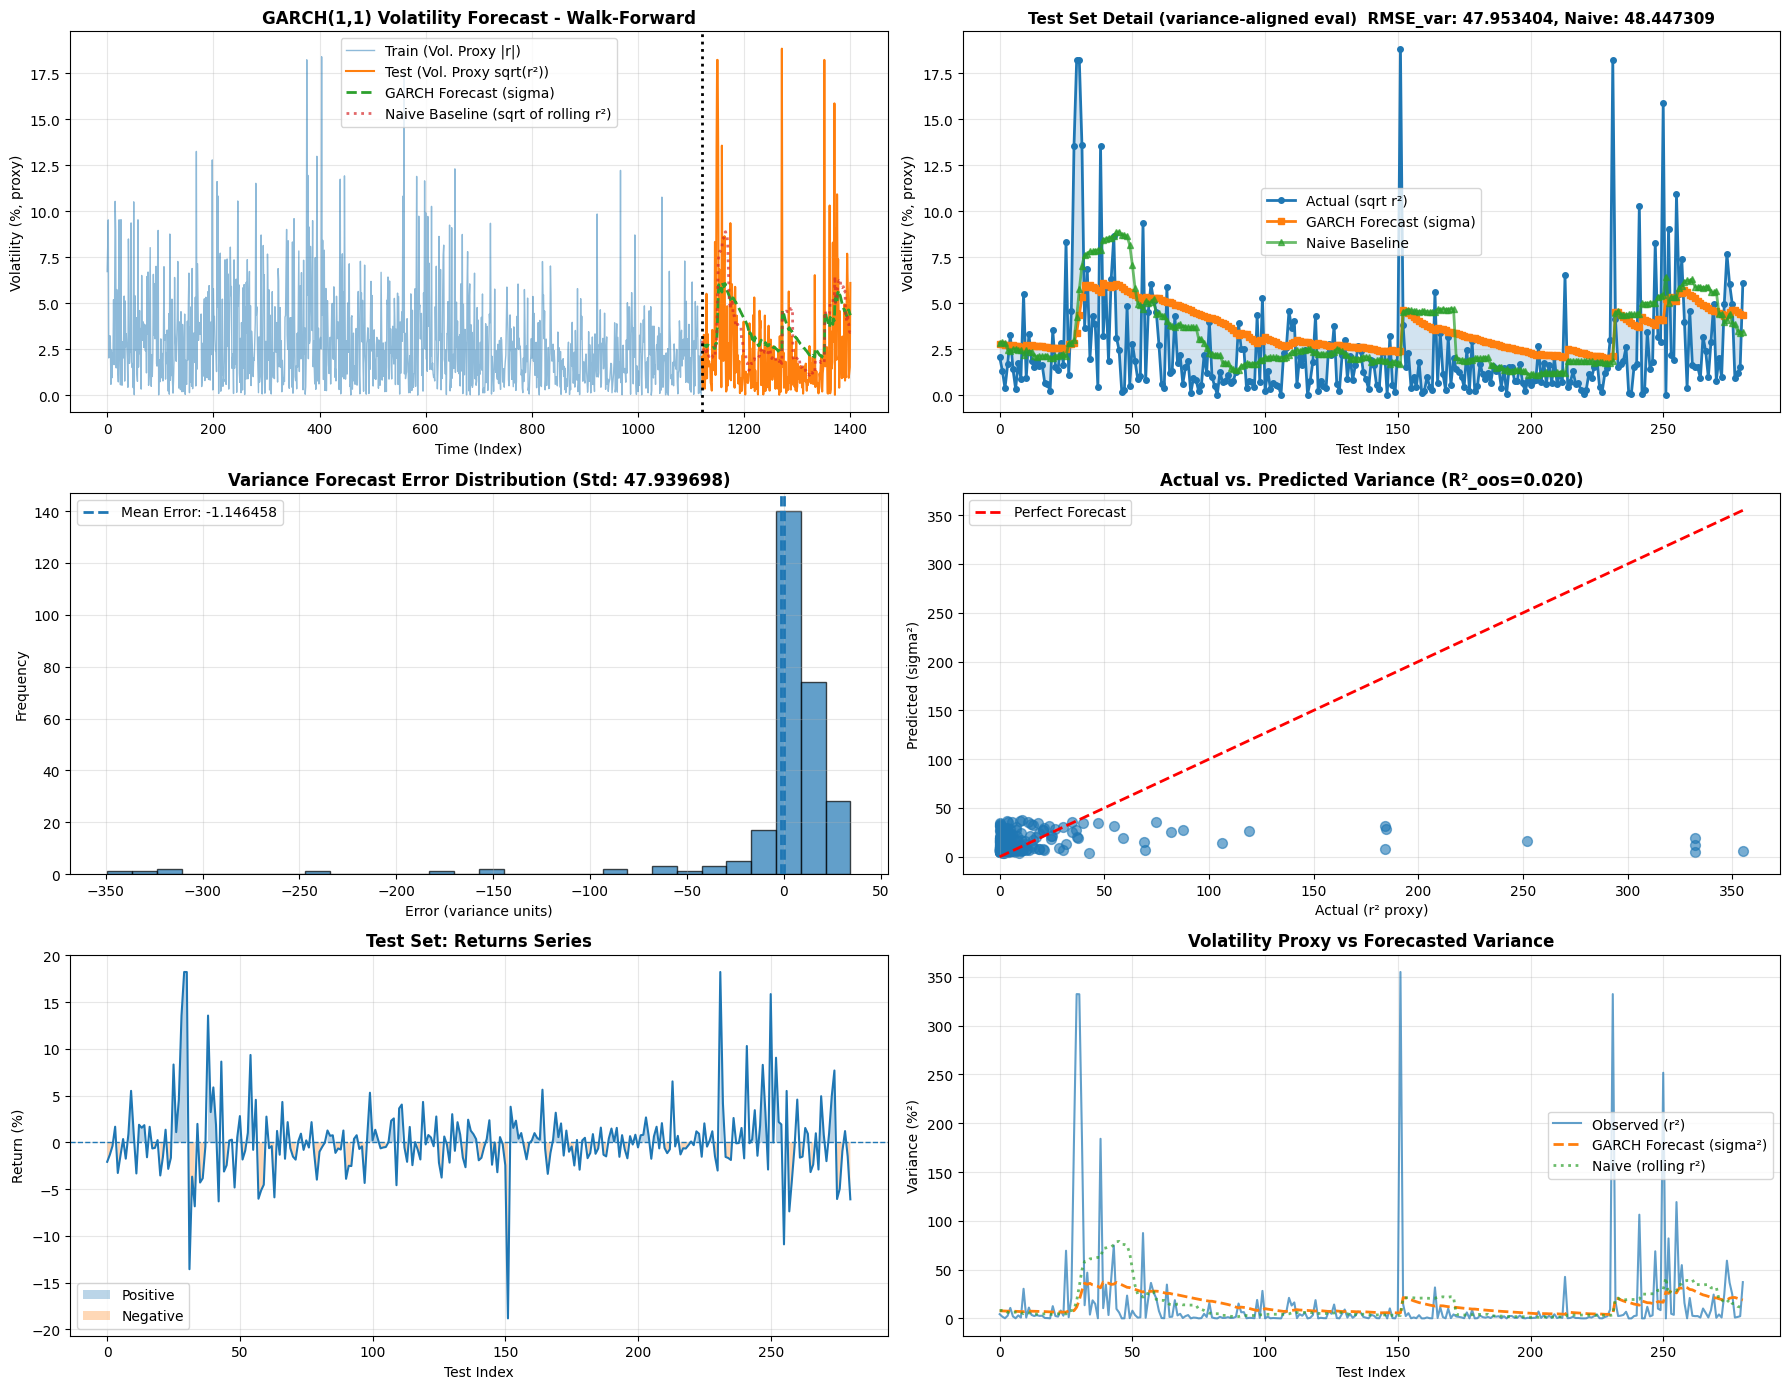


📋 SUMMARY REPORT - ETH 1D GARCH(1,1) - Skewed Student's t-Distribution

📁 DATA:
    • Total observations: 1401
    • Test period: 281 candles (~281 days)
    • Mean return: 0.0619%
    • Return std (unconditional): 3.8496%
    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)

🔧 MODEL:
    • GARCH(1,1) with Skewed Student's t-Distribution
    • Parameters (from final walk-forward model):
      - ω: 0.112772
      - α: 0.042986
      - β: 0.950294
    • Volatility persistence (α+β): 0.9933

    • Distribution Shape (Final Model):
      - ν: (Not found in final model)
      - λ: 0.106927 (Skewness Parameter)
      - ω: 0.112772
      - α: 0.042986
      - β: 0.950294
    • Volatility persistence (α+β): 0.9933
    • Validation: Walk-Forward (expanding window; no data leakage)
    • Baseline: Rolling mean of r² (variance proxy)

📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):
    GARCH Model:
    • RMSE (var): 47.953404
    • MAE  (var): 19.0684

In [ ]:
# MODEL: GARCH(1,1)
# DISTRIBUTION: Skewed Student's t-Distribution (dist='skewt')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ETH 1D GARCH ANALYSIS - WALK-FORWARD VALIDATION")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA AND CALCULATE RETURNS
# ============================================================================
print("\n[1/7] Loading data and calculating returns...")

raw = np.load("stocks_500.npy", allow_pickle=True).item()
data = {}

for key, df in raw.items():
    stock = key.replace('.csv', '')
    data[stock] = df

frames = []

for stock, df in data.items():
    # 把 index（日期）变成一列
    df = df.reset_index().rename(columns={'index': 'timestamp'})
    # 将日期转换为 datetime，与 sample 完全一致
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    # 加入股票列
    df['stock'] = stock
    df = df.sort_values('timestamp').reset_index(drop=True)
    # Calculate log returns (in %)
    df['returns'] = np.log(df['close'] / df['close'].shift(1)) * 100
    df = df.dropna(subset=['returns'])  # Drop the first row (NaN)
    df['realized_var'] = df['returns'] ** 2

    frames.append(df)




df=frames[6] #选择想处理的股票

print(f"✓ Total observations: {len(df)}")
print(f"✓ Date range: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
print(f"✓ Price range: ${df['close'].min():.2f} → ${df['close'].max():.2f}")

# Return statistics
print(f"\n📊 Return Statistics:")
print(f"    Mean: {df['returns'].mean():.4f}%")
print(f"    Std Dev: {df['returns'].std():.4f}%")
print(f"    Min: {df['returns'].min():.4f}%")
print(f"    Max: {df['returns'].max():.4f}%")
print(f"    Skewness: {df['returns'].skew():.4f}")
print(f"    Kurtosis: {df['returns'].kurtosis():.4f}")

# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (80%-20%)
# ============================================================================
print("\n[2/7] Splitting data (80% train - 20% test)...")

returns_series = df['returns']
rv_series = df['realized_var']   #平方项
train_size = int(len(returns_series) * 0.8)

train_returns = returns_series.iloc[:train_size]
test_returns = returns_series.iloc[train_size:]

train_rv = rv_series.iloc[:train_size]  #平方项
test_rv  = rv_series.iloc[train_size:] 

# Rolling window size (used for naive baseline)
vol_window = 20  

print(f"✓ Training set: {train_size} observations")
print(f"✓ Test set: {len(test_returns)} observations")
print(f"✓ Test period: {df['timestamp'].iloc[train_size]} → {df['timestamp'].iloc[-1]}")

# ============================================================================
# STEP 3: TRAIN BASELINE GARCH(1,1) MODEL (with Skewed t-Dist)
# ============================================================================
print("\n[3/7] Training baseline GARCH(1,1) model (with Skewed t-Dist)...")

# Train the initial model using 'dist=skewt'
baseline_model = arch_model(train_returns, vol='GARCH', p=1, q=1,
                            dist='skewt', 
                            rescale=False)
baseline_fitted = baseline_model.fit(disp='off')

print(f"\n📊 GARCH(1,1) - Skewed t-Distribution (Baseline Model):")
print(f"    ω (omega): {baseline_fitted.params['omega']:.6f}")
print(f"    α (alpha): {baseline_fitted.params['alpha[1]']:.6f}")
print(f"    β (beta):  {baseline_fitted.params['beta[1]']:.6f}")

# Check for and print shape parameters ('nu' and 'lambda')
params = baseline_fitted.params
print(f"\n    📊 Distribution Shape Parameters:")
if 'nu' in params.index:
    nu = params['nu']
    print(f"    ν (nu): {nu:.6f}  [Degrees of Freedom for t-Dist]")
    # Interpretation for nu (tail fatness)
    if nu < 5:
        print(f"    → Very fat tails (ν={nu:.2f}). Extreme events are frequent.")
    elif nu < 10:
        print(f"    → Fat tails (ν={nu:.2f}). More extreme events than normal.")
    else:
        print(f"    → Moderately fat tails (ν={nu:.2f}).")
else:
    print(f"    ⚠️ 'nu' parameter not found.")

if 'lambda' in params.index:
    lam = params['lambda']
    print(f"    λ (lambda): {lam:.6f}  [Skewness Parameter]")
    # Interpretation for lambda (skewness)
    if lam < -0.1:
        print(f"    → Negatively skewed (λ={lam:.2f}). Large negative returns are more likely.")
    elif lam > 0.1:
        print(f"    → Positively skewed (λ={lam:.2f}). Large positive returns are more likely.")
    else:
        print(f"    → Approximately symmetric (λ={lam:.2f}).")
else:
    print(f"    ⚠️ 'lambda' parameter not found.")


if params['alpha[1]'] + params['beta[1]'] < 1.0:
    print("\n    ✅ Model is stationary (α + β < 1)")
else:
    print("\n    ⚠️ Model is not stationary (α + β ≥ 1)")


# ============================================================================
# STEP 4: WALK-FORWARD VALIDATION
# ============================================================================
print("\n[4/7] Starting walk-forward validation...")
print("      (GARCH model will be refit at each step)")

# Store predictions
predictions_var = []
actual_var = []
naive_var = []
final_fitted_model = None

# For each test point
for i in range(len(test_returns)):
    # Current training data (train + test up to this point)
    if i > 0:
        history = np.concatenate([train_returns, test_returns[:i]])
        rv_history = np.concatenate([train_rv, actual_var[:i]])
    else:
        history = train_returns
        rv_history = train_rv
    
    try:
        # Train GARCH(1,1) model with skewed t-distribution
        model = arch_model(history, vol='GARCH', p=1, q=1,
                           dist='skewt', 
                           rescale=False)
        fitted = model.fit(disp='off')
        final_fitted_model = fitted 
        
        # 1-step ahead volatility forecast
        forecast = fitted.forecast(horizon=1, reindex=False)
        predicted_variance = float(forecast.variance.values[-1, 0])
        predictions_var.append(predicted_variance)

        
        # ACTUAL VOLATILITY: Simple proxy (absolute return)
        actual_var.append(float(test_rv.iloc[i]))

        
        # NAIVE FORECAST: Mean of all actual volatility seen so far
        window = rv_history[-vol_window:]# 过去 vol_window 个 realized_var 的均值
        naive_pred = float(np.mean(window))
        naive_var.append(naive_pred)

        
    except Exception as e:
        print(f"    ⚠️ Error at step {i+1}: {str(e)[:50]}")
        # In case of error, use the last known volatility
        if len(predictions_var) > 0:
            predictions_var.append(predictions_var[-1])
        else:
            # For the very first prediction, use train volatility
            predictions_var.append(np.mean(np.abs(train_returns[-vol_window:])))
        
        actual_var.append(abs(test_returns[i])**2)
        
        if i > 0:
            naive_var.append(np.mean(actual_var[:i]))
        else:
            naive_var.append(np.mean(np.abs(train_returns[-vol_window:])))
    
    # Show progress
    if (i + 1) % 10 == 0 or i == len(test_returns) - 1:
        print(f"    Progress: {i+1}/{len(test_returns)} completed")

predictions_var = np.array(predictions_var)
actual_var = np.array(actual_var)
naive_var = np.array(naive_var)

# ============================================================================
# STEP 5: PERFORMANCE METRICS  (Variance-level, aligned with GARCH)
# ============================================================================
print("\n[5/7] Calculating performance metrics...")

# Ensure numpy arrays
actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Safety: avoid zeros in denominators / logs
eps = 1e-12
pred_var_safe = np.maximum(predictions_var, eps)
naive_var_safe = np.maximum(naive_var, eps)

# --------------------
# Metrics on variance
# --------------------
rmse_var = np.sqrt(mean_squared_error(actual_var, predictions_var))
mae_var = mean_absolute_error(actual_var, predictions_var)
mape_var = np.mean(np.abs((actual_var - predictions_var) / (actual_var + eps))) * 100

# QLIKE (standard for variance forecasting)
qlike_garch = np.mean(actual_var / pred_var_safe + np.log(pred_var_safe))
qlike_naive = np.mean(actual_var / naive_var_safe + np.log(naive_var_safe))

# Out-of-sample R² relative to naive baseline (Campbell-Thompson style)
ss_res = np.sum((actual_var - predictions_var) ** 2)
ss_tot = np.sum((actual_var - naive_var) ** 2)
r2_oos = 1 - (ss_res / ss_tot)

# Naive model performance (variance)
naive_rmse_var = np.sqrt(mean_squared_error(actual_var, naive_var))
naive_mae_var = mean_absolute_error(actual_var, naive_var)

print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target: r^2 proxy):")
print(f"    GARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline (Rolling Mean of r^2):")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):.2f}%")

# --------------------
# Descriptive stats
# --------------------
print(f"\n📊 Variance Statistics (Test Set):")
print(f"    Actual variance proxy (r^2):")
print(f"    • Mean: {np.mean(actual_var):.6f}")
print(f"    • Std:  {np.std(actual_var):.6f}")
print(f"    • Min:  {np.min(actual_var):.6f}")
print(f"    • Max:  {np.max(actual_var):.6f}")

print(f"\n    GARCH predicted variance (sigma^2):")
print(f"    • Mean: {np.mean(predictions_var):.6f}")
print(f"    • Std:  {np.std(predictions_var):.6f}")

print(f"\n    Naive predicted variance:")
print(f"    • Mean: {np.mean(naive_var):.6f}")
print(f"    • Std:  {np.std(naive_var):.6f}")

# Optional: also report volatility-level (std) for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol = np.sqrt(np.maximum(predictions_var, 0))
naive_vol = np.sqrt(np.maximum(naive_var, 0))

print(f"\n📌 (Optional) Volatility-level summary (sqrt of variance):")
print(f"    Actual vol proxy:")
print(f"    • Mean: {np.mean(actual_vol):.6f}")
print(f"    • Std:  {np.std(actual_vol):.6f}")
print(f"    GARCH predicted vol:")
print(f"    • Mean: {np.mean(pred_vol):.6f}")
print(f"    • Std:  {np.std(pred_vol):.6f}")
print(f"    Naive predicted vol:")
print(f"    • Mean: {np.mean(naive_vol):.6f}")
print(f"    • Std:  {np.std(naive_vol):.6f}")

# ============================================================================
# STEP 6: VISUALIZATION (aligned)
# ============================================================================
print("\n[6/7] Generating plots...")

# Ensure numpy
train_returns_np = np.asarray(train_returns, dtype=float)  # Series/ndarray都可
test_returns_np  = np.asarray(test_returns, dtype=float)

actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Convert variance -> volatility for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol   = np.sqrt(np.maximum(predictions_var, 0))
naive_vol  = np.sqrt(np.maximum(naive_var, 0))

# A consistent "train volatility proxy" for the full-series plot
train_vol_proxy = np.sqrt(np.maximum((train_returns_np**2), 0))  # = abs(train_returns)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# 1. Full series: volatility proxy + forecasts on test
train_x = np.arange(len(train_vol_proxy))
test_x = np.arange(len(train_vol_proxy), len(train_vol_proxy) + len(actual_vol))

axes[0, 0].plot(train_x, train_vol_proxy, label='Train (Vol. Proxy |r|)',
                alpha=0.5, linewidth=1)
axes[0, 0].plot(test_x, actual_vol, label='Test (Vol. Proxy sqrt(r²))',
                linewidth=1.5)
axes[0, 0].plot(test_x, pred_vol, label='GARCH Forecast (sigma)',
                linestyle='--', linewidth=2)
axes[0, 0].plot(test_x, naive_vol, label='Naive Baseline (sqrt of rolling r²)',
                linestyle=':', linewidth=2, alpha=0.7)
axes[0, 0].axvline(x=len(train_vol_proxy), color='black', linestyle=':', linewidth=2)
axes[0, 0].set_title('GARCH(1,1) Volatility Forecast - Walk-Forward', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Time (Index)')
axes[0, 0].set_ylabel('Volatility (%, proxy)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Test detail (volatility scale)
axes[0, 1].plot(actual_vol, label='Actual (sqrt r²)',
                linewidth=2, marker='o', markersize=4)
axes[0, 1].plot(pred_vol, label='GARCH Forecast (sigma)',
                linewidth=2, marker='s', markersize=4)
axes[0, 1].plot(naive_vol, label='Naive Baseline',
                linewidth=2, marker='^', markersize=4, alpha=0.7)
axes[0, 1].fill_between(range(len(actual_vol)), actual_vol, pred_vol, alpha=0.2)
axes[0, 1].set_title(
    f'Test Set Detail (variance-aligned eval)  RMSE_var: {rmse_var:.6f}, Naive: {naive_rmse_var:.6f}',
    fontweight='bold', fontsize=11
)
axes[0, 1].set_xlabel('Test Index')
axes[0, 1].set_ylabel('Volatility (%, proxy)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Error distribution (variance level is more principled)
errors_var = predictions_var - actual_var 
axes[1, 0].hist(errors_var, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, linestyle='--', linewidth=2)
axes[1, 0].axvline(x=np.mean(errors_var), linestyle='--', linewidth=2,
                   label=f'Mean Error: {np.mean(errors_var):.6f}')
axes[1, 0].set_title(f'Variance Forecast Error Distribution (Std: {np.std(errors_var):.6f})',
                     fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Error (variance units)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter plot (variance)
axes[1, 1].scatter(actual_var, predictions_var, alpha=0.6, s=50)
minv = min(actual_var.min(), predictions_var.min())
maxv = max(actual_var.max(), predictions_var.max())
axes[1, 1].plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Perfect Forecast')
axes[1, 1].set_title(f'Actual vs. Predicted Variance (R²_oos={r2_oos:.3f})',
                     fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Actual (r² proxy)')
axes[1, 1].set_ylabel('Predicted (sigma²)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Returns time series
test_x_returns = np.arange(len(test_returns_np))
axes[2, 0].plot(test_x_returns, test_returns_np, linewidth=1.5)
axes[2, 0].axhline(y=0, linestyle='--', linewidth=1)
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np > 0), alpha=0.3, label='Positive')
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np <= 0), alpha=0.3, label='Negative')
axes[2, 0].set_title('Test Set: Returns Series', fontweight='bold', fontsize=12)
axes[2, 0].set_xlabel('Test Index')
axes[2, 0].set_ylabel('Return (%)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Volatility clustering (variance view)
squared_returns = test_returns_np ** 2
axes[2, 1].plot(squared_returns, linewidth=1.5, alpha=0.7, label='Observed (r²)')
axes[2, 1].plot(predictions_var, linewidth=2, linestyle='--', label='GARCH Forecast (sigma²)')
axes[2, 1].plot(naive_var, linewidth=2, linestyle=':', alpha=0.7, label='Naive (rolling r²)')
axes[2, 1].set_title('Volatility Proxy vs Forecasted Variance', fontweight='bold', fontsize=12)
axes[2, 1].set_xlabel('Test Index')
axes[2, 1].set_ylabel('Variance (%²)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('garch_1d_walkforward_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved: garch_1d_walkforward_analysis.png")
plt.show()

# ============================================================================
# STEP 7: SUMMARY REPORT (Variance-aligned)
# ============================================================================
print("\n" + "="*80)
print("📋 SUMMARY REPORT - ETH 1D GARCH(1,1) - Skewed Student's t-Distribution")
print("="*80)

print(f"\n📁 DATA:")
print(f"    • Total observations: {len(df)}")
print(f"    • Test period: {len(test_returns)} candles (~{len(test_returns)} days)")
print(f"    • Mean return: {df['returns'].mean():.4f}%")
print(f"    • Return std (unconditional): {df['returns'].std():.4f}%")
print(f"    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)")

print(f"\n🔧 MODEL:")
print(f"    • GARCH(1,1) with Skewed Student's t-Distribution")

# Parameters
if final_fitted_model:
    params = final_fitted_model.params
    print(f"    • Parameters (from final walk-forward model):")
    print(f"      - ω: {params['omega']:.6f}")
    print(f"      - α: {params['alpha[1]']:.6f}")
    print(f"      - β: {params['beta[1]']:.6f}")
    
    persistence = params['alpha[1]'] + params['beta[1]']
    print(f"    • Volatility persistence (α+β): {persistence:.4f}")
    
    print(f"\n    • Distribution Shape (Final Model):")
    if 'nu' in params.index:
        print(f"      - ν: {params['nu']:.6f} (Degrees of Freedom / Tail Fatness)")
    else:
        print("      - ν: (Not found in final model)")
        
    if 'lambda' in params.index:
        print(f"      - λ: {params['lambda']:.6f} (Skewness Parameter)")
    else:
        print("      - λ: (Not found in final model)")
        
else:
    # Fallback to baseline if loop failed
    params = baseline_fitted.params
    persistence = params['alpha[1]'] + params['beta[1]']
    print(f"    • Parameters (from baseline model - WARNING: loop might have failed):")
    
omega = float(params.get('omega', np.nan))
alpha = float(params.get('alpha[1]', np.nan))
beta  = float(params.get('beta[1]', np.nan))

print(f"      - ω: {omega:.6f}")
print(f"      - α: {alpha:.6f}")
print(f"      - β: {beta:.6f}")

persistence = alpha + beta
print(f"    • Volatility persistence (α+β): {persistence:.4f}")
print(f"    • Validation: Walk-Forward (expanding window; no data leakage)")
print(f"    • Baseline: Rolling mean of r² (variance proxy)")

# Metrics (variance-level)
print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):")
print(f"    GARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline:")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):+.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):+.2f}%")

print(f"\n💡 EVALUATION:")

# RMSE evaluation (variance-level)
rmse_improvement = ((naive_rmse_var - rmse_var) / naive_rmse_var * 100)
if rmse_improvement > 10:
    print(f"    ✅ GARCH (Skew-t) improves RMSE by {rmse_improvement:.1f}% vs naive (substantial)")
elif rmse_improvement > 5:
    print(f"    ✓ GARCH (Skew-t) improves RMSE by {rmse_improvement:.1f}% vs naive (moderate)")
elif rmse_improvement > 0:
    print(f"    ⚠️ GARCH (Skew-t) improves RMSE by {rmse_improvement:.1f}% vs naive (slight)")
else:
    print(f"    ❌ GARCH (Skew-t) worsens RMSE by {abs(rmse_improvement):.1f}% vs naive")

# R²_oos evaluation (variance-level)
if r2_oos > 0.3:
    print(f"    ✅ R²_oos={r2_oos:.3f} - substantially better than naive")
elif r2_oos > 0.1:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - moderately better than naive")
elif r2_oos > 0:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - only slightly better than naive")
else:
    print(f"    ❌ R²_oos={r2_oos:.3f} - worse than naive")

# Parameter interpretation
if persistence > 0.95:
    print("    ⚠️ High persistence: volatility shocks decay very slowly")
elif persistence > 0.85:
    print("    ✓ Moderate persistence: shocks decay gradually")
else:
    print("    ✅ Low persistence: shocks decay relatively quickly")

if alpha > beta:
    print("    • ARCH effect dominant: higher sensitivity to recent shocks")
else:
    print("    • GARCH effect dominant: volatility persistence matters more")

# MAPE caveat (variance)
print("    • Note: MAPE on variance proxies can be unstable when actual_var is near zero; prefer QLIKE for variance forecasts.")

print(f"\n📈 VOLATILITY CLUSTERING:")
acorr_sq_returns = np.corrcoef(squared_returns[:-1], squared_returns[1:])[0, 1]
print(f"    • Squared returns autocorrelation: {acorr_sq_returns:.4f}")
if acorr_sq_returns > 0.1:
    print("    ✅ Volatility clustering is present (GARCH is appropriate)")
else:
    print("    ⚠️ Weak volatility clustering")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

print("\n💡 NEXT STEPS:")
print("    • Try EGARCH or TGARCH models (for leverage effects)")
print("    • Calculate Value at Risk (VaR) using the skewed t-distribution parameters")
print("    • Compare performance metrics (RMSE, R²) against the Normal and regular t-dist models")

ETH 1D GARCH ANALYSIS - WALK-FORWARD VALIDATION

[1/7] Loading data and calculating returns...
✓ Total observations: 1401
✓ Date range: 2020-01-03 00:00:00 → 2025-10-17 00:00:00
✓ Price range: $40.64 → $197.02

📊 Return Statistics:
    Mean: 0.0619%
    Std Dev: 3.8496%
    Min: -18.8403%
    Max: 18.2346%
    Skewness: 0.4159
    Kurtosis: 3.0958

[2/7] Splitting data (80% train - 20% test)...
✓ Training set: 1120 observations
✓ Test set: 281 observations
✓ Test period: 2024-08-16 00:00:00 → 2025-10-17 00:00:00

[3/7] Training baseline EGARCH(1,1,1) - Normal distribution model...

📊 EGARCH(1,1,1) - Normal Distribution (Baseline Model):
    ω (omega): 0.016670
    α (alpha): 0.056462
    γ (gamma): 0.002924  [Asymmetry parameter]
    β (beta):  0.994124
    ✓ No 'nu' parameter found (Correct for Normal dist).

    Volatility Persistence (β): 0.994124
    ✅ EGARCH model is stationary by design (log-linear)

    📊 Asymmetry Analysis (Leverage Effect):
    ⚖️ Weak or no asymmetry (γ=0.002

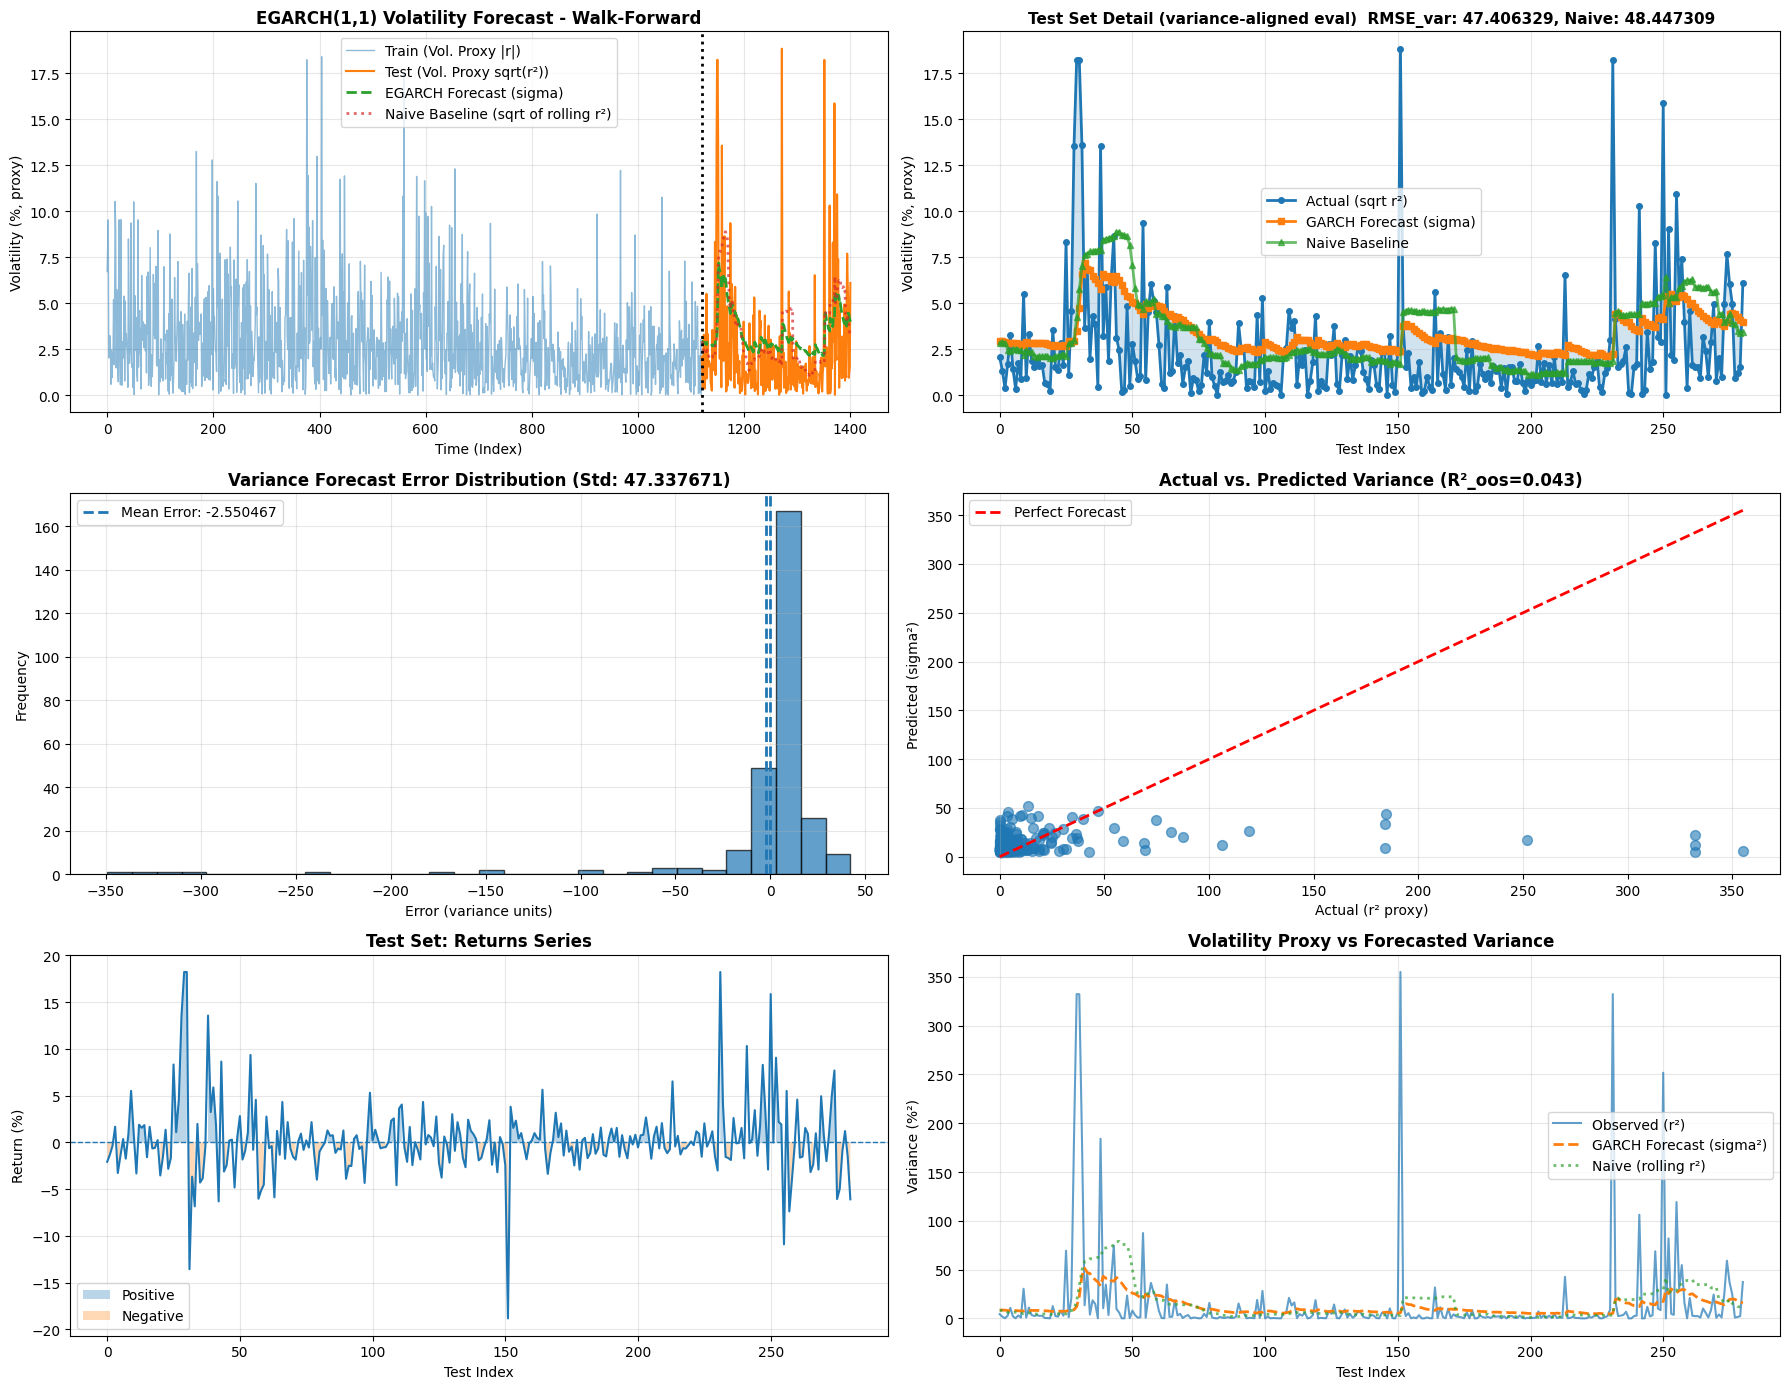


📋 SUMMARY REPORT - ETH 1D EGARCH(1,1,1) - Normal Distribution

📁 DATA:
    • Total observations: 1401
    • Test period: 281 candles (~281 days)
    • Mean return: 0.0619%
    • Return std (unconditional): 3.8496%
    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)

🔧 MODEL:
    • EGARCH(1,1,1) - Normal Distribution
    • Parameters (from final walk-forward model):
      - ω: 0.135012
      - α: 0.121185
      - γ: 0.035284  [Asymmetry parameter]
      - β: 0.951376
    ✓ No 'nu' parameter (Correct for Normal dist).
      - ω: 0.135012
      - α: 0.121185
      - β: 0.951376
    • Volatility persistence (α+β): 1.0726
    • Validation: Walk-Forward (expanding window; no data leakage)
    • Baseline: Rolling mean of r² (variance proxy)

📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):
    EGARCH Model:
    • RMSE (var): 47.406329
    • MAE  (var): 17.849521
    • MAPE (var): 122898.78%
    • QLIKE:      3.722610

    Naive Baseline:
    • RMS

In [ ]:
# MODEL: EGARCH(1,1,1)
# DISTRIBUTION: Normal (Gaussian) Distribution

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ETH 1D GARCH ANALYSIS - WALK-FORWARD VALIDATION")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA AND CALCULATE RETURNS
# ============================================================================
print("\n[1/7] Loading data and calculating returns...")

raw = np.load("stocks_500.npy", allow_pickle=True).item()
data = {}

for key, df in raw.items():
    stock = key.replace('.csv', '')
    data[stock] = df

frames = []

for stock, df in data.items():
    # 把 index（日期）变成一列
    df = df.reset_index().rename(columns={'index': 'timestamp'})
    # 将日期转换为 datetime，与 sample 完全一致
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    # 加入股票列
    df['stock'] = stock
    df = df.sort_values('timestamp').reset_index(drop=True)
    # Calculate log returns (in %)
    df['returns'] = np.log(df['close'] / df['close'].shift(1)) * 100
    df = df.dropna(subset=['returns'])  # Drop the first row (NaN)
    df['realized_var'] = df['returns'] ** 2

    frames.append(df)




df=frames[6] #选择想处理的股票

print(f"✓ Total observations: {len(df)}")
print(f"✓ Date range: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
print(f"✓ Price range: ${df['close'].min():.2f} → ${df['close'].max():.2f}")

# Return statistics
print(f"\n📊 Return Statistics:")
print(f"    Mean: {df['returns'].mean():.4f}%")
print(f"    Std Dev: {df['returns'].std():.4f}%")
print(f"    Min: {df['returns'].min():.4f}%")
print(f"    Max: {df['returns'].max():.4f}%")
print(f"    Skewness: {df['returns'].skew():.4f}")
print(f"    Kurtosis: {df['returns'].kurtosis():.4f}")

# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (80%-20%)
# ============================================================================
print("\n[2/7] Splitting data (80% train - 20% test)...")

returns_series = df['returns']
rv_series = df['realized_var']   #平方项
train_size = int(len(returns_series) * 0.8)

train_returns = returns_series.iloc[:train_size]
test_returns = returns_series.iloc[train_size:]

train_rv = rv_series.iloc[:train_size]  #平方项
test_rv  = rv_series.iloc[train_size:] 

# Rolling window size (used for naive baseline)
vol_window = 20  

print(f"✓ Training set: {train_size} observations")
print(f"✓ Test set: {len(test_returns)} observations")
print(f"✓ Test period: {df['timestamp'].iloc[train_size]} → {df['timestamp'].iloc[-1]}")

# ============================================================================
# STEP 3: TRAIN BASELINE EGARCH(1,1,1) - NORMAL DISTRIBUTION MODEL
# ============================================================================
print("\n[3/7] Training baseline EGARCH(1,1,1) - Normal distribution model...")

# Train the initial model
baseline_model = arch_model(train_returns,
                            mean='Zero',     # Assume zero mean for returns
                            vol='EGARCH',
                            p=1,             # ARCH term
                            o=1,             # Asymmetry term (gamma)
                            q=1,             # GARCH term
                            dist='normal',   # Use Normal distribution
                            rescale=False)

baseline_fitted = baseline_model.fit(disp='off')
params = baseline_fitted.params

print(f"\n📊 EGARCH(1,1,1) - Normal Distribution (Baseline Model):")
print(f"    ω (omega): {params.get('omega', 'N/A'):.6f}")
print(f"    α (alpha): {params.get('alpha[1]', 'N/A'):.6f}")
print(f"    γ (gamma): {params.get('gamma[1]', 'N/A'):.6f}  [Asymmetry parameter]")
print(f"    β (beta):  {params.get('beta[1]', 'N/A'):.6f}")

# Check for 'nu' - IT SHOULD NOT BE HERE
if 'nu' in params.index:
    print(f"    ⚠️ WARNING: 'nu' parameter found, but 'dist=normal' was specified.")
else:
    print(f"    ✓ No 'nu' parameter found (Correct for Normal dist).")


print(f"\n    Volatility Persistence (β): {params.get('beta[1]', 0):.6f}")
print("    ✅ EGARCH model is stationary by design (log-linear)")

# Asymmetry analysis
gamma = params.get('gamma[1]', 0)
print(f"\n    📊 Asymmetry Analysis (Leverage Effect):")
if gamma < -0.1:
    print(f"    📉 Strong leverage effect (γ={gamma:.4f})")
    print(f"    → Negative shocks (bad news) increase volatility significantly more than positive shocks.")
elif gamma < 0:
    print(f"    ✓ Leverage effect present (γ={gamma:.4f})")
    print(f"    → Negative shocks are more impactful.")
elif gamma > 0.1:
    print(f"    📈 Inverse leverage effect (γ={gamma:.4f})")
    print(f"    → Positive shocks (good news) increase volatility more (rare in finance).")
else:
    print(f"    ⚖️ Weak or no asymmetry (γ={gamma:.4f}).")

# ============================================================================
# STEP 4: WALK-FORWARD VALIDATION
# ============================================================================
print("\n[4/7] Starting walk-forward validation...")
print("      (GARCH model will be refit at each step)")

# Store predictions
predictions_var = []
actual_var = []
naive_var = []
final_fitted_model = None

# For each test point
for i in range(len(test_returns)):
    # Current training data (train + test up to this point)
    if i > 0:
        history = np.concatenate([train_returns, test_returns[:i]])
        rv_history = np.concatenate([train_rv, actual_var[:i]])
    else:
        history = train_returns
        rv_history = train_rv
    
    try:
        # Train EGARCH(1,1,1) - Normal distribution
        model = arch_model(history,
                           mean='Zero',
                           vol='EGARCH',
                           p=1,
                           o=1,
                           q=1,
                           dist='normal',
                           rescale=False)
        fitted = model.fit(disp='off')
        final_fitted_model = fitted 
        
        # 1-step ahead volatility forecast
        forecast = fitted.forecast(horizon=1, reindex=False)
        predicted_variance = float(forecast.variance.values[-1, 0])
        predictions_var.append(predicted_variance)

        
        # ACTUAL VOLATILITY: Simple proxy (absolute return)
        actual_var.append(float(test_rv.iloc[i]))

        
        # NAIVE FORECAST: Mean of all actual volatility seen so far
        window = rv_history[-vol_window:]# 过去 vol_window 个 realized_var 的均值
        naive_pred = float(np.mean(window))
        naive_var.append(naive_pred)

        
    except Exception as e:
        print(f"    ⚠️ Error at step {i+1}: {str(e)[:50]}")
        # In case of error, use the last known volatility
        if len(predictions_var) > 0:
            predictions_var.append(predictions_var[-1])
        else:
            # For the very first prediction, use train volatility
            predictions_var.append(np.mean(np.abs(train_returns[-vol_window:])))
        
        actual_var.append(abs(test_returns[i])**2)
        
        if i > 0:
            naive_var.append(np.mean(actual_var[:i]))
        else:
            naive_var.append(np.mean(np.abs(train_returns[-vol_window:])))
    
    # Show progress
    if (i + 1) % 10 == 0 or i == len(test_returns) - 1:
        print(f"    Progress: {i+1}/{len(test_returns)} completed")

predictions_var = np.array(predictions_var)
actual_var = np.array(actual_var)
naive_var = np.array(naive_var)

# ============================================================================
# STEP 5: PERFORMANCE METRICS  (Variance-level, aligned with GARCH)
# ============================================================================
print("\n[5/7] Calculating performance metrics...")

# Ensure numpy arrays
actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Safety: avoid zeros in denominators / logs
eps = 1e-12
pred_var_safe = np.maximum(predictions_var, eps)
naive_var_safe = np.maximum(naive_var, eps)

# --------------------
# Metrics on variance
# --------------------
rmse_var = np.sqrt(mean_squared_error(actual_var, predictions_var))
mae_var = mean_absolute_error(actual_var, predictions_var)
mape_var = np.mean(np.abs((actual_var - predictions_var) / (actual_var + eps))) * 100

# QLIKE (standard for variance forecasting)
qlike_garch = np.mean(actual_var / pred_var_safe + np.log(pred_var_safe))
qlike_naive = np.mean(actual_var / naive_var_safe + np.log(naive_var_safe))

# Out-of-sample R² relative to naive baseline (Campbell-Thompson style)
ss_res = np.sum((actual_var - predictions_var) ** 2)
ss_tot = np.sum((actual_var - naive_var) ** 2)
r2_oos = 1 - (ss_res / ss_tot)

# Naive model performance (variance)
naive_rmse_var = np.sqrt(mean_squared_error(actual_var, naive_var))
naive_mae_var = mean_absolute_error(actual_var, naive_var)

print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target: r^2 proxy):")
print(f"    GARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline (Rolling Mean of r^2):")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):.2f}%")

# --------------------
# Descriptive stats
# --------------------
print(f"\n📊 Variance Statistics (Test Set):")
print(f"    Actual variance proxy (r^2):")
print(f"    • Mean: {np.mean(actual_var):.6f}")
print(f"    • Std:  {np.std(actual_var):.6f}")
print(f"    • Min:  {np.min(actual_var):.6f}")
print(f"    • Max:  {np.max(actual_var):.6f}")

print(f"\n    EGARCH predicted variance (sigma^2):")
print(f"    • Mean: {np.mean(predictions_var):.6f}")
print(f"    • Std:  {np.std(predictions_var):.6f}")

print(f"\n    Naive predicted variance:")
print(f"    • Mean: {np.mean(naive_var):.6f}")
print(f"    • Std:  {np.std(naive_var):.6f}")

# Optional: also report volatility-level (std) for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol = np.sqrt(np.maximum(predictions_var, 0))
naive_vol = np.sqrt(np.maximum(naive_var, 0))

print(f"\n📌 (Optional) Volatility-level summary (sqrt of variance):")
print(f"    Actual vol proxy:")
print(f"    • Mean: {np.mean(actual_vol):.6f}")
print(f"    • Std:  {np.std(actual_vol):.6f}")
print(f"    EGARCH predicted vol:")
print(f"    • Mean: {np.mean(pred_vol):.6f}")
print(f"    • Std:  {np.std(pred_vol):.6f}")
print(f"    Naive predicted vol:")
print(f"    • Mean: {np.mean(naive_vol):.6f}")
print(f"    • Std:  {np.std(naive_vol):.6f}")

# ============================================================================
# STEP 6: VISUALIZATION (aligned)
# ============================================================================
print("\n[6/7] Generating plots...")

# Ensure numpy
train_returns_np = np.asarray(train_returns, dtype=float)  # Series/ndarray都可
test_returns_np  = np.asarray(test_returns, dtype=float)

actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Convert variance -> volatility for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol   = np.sqrt(np.maximum(predictions_var, 0))
naive_vol  = np.sqrt(np.maximum(naive_var, 0))

# A consistent "train volatility proxy" for the full-series plot
train_vol_proxy = np.sqrt(np.maximum((train_returns_np**2), 0))  # = abs(train_returns)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# 1. Full series: volatility proxy + forecasts on test
train_x = np.arange(len(train_vol_proxy))
test_x = np.arange(len(train_vol_proxy), len(train_vol_proxy) + len(actual_vol))

axes[0, 0].plot(train_x, train_vol_proxy, label='Train (Vol. Proxy |r|)',
                alpha=0.5, linewidth=1)
axes[0, 0].plot(test_x, actual_vol, label='Test (Vol. Proxy sqrt(r²))',
                linewidth=1.5)
axes[0, 0].plot(test_x, pred_vol, label='EGARCH Forecast (sigma)',
                linestyle='--', linewidth=2)
axes[0, 0].plot(test_x, naive_vol, label='Naive Baseline (sqrt of rolling r²)',
                linestyle=':', linewidth=2, alpha=0.7)
axes[0, 0].axvline(x=len(train_vol_proxy), color='black', linestyle=':', linewidth=2)
axes[0, 0].set_title('EGARCH(1,1) Volatility Forecast - Walk-Forward', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Time (Index)')
axes[0, 0].set_ylabel('Volatility (%, proxy)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Test detail (volatility scale)
axes[0, 1].plot(actual_vol, label='Actual (sqrt r²)',
                linewidth=2, marker='o', markersize=4)
axes[0, 1].plot(pred_vol, label='GARCH Forecast (sigma)',
                linewidth=2, marker='s', markersize=4)
axes[0, 1].plot(naive_vol, label='Naive Baseline',
                linewidth=2, marker='^', markersize=4, alpha=0.7)
axes[0, 1].fill_between(range(len(actual_vol)), actual_vol, pred_vol, alpha=0.2)
axes[0, 1].set_title(
    f'Test Set Detail (variance-aligned eval)  RMSE_var: {rmse_var:.6f}, Naive: {naive_rmse_var:.6f}',
    fontweight='bold', fontsize=11
)
axes[0, 1].set_xlabel('Test Index')
axes[0, 1].set_ylabel('Volatility (%, proxy)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Error distribution (variance level is more principled)
errors_var = predictions_var - actual_var 
axes[1, 0].hist(errors_var, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, linestyle='--', linewidth=2)
axes[1, 0].axvline(x=np.mean(errors_var), linestyle='--', linewidth=2,
                   label=f'Mean Error: {np.mean(errors_var):.6f}')
axes[1, 0].set_title(f'Variance Forecast Error Distribution (Std: {np.std(errors_var):.6f})',
                     fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Error (variance units)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter plot (variance)
axes[1, 1].scatter(actual_var, predictions_var, alpha=0.6, s=50)
minv = min(actual_var.min(), predictions_var.min())
maxv = max(actual_var.max(), predictions_var.max())
axes[1, 1].plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Perfect Forecast')
axes[1, 1].set_title(f'Actual vs. Predicted Variance (R²_oos={r2_oos:.3f})',
                     fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Actual (r² proxy)')
axes[1, 1].set_ylabel('Predicted (sigma²)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Returns time series
test_x_returns = np.arange(len(test_returns_np))
axes[2, 0].plot(test_x_returns, test_returns_np, linewidth=1.5)
axes[2, 0].axhline(y=0, linestyle='--', linewidth=1)
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np > 0), alpha=0.3, label='Positive')
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np <= 0), alpha=0.3, label='Negative')
axes[2, 0].set_title('Test Set: Returns Series', fontweight='bold', fontsize=12)
axes[2, 0].set_xlabel('Test Index')
axes[2, 0].set_ylabel('Return (%)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Volatility clustering (variance view)
squared_returns = test_returns_np ** 2
axes[2, 1].plot(squared_returns, linewidth=1.5, alpha=0.7, label='Observed (r²)')
axes[2, 1].plot(predictions_var, linewidth=2, linestyle='--', label='GARCH Forecast (sigma²)')
axes[2, 1].plot(naive_var, linewidth=2, linestyle=':', alpha=0.7, label='Naive (rolling r²)')
axes[2, 1].set_title('Volatility Proxy vs Forecasted Variance', fontweight='bold', fontsize=12)
axes[2, 1].set_xlabel('Test Index')
axes[2, 1].set_ylabel('Variance (%²)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('garch_1d_walkforward_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved: garch_1d_walkforward_analysis.png")
plt.show()

# ============================================================================
# STEP 7: SUMMARY REPORT (Variance-aligned)
# ============================================================================
print("\n" + "="*80)
print("📋 SUMMARY REPORT - ETH 1D EGARCH(1,1,1) - Normal Distribution") 
print("="*80)

print(f"\n📁 DATA:")
print(f"    • Total observations: {len(df)}")
print(f"    • Test period: {len(test_returns)} candles (~{len(test_returns)} days)")
print(f"    • Mean return: {df['returns'].mean():.4f}%")
print(f"    • Return std (unconditional): {df['returns'].std():.4f}%")
print(f"    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)")

print(f"\n🔧 MODEL:")
print(f"    • EGARCH(1,1,1) - Normal Distribution") 

# Parameters
if final_fitted_model:
    params = final_fitted_model.params
    print(f"    • Parameters (from final walk-forward model):")
    print(f"      - ω: {params.get('omega', 'N/A'):.6f}")
    print(f"      - α: {params.get('alpha[1]', 'N/A'):.6f}")
    print(f"      - γ: {params.get('gamma[1]', 'N/A'):.6f}  [Asymmetry parameter]")
    print(f"      - β: {params.get('beta[1]', 'N/A'):.6f}")
else:
    params = baseline_fitted.params
    print(f"    • Parameters (from baseline model - WARNING: loop might have failed):")
    print(f"      - ω: {params.get('omega', 'N/A'):.6f}")
    print(f"      - α: {params.get('alpha[1]', 'N/A'):.6f}")
    print(f"      - γ: {params.get('gamma[1]', 'N/A'):.6f}")
    print(f"      - β: {params.get('beta[1]', 'N/A'):.6f}")

if 'nu' in params.index:
    print(f"    ⚠️ WARNING: 'nu' parameter found in final model, this is inconsistent with Normal dist.")
else:
    print(f"    ✓ No 'nu' parameter (Correct for Normal dist).")


omega = float(params.get('omega', np.nan))
alpha = float(params.get('alpha[1]', np.nan))
beta  = float(params.get('beta[1]', np.nan))

print(f"      - ω: {omega:.6f}")
print(f"      - α: {alpha:.6f}")
print(f"      - β: {beta:.6f}")

persistence = alpha + beta
print(f"    • Volatility persistence (α+β): {persistence:.4f}")
print(f"    • Validation: Walk-Forward (expanding window; no data leakage)")
print(f"    • Baseline: Rolling mean of r² (variance proxy)")

# Metrics (variance-level)
print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):")
print(f"    EGARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline:")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):+.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):+.2f}%")

print(f"\n💡 EVALUATION:")

# RMSE evaluation (variance-level)
rmse_improvement = ((naive_rmse_var - rmse_var) / naive_rmse_var * 100)
if rmse_improvement > 10:
    print(f"    ✅ EGARCH improves RMSE by {rmse_improvement:.1f}% vs naive (substantial)")
elif rmse_improvement > 5:
    print(f"    ✓ EGARCH improves RMSE by {rmse_improvement:.1f}% vs naive (moderate)")
elif rmse_improvement > 0:
    print(f"    ⚠️ EGARCH improves RMSE by {rmse_improvement:.1f}% vs naive (slight)")
else:
    print(f"    ❌ EGARCH worsens RMSE by {abs(rmse_improvement):.1f}% vs naive")

# R²_oos evaluation (variance-level)
if r2_oos > 0.3:
    print(f"    ✅ R²_oos={r2_oos:.3f} - substantially better than naive")
elif r2_oos > 0.1:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - moderately better than naive")
elif r2_oos > 0:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - only slightly better than naive")
else:
    print(f"    ❌ R²_oos={r2_oos:.3f} - worse than naive")

# Parameter interpretation
if persistence > 0.95:
    print("    ⚠️ High persistence: volatility shocks decay very slowly")
elif persistence > 0.85:
    print("    ✓ Moderate persistence: shocks decay gradually")
else:
    print("    ✅ Low persistence: shocks decay relatively quickly")

if alpha > beta:
    print("    • ARCH effect dominant: higher sensitivity to recent shocks")
else:
    print("    • GARCH effect dominant: volatility persistence matters more")

# MAPE caveat (variance)
print("    • Note: MAPE on variance proxies can be unstable when actual_var is near zero; prefer QLIKE for variance forecasts.")


print(f"\n📈 VOLATILITY CLUSTERING:")
squared_returns = test_returns ** 2
acorr_sq_returns = np.corrcoef(squared_returns[:-1], squared_returns[1:])[0, 1]
print(f"    • Squared returns autocorrelation: {acorr_sq_returns:.4f}")
if acorr_sq_returns > 0.1:
    print("    ✅ Volatility clustering is present (EGARCH is appropriate)")
else:
    print("    ⚠️ Weak volatility clustering")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

print("\n💡 EGARCH ADVANTAGES:")
print("    • ✅ Models asymmetric shocks (leverage effect via gamma 'γ' parameter)")
print("    • ✅ Always stationary (log-linear structure)")
print("    • ❌ This model used 'normal' dist, which may not capture 'fat tails'.")


print("\n💡 NEXT STEPS:")
print("    • Compare this model's R²/RMSE against the GARCH(1,1) models")
print("    • Re-run this EGARCH model with 'dist=t' or 'dist=skewt' (likely better)")
print("    • Try GJR-GARCH (another asymmetric model)")
print("    • Calculate Value at Risk (VaR)")

ETH 1D EGARCH(1,1,1) (Student's t-Dist) ANALYSIS - WALK-FORWARD VALIDATION

[1/7] Loading data and calculating returns...
✓ Total observations: 1401
✓ Date range: 2020-01-03 00:00:00 → 2025-10-17 00:00:00
✓ Price range: $40.64 → $197.02

📊 Return Statistics:
    Mean: 0.0619%
    Std Dev: 3.8496%
    Min: -18.8403%
    Max: 18.2346%
    Skewness: 0.4159
    Kurtosis: 3.0958

[2/7] Splitting data (80% train - 20% test)...
✓ Training set: 1120 observations
✓ Test set: 281 observations
✓ Test period: 2024-08-16 00:00:00 → 2025-10-17 00:00:00

[3/7] Training baseline EGARCH(1,1,1) - Student's t-distribution model...

📊 EGARCH(1,1,1) - Student's t-Distribution (Baseline Model):
    Parameters: ['omega', 'alpha[1]', 'gamma[1]', 'beta[1]', 'nu']

    Model Parameters:
    ω (omega): 0.010435
    α (alpha): 0.045229
    γ (gamma): 0.008622  [Asymmetry parameter]
    β (beta):  0.996312
    ν (nu): 7.072523  [Degrees of Freedom for t-Dist]

    📊 Distribution Shape (Baseline):
    → Fat tails (

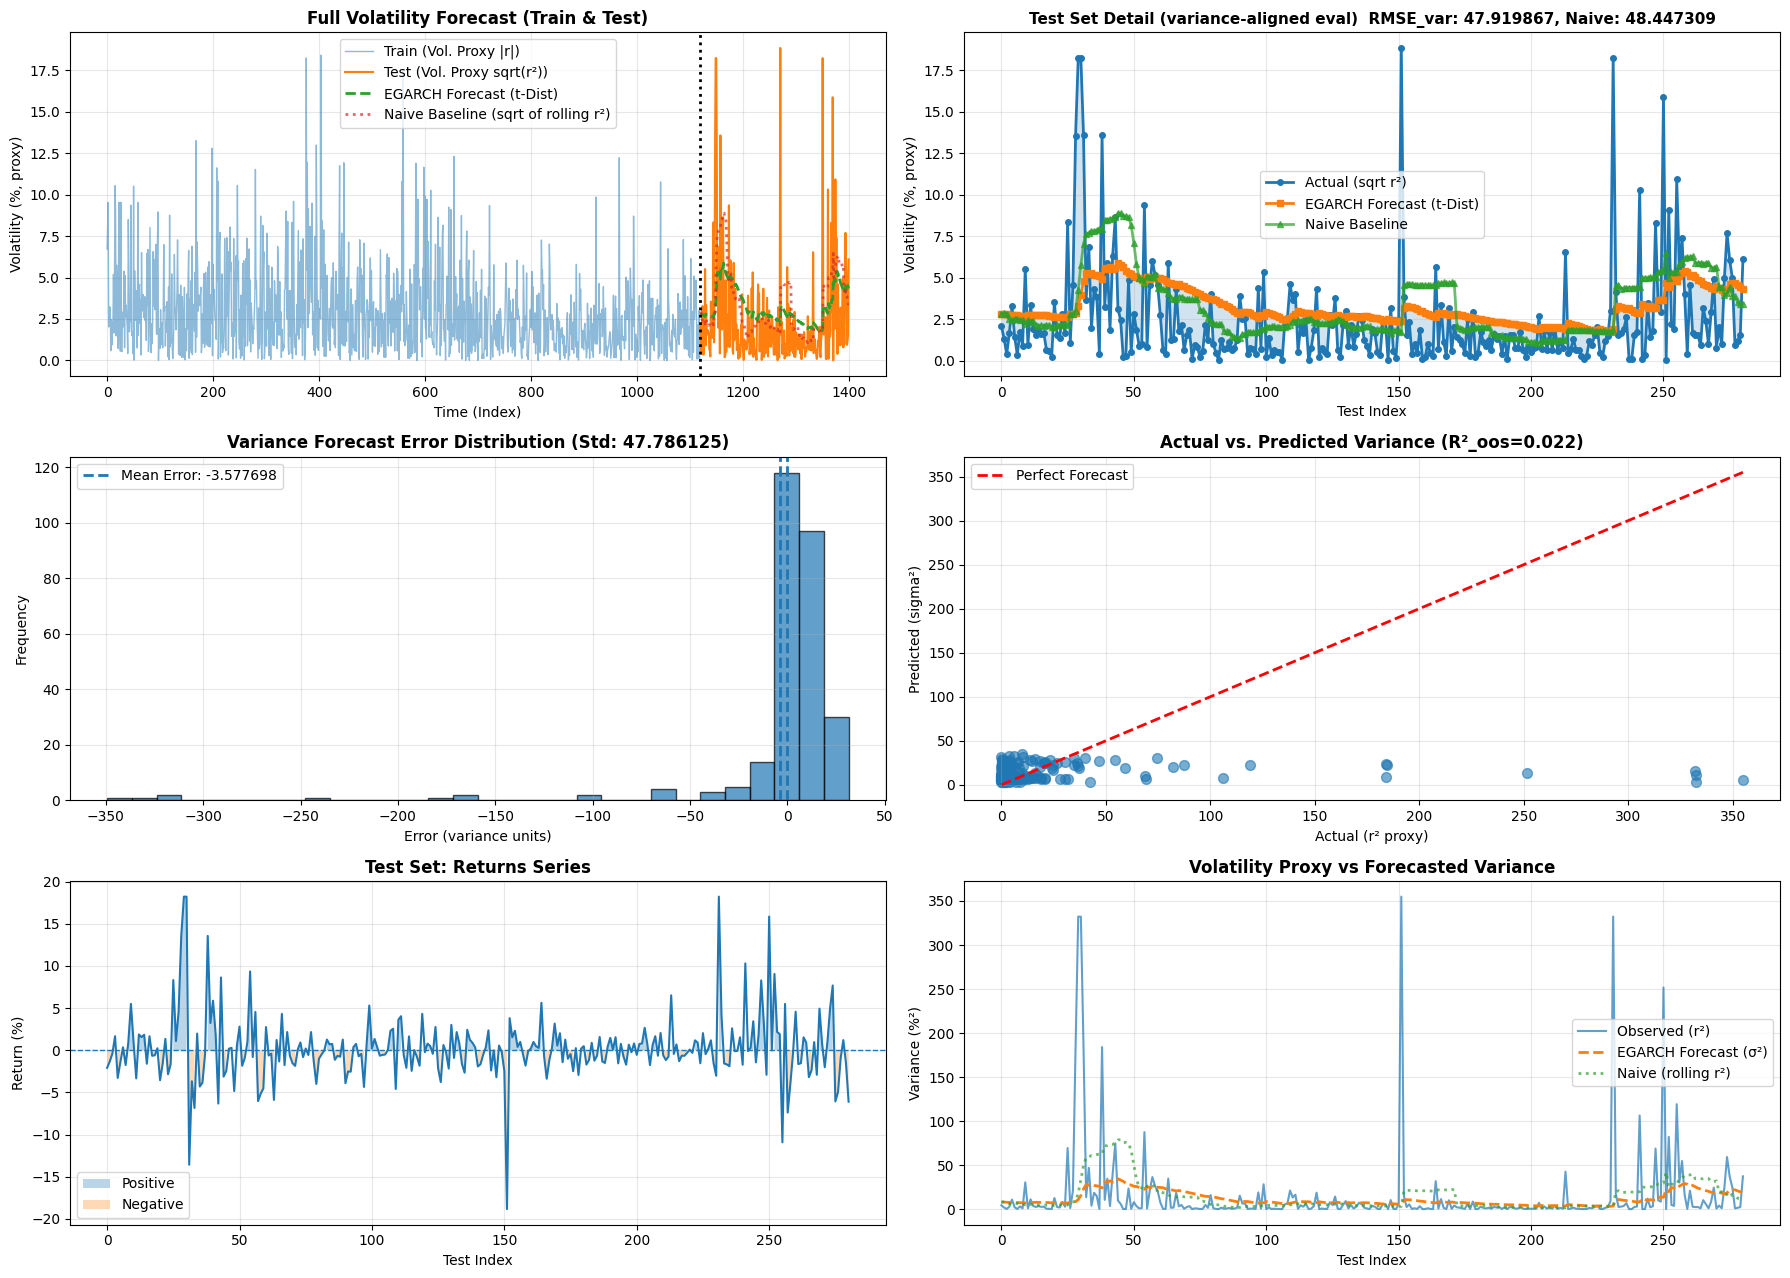


📋 SUMMARY REPORT - ETH 1D EGARCH(1,1,1) - Student's t-Distribution

📁 DATA:
    • Total observations: 1401
    • Test period: 281 candles (~281 days)
    • Mean return: 0.0619%
    • Return std (unconditional): 3.8496%
    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)

🔧 MODEL:
    • EGARCH(1,1,1) - Student's t-Distribution
    • Parameters (from final walk-forward model):
      - ω: 0.028422
      - α: 0.094594
      - γ: 0.024860  [Asymmetry parameter]
      - β: 0.991300
      - ν: 4.719639  [Degrees of Freedom]
    • Volatility persistence (α+β): 1.0726
    • Validation: Walk-Forward (expanding window; no data leakage)
    • Baseline: Rolling mean of r² (variance proxy)

📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):
    GARCH Model:
    • RMSE (var): 47.919867
    • MAE  (var): 17.504211
    • MAPE (var): 98720.13%
    • QLIKE:      3.888406

    Naive Baseline:
    • RMSE (var): 48.447309
    • MAE  (var): 19.683864
    • QLIKE:  

In [ ]:
# MODEL: EGARCH(1,1,1)
# DISTRIBUTION: Student's t-Distribution (dist='t')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ETH 1D EGARCH(1,1,1) (Student's t-Dist) ANALYSIS - WALK-FORWARD VALIDATION")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA AND CALCULATE RETURNS
# ============================================================================
print("\n[1/7] Loading data and calculating returns...")

raw = np.load("stocks_500.npy", allow_pickle=True).item()
data = {}

for key, df in raw.items():
    stock = key.replace('.csv', '')
    data[stock] = df

frames = []

for stock, df in data.items():
    # 把 index（日期）变成一列
    df = df.reset_index().rename(columns={'index': 'timestamp'})
    # 将日期转换为 datetime，与 sample 完全一致
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    # 加入股票列
    df['stock'] = stock
    df = df.sort_values('timestamp').reset_index(drop=True)
    # Calculate log returns (in %)
    df['returns'] = np.log(df['close'] / df['close'].shift(1)) * 100
    df = df.dropna(subset=['returns'])  # Drop the first row (NaN)
    df['realized_var'] = df['returns'] ** 2

    frames.append(df)




df=frames[6] #选择想处理的股票

print(f"✓ Total observations: {len(df)}")
print(f"✓ Date range: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
print(f"✓ Price range: ${df['close'].min():.2f} → ${df['close'].max():.2f}")

# Return statistics
print(f"\n📊 Return Statistics:")
print(f"    Mean: {df['returns'].mean():.4f}%")
print(f"    Std Dev: {df['returns'].std():.4f}%")
print(f"    Min: {df['returns'].min():.4f}%")
print(f"    Max: {df['returns'].max():.4f}%")
print(f"    Skewness: {df['returns'].skew():.4f}")
print(f"    Kurtosis: {df['returns'].kurtosis():.4f}")

# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (80%-20%)
# ============================================================================
print("\n[2/7] Splitting data (80% train - 20% test)...")

returns_series = df['returns']
rv_series = df['realized_var']   #平方项
train_size = int(len(returns_series) * 0.8)

train_returns = returns_series.iloc[:train_size]
test_returns = returns_series.iloc[train_size:]

train_rv = rv_series.iloc[:train_size]  #平方项
test_rv  = rv_series.iloc[train_size:] 

# Rolling window size (used for naive baseline)
vol_window = 20  

print(f"✓ Training set: {train_size} observations")
print(f"✓ Test set: {len(test_returns)} observations")
print(f"✓ Test period: {df['timestamp'].iloc[train_size]} → {df['timestamp'].iloc[-1]}")

# ============================================================================
# STEP 3: TRAIN BASELINE EGARCH(1,1,1) - STUDENT'S T-DISTRIBUTION MODEL
# ============================================================================
print("\n[3/7] Training baseline EGARCH(1,1,1) - Student's t-distribution model...")

# Train the initial model
baseline_model = arch_model(train_returns,
                            mean='Zero',
                            vol='EGARCH',
                            p=1,
                            o=1,  # Asymmetry term
                            q=1,
                            dist='t',  # Student's t-Distribution
                            rescale=False)

baseline_fitted = baseline_model.fit(disp='off')
params = baseline_fitted.params

print(f"\n📊 EGARCH(1,1,1) - Student's t-Distribution (Baseline Model):")
print(f"    Parameters: {list(params.index)}")
print(f"\n    Model Parameters:")
print(f"    ω (omega): {params.get('omega', 'N/A'):.6f}")
print(f"    α (alpha): {params.get('alpha[1]', 'N/A'):.6f}")
print(f"    γ (gamma): {params.get('gamma[1]', 'N/A'):.6f}  [Asymmetry parameter]")
print(f"    β (beta):  {params.get('beta[1]', 'N/A'):.6f}")

# Check for 'nu' parameter (should exist for t-dist)
if 'nu' in params.index:
    nu = params['nu']
    print(f"    ν (nu): {nu:.6f}  [Degrees of Freedom for t-Dist]")
    print(f"\n    📊 Distribution Shape (Baseline):")
    if nu < 5:
        print(f"    → Very fat tails (ν={nu:.2f}). Extreme events are frequent.")
    elif nu < 10:
        print(f"    → Fat tails (ν={nu:.2f}). More extreme events than normal.")
    else:
        print(f"    → Moderately fat tails (ν={nu:.2f}).")
else:
    print(f"    ⚠️ WARNING: 'nu' parameter not found, which is inconsistent with dist='t'.")

print(f"\n    Volatility Persistence (β): {params.get('beta[1]', 0):.6f}")
print("    ✅ EGARCH model is stationary by design (log-linear)")

# Asymmetry analysis
gamma = params.get('gamma[1]', 0)
print(f"\n    📊 Asymmetry Analysis (Leverage Effect):")
if gamma < -0.1:
    print(f"    📉 Strong leverage effect (γ={gamma:.4f})")
    print(f"    → Negative shocks (bad news) increase volatility significantly more.")
elif gamma < 0:
    print(f"    ✓ Leverage effect present (γ={gamma:.4f})")
    print(f"    → Negative shocks are more impactful.")
elif gamma > 0.1:
    print(f"    📈 Inverse leverage effect (γ={gamma:.4f})")
    print(f"    → Positive shocks (good news) increase volatility more (rare).")
else:
    print(f"    ⚖️ Weak or no asymmetry (γ={gamma:.4f}).")

# ============================================================================
# STEP 4: WALK-FORWARD VALIDATION
# ============================================================================
print("\n[4/7] Starting walk-forward validation (EGARCH, t-Dist)...")
print("      (Model will be refit at each step)")


# Store predictions
predictions_var = []
actual_var = []
naive_var = []
final_fitted_model = None

# For each test point
for i in range(len(test_returns)):
    # Current training data (train + test up to this point)
    if i > 0:
        history = np.concatenate([train_returns, test_returns[:i]])
        rv_history = np.concatenate([train_rv, actual_var[:i]])
    else:
        history = train_returns
        rv_history = train_rv
    
    try:
        # Train EGARCH(1,1,1) - Student's t-distribution
        model = arch_model(history,
                           mean='Zero',
                           vol='EGARCH',
                           p=1,
                           o=1,
                           q=1,
                           dist='t',
                           rescale=False)
        fitted = model.fit(disp='off')
        final_fitted_model = fitted 
        
        # 1-step ahead volatility forecast
        forecast = fitted.forecast(horizon=1, reindex=False)
        predicted_variance = float(forecast.variance.values[-1, 0])
        predictions_var.append(predicted_variance)

        
        # ACTUAL VOLATILITY: Simple proxy (absolute return)
        actual_var.append(float(test_rv.iloc[i]))

        
        # NAIVE FORECAST: Mean of all actual volatility seen so far
        window = rv_history[-vol_window:]# 过去 vol_window 个 realized_var 的均值
        naive_pred = float(np.mean(window))
        naive_var.append(naive_pred)

        
    except Exception as e:
        print(f"    ⚠️ Error at step {i+1}: {str(e)[:50]}")
        # In case of error, use the last known volatility
        if len(predictions_var) > 0:
            predictions_var.append(predictions_var[-1])
        else:
            # For the very first prediction, use train volatility
            predictions_var.append(np.mean(np.abs(train_returns[-vol_window:])))
        
        actual_var.append(abs(test_returns[i])**2)
        
        if i > 0:
            naive_var.append(np.mean(actual_var[:i]))
        else:
            naive_var.append(np.mean(np.abs(train_returns[-vol_window:])))
    
    # Show progress
    if (i + 1) % 10 == 0 or i == len(test_returns) - 1:
        print(f"    Progress: {i+1}/{len(test_returns)} completed")

predictions_var = np.array(predictions_var)
actual_var = np.array(actual_var)
naive_var = np.array(naive_var)

# ============================================================================
# STEP 5: PERFORMANCE METRICS  (Variance-level, aligned with GARCH)
# ============================================================================
print("\n[5/7] Calculating performance metrics...")

# Ensure numpy arrays
actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Safety: avoid zeros in denominators / logs
eps = 1e-12
pred_var_safe = np.maximum(predictions_var, eps)
naive_var_safe = np.maximum(naive_var, eps)

# --------------------
# Metrics on variance
# --------------------
rmse_var = np.sqrt(mean_squared_error(actual_var, predictions_var))
mae_var = mean_absolute_error(actual_var, predictions_var)
mape_var = np.mean(np.abs((actual_var - predictions_var) / (actual_var + eps))) * 100

# QLIKE (standard for variance forecasting)
qlike_garch = np.mean(actual_var / pred_var_safe + np.log(pred_var_safe))
qlike_naive = np.mean(actual_var / naive_var_safe + np.log(naive_var_safe))

# Out-of-sample R² relative to naive baseline (Campbell-Thompson style)
ss_res = np.sum((actual_var - predictions_var) ** 2)
ss_tot = np.sum((actual_var - naive_var) ** 2)
r2_oos = 1 - (ss_res / ss_tot)

# Naive model performance (variance)
naive_rmse_var = np.sqrt(mean_squared_error(actual_var, naive_var))
naive_mae_var = mean_absolute_error(actual_var, naive_var)

print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target: r^2 proxy):")
print(f"    EGARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline (Rolling Mean of r^2):")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):.2f}%")

# --------------------
# Descriptive stats
# --------------------
print(f"\n📊 Variance Statistics (Test Set):")
print(f"    Actual variance proxy (r^2):")
print(f"    • Mean: {np.mean(actual_var):.6f}")
print(f"    • Std:  {np.std(actual_var):.6f}")
print(f"    • Min:  {np.min(actual_var):.6f}")
print(f"    • Max:  {np.max(actual_var):.6f}")

print(f"\n    EGARCH predicted variance (sigma^2):")
print(f"    • Mean: {np.mean(predictions_var):.6f}")
print(f"    • Std:  {np.std(predictions_var):.6f}")

print(f"\n    Naive predicted variance:")
print(f"    • Mean: {np.mean(naive_var):.6f}")
print(f"    • Std:  {np.std(naive_var):.6f}")

# Optional: also report volatility-level (std) for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol = np.sqrt(np.maximum(predictions_var, 0))
naive_vol = np.sqrt(np.maximum(naive_var, 0))

print(f"\n📌 (Optional) Volatility-level summary (sqrt of variance):")
print(f"    Actual vol proxy:")
print(f"    • Mean: {np.mean(actual_vol):.6f}")
print(f"    • Std:  {np.std(actual_vol):.6f}")
print(f"    EGARCH predicted vol:")
print(f"    • Mean: {np.mean(pred_vol):.6f}")
print(f"    • Std:  {np.std(pred_vol):.6f}")
print(f"    Naive predicted vol:")
print(f"    • Mean: {np.mean(naive_vol):.6f}")
print(f"    • Std:  {np.std(naive_vol):.6f}")

# ============================================================================
# STEP 6: VISUALIZATION (aligned)
# ============================================================================
print("\n[6/7] Generating plots...")

# Ensure numpy
train_returns_np = np.asarray(train_returns, dtype=float)  # Series/ndarray都可
test_returns_np  = np.asarray(test_returns, dtype=float)

actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Convert variance -> volatility for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol   = np.sqrt(np.maximum(predictions_var, 0))
naive_vol  = np.sqrt(np.maximum(naive_var, 0))

# A consistent "train volatility proxy" for the full-series plot
train_vol_proxy = np.sqrt(np.maximum((train_returns_np**2), 0))  # = abs(train_returns)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# 1. Full series: volatility proxy + forecasts on test
train_x = np.arange(len(train_vol_proxy))
test_x = np.arange(len(train_vol_proxy), len(train_vol_proxy) + len(actual_vol))

axes[0, 0].plot(train_x, train_vol_proxy, label='Train (Vol. Proxy |r|)',
                alpha=0.5, linewidth=1)
axes[0, 0].plot(test_x, actual_vol, label='Test (Vol. Proxy sqrt(r²))',
                linewidth=1.5)
axes[0, 0].plot(test_x, pred_vol, label='EGARCH Forecast (t-Dist)',
                linestyle='--', linewidth=2)
axes[0, 0].plot(test_x, naive_vol, label='Naive Baseline (sqrt of rolling r²)',
                linestyle=':', linewidth=2, alpha=0.7)
axes[0, 0].axvline(x=len(train_vol_proxy), color='black', linestyle=':', linewidth=2)
axes[0, 0].set_title('Full Volatility Forecast (Train & Test)', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Time (Index)')
axes[0, 0].set_ylabel('Volatility (%, proxy)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Test detail (volatility scale)
axes[0, 1].plot(actual_vol, label='Actual (sqrt r²)',
                linewidth=2, marker='o', markersize=4)
axes[0, 1].plot(pred_vol, label='EGARCH Forecast (t-Dist)',
                linewidth=2, marker='s', markersize=4)
axes[0, 1].plot(naive_vol, label='Naive Baseline',
                linewidth=2, marker='^', markersize=4, alpha=0.7)
axes[0, 1].fill_between(range(len(actual_vol)), actual_vol, pred_vol, alpha=0.2)
axes[0, 1].set_title(
    f'Test Set Detail (variance-aligned eval)  RMSE_var: {rmse_var:.6f}, Naive: {naive_rmse_var:.6f}',
    fontweight='bold', fontsize=11
)
axes[0, 1].set_xlabel('Test Index')
axes[0, 1].set_ylabel('Volatility (%, proxy)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Error distribution (variance level is more principled)
errors_var = predictions_var - actual_var 
axes[1, 0].hist(errors_var, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, linestyle='--', linewidth=2)
axes[1, 0].axvline(x=np.mean(errors_var), linestyle='--', linewidth=2,
                   label=f'Mean Error: {np.mean(errors_var):.6f}')
axes[1, 0].set_title(f'Variance Forecast Error Distribution (Std: {np.std(errors_var):.6f})',
                     fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Error (variance units)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter plot (variance)
axes[1, 1].scatter(actual_var, predictions_var, alpha=0.6, s=50)
minv = min(actual_var.min(), predictions_var.min())
maxv = max(actual_var.max(), predictions_var.max())
axes[1, 1].plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Perfect Forecast')
axes[1, 1].set_title(f'Actual vs. Predicted Variance (R²_oos={r2_oos:.3f})',
                     fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Actual (r² proxy)')
axes[1, 1].set_ylabel('Predicted (sigma²)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Returns time series
test_x_returns = np.arange(len(test_returns_np))
axes[2, 0].plot(test_x_returns, test_returns_np, linewidth=1.5)
axes[2, 0].axhline(y=0, linestyle='--', linewidth=1)
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np > 0), alpha=0.3, label='Positive')
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np <= 0), alpha=0.3, label='Negative')
axes[2, 0].set_title('Test Set: Returns Series', fontweight='bold', fontsize=12)
axes[2, 0].set_xlabel('Test Index')
axes[2, 0].set_ylabel('Return (%)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Volatility clustering (variance view)
squared_returns = test_returns_np ** 2
axes[2, 1].plot(squared_returns, linewidth=1.5, alpha=0.7, label='Observed (r²)')
axes[2, 1].plot(predictions_var, linewidth=2, linestyle='--', label='EGARCH Forecast (σ²)')
axes[2, 1].plot(naive_var, linewidth=2, linestyle=':', alpha=0.7, label='Naive (rolling r²)')
axes[2, 1].set_title('Volatility Proxy vs Forecasted Variance', fontweight='bold', fontsize=12)
axes[2, 1].set_xlabel('Test Index')
axes[2, 1].set_ylabel('Variance (%²)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
plt.savefig('egarch_t_dist_1d_walkforward_analysis_ETH.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved: egarch_t_dist_1d_walkforward_analysis_ETH.png")
plt.show()

# ============================================================================
# STEP 7: SUMMARY REPORT (Variance-aligned)
# ============================================================================
print("\n" + "="*80)
print("📋 SUMMARY REPORT - ETH 1D EGARCH(1,1,1) - Student's t-Distribution")
print("="*80)

print(f"\n📁 DATA:")
print(f"    • Total observations: {len(df)}")
print(f"    • Test period: {len(test_returns)} candles (~{len(test_returns)} days)")
print(f"    • Mean return: {df['returns'].mean():.4f}%")
print(f"    • Return std (unconditional): {df['returns'].std():.4f}%")
print(f"    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)")

print(f"\n🔧 MODEL:")
print(f"    • EGARCH(1,1,1) - Student's t-Distribution")

# Use parameters from the final model fitted during walk-forward
if final_fitted_model:
    params = final_fitted_model.params
    print(f"    • Parameters (from final walk-forward model):")
else:
    params = baseline_fitted.params # Fallback if loop failed
    print(f"    • Parameters (from baseline model - WARNING: loop might have failed):")

# Safely extract parameters
print(f"      - ω: {params.get('omega', 'N/A'):.6f}")
print(f"      - α: {params.get('alpha[1]', 'N/A'):.6f}")
print(f"      - γ: {params.get('gamma[1]', 'N/A'):.6f}  [Asymmetry parameter]")
print(f"      - β: {params.get('beta[1]', 'N/A'):.6f}")

# 'nu' parameter check
if 'nu' in params.index:
    nu_val = params['nu']
    print(f"      - ν: {nu_val:.6f}  [Degrees of Freedom]")
else:
    nu_val = None # Set to None if not found
    print(f"    ⚠️ WARNING: 'nu' parameter not found in final model, inconsistent with dist='t'.")

persistence = alpha + beta
print(f"    • Volatility persistence (α+β): {persistence:.4f}")
print(f"    • Validation: Walk-Forward (expanding window; no data leakage)")
print(f"    • Baseline: Rolling mean of r² (variance proxy)")

# Metrics (variance-level)
print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):")
print(f"    GARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline:")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):+.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):+.2f}%")

print(f"\n💡 EVALUATION:")

# RMSE and R²
rmse_improvement = ((naive_rmse_var - rmse_var) / naive_rmse_var * 100)
if rmse_improvement > 10:
    print(f"    ✅ Performance: EGARCH is {rmse_improvement:.1f}% better than naive (Significant).")
elif rmse_improvement > 0:
    print(f"    ✓ Performance: EGARCH is {rmse_improvement:.1f}% better than naive (Moderate/Slight).")
else:
    print(f"    ❌ Performance: EGARCH is {rmse_improvement:.1f}% worse than naive!")

if r2_oos > 0.1:
    print(f"    ✅ R²={r2_oos:.3f} - Model explains variance better than naive baseline.")
else:
    print(f"    ⚠️ R²={r2_oos:.3f} - Model is not much better than naive baseline.")

# Asymmetry (Leverage Effect) - Gamma
gamma = params.get('gamma[1]', 0)
print(f"\n    • Asymmetry (Leverage Effect):")
if gamma < -0.1:
    print("    • 📉 Strong leverage effect - negative shocks dominate volatility.")
elif gamma < 0:
    print("    • ✓ Leverage effect present - negative shocks are more impactful.")
else:
    print("    • ⚖️ Near symmetric shock effect (or positive, which is rare).")

# Volatility Persistence - Beta
beta_val = params.get('beta[1]', 0)
print(f"    • Volatility Persistence:")
if beta_val > 0.95:
    print("    • ⚠️ High persistence - shocks have a very long-lasting effect")
else:
    print("    • ✓ Moderate persistence - shocks decay gradually")

# Distribution Shape - Nu (Tails)
print(f"    • Distribution Shape (Risk):")
if nu_val is not None:
    if nu_val < 5:
        print(f"    • ⚠️ Very high risk of extreme events (fat tails) (ν={nu_val:.2f})")
    elif nu_val < 10:
        print(f"    • ⚠️ High risk of extreme events (fat tails) (ν={nu_val:.2f})")
    else:
        print(f"    • ✅ Moderate risk of extreme events (ν={nu_val:.2f})")
else:
    print("    • ⚠️ 'nu' parameter (tails) could not be evaluated.")


print(f"\n📈 VOLATILITY CLUSTERING:")
squared_returns = test_returns ** 2
acorr_sq_returns = np.corrcoef(squared_returns[:-1], squared_returns[1:])[0, 1]
print(f"    • Squared returns autocorrelation: {acorr_sq_returns:.4f}")
if acorr_sq_returns > 0.1:
    print("    ✅ Volatility clustering is present (EGARCH is appropriate)")
else:
    print("    ⚠️ Weak volatility clustering")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

print("\n💡 EGARCH (t-Dist) ADVANTAGES:")
print("    • ✅ Models asymmetric shocks (leverage effect via 'γ' parameter)")
print("    • ✅ Models fat tails (high kurtosis via 'ν' parameter)")
print("    • ✅ Always stationary (log-linear structure)")


print("\n💡 NEXT STEPS:")
print("    • Compare this model's R²/RMSE against the GARCH(1,1) and EGARCH-Normal models")
print("    • Try this EGARCH model with 'dist=skewt' (to also capture skewness)")
print("    • Try GJR-GARCH (another asymmetric model)")
print("    • Calculate Value at Risk (VaR) using the t-distribution parameters")




ETH 1D EGARCH(1,1,1) (Skewed t-Dist) ANALYSIS - WALK-FORWARD VALIDATION

[1/7] Loading data and calculating returns...
✓ Total observations: 1401
✓ Date range: 2020-01-03 00:00:00 → 2025-10-17 00:00:00
✓ Price range: $40.64 → $197.02

📊 Return Statistics:
    Mean: 0.0619%
    Std Dev: 3.8496%
    Min: -18.8403%
    Max: 18.2346%
    Skewness: 0.4159
    Kurtosis: 3.0958

[2/7] Splitting data (80% train - 20% test)...
✓ Training set: 1120 observations
✓ Test set: 281 observations
✓ Test period: 2024-08-16 00:00:00 → 2025-10-17 00:00:00

[3/7] Training baseline EGARCH(1,1,1) - Skewed t-distribution model...

📊 EGARCH(1,1,1) - Skewed t-Distribution (Baseline Model):
    Parameters: ['omega', 'alpha[1]', 'gamma[1]', 'beta[1]', 'eta', 'lambda']

    Model Parameters:
    ω (omega): 0.012301
    α (alpha): 0.044914
    γ (gamma): 0.011338  [Asymmetry parameter]
    β (beta):  0.995639

    📊 Distribution Shape Parameters (Baseline):
    ⚠️ WARNING: 'nu' parameter not found, inconsistent wit

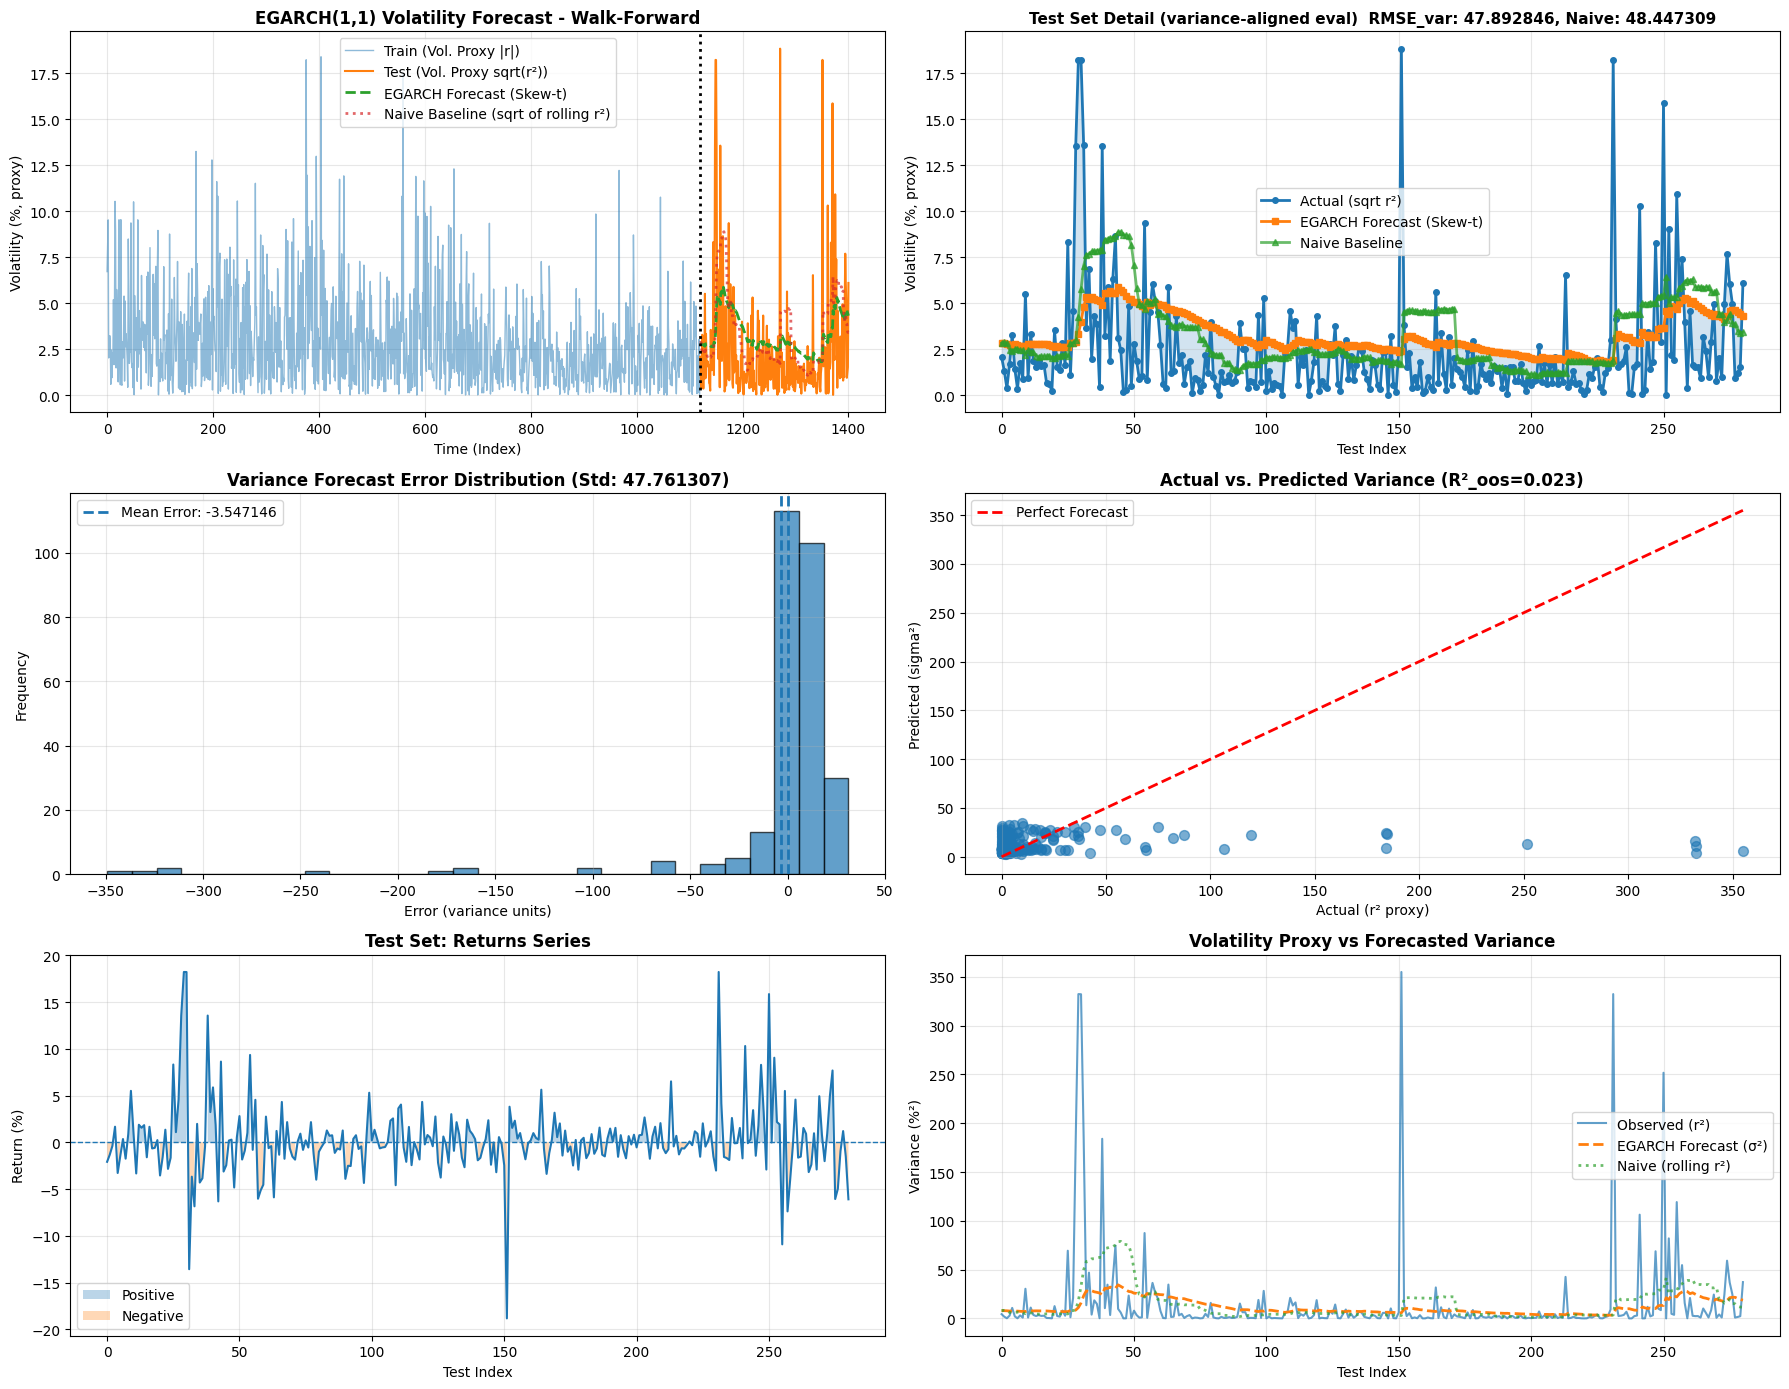


📋 SUMMARY REPORT - ETH 1D EGARCH(1,1,1) - Skewed Student's t-Distribution

📁 DATA:
    • Total observations: 1401
    • Test period: 281 candles (~281 days)
    • Mean return: 0.0619%
    • Return std (unconditional): 3.8496%
    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)

🔧 MODEL:
    • EGARCH(1,1,1) - Skewed Student's t-Distribution
    • Parameters (from final walk-forward fitted model):
      - ω: 0.027460
      - α: 0.089777
      - γ: 0.025559  [Asymmetry parameter (Leverage)]
      - β: 0.991464

    • Distribution Shape (Final Model):
    ⚠️ WARNING: 'nu' parameter not found, inconsistent with dist='skewt'.
      - λ: 0.134158  [Skewness Parameter]

📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):
    EGARCH (Skew-t) Model:
    • RMSE (var): 47.892846
    • MAE  (var): 17.520805
    • MAPE (var): 96604.45%
    • QLIKE:      3.873626

    Naive Baseline:
    • RMSE (var): 48.447309
    • MAE  (var): 19.683864
    • QLIKE:      3

In [ ]:
# MODEL: EGARCH(1,1,1)
# DISTRIBUTION: Skewed Student's t-Distribution (dist='skewt')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ETH 1D EGARCH(1,1,1) (Skewed t-Dist) ANALYSIS - WALK-FORWARD VALIDATION") 
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA AND CALCULATE RETURNS
# ============================================================================
print("\n[1/7] Loading data and calculating returns...")

raw = np.load("stocks_500.npy", allow_pickle=True).item()
data = {}

for key, df in raw.items():
    stock = key.replace('.csv', '')
    data[stock] = df

frames = []

for stock, df in data.items():
    # 把 index（日期）变成一列
    df = df.reset_index().rename(columns={'index': 'timestamp'})
    # 将日期转换为 datetime，与 sample 完全一致
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    # 加入股票列
    df['stock'] = stock
    df = df.sort_values('timestamp').reset_index(drop=True)
    # Calculate log returns (in %)
    df['returns'] = np.log(df['close'] / df['close'].shift(1)) * 100
    df = df.dropna(subset=['returns'])  # Drop the first row (NaN)
    df['realized_var'] = df['returns'] ** 2

    frames.append(df)




df=frames[6] #选择想处理的股票

print(f"✓ Total observations: {len(df)}")
print(f"✓ Date range: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
print(f"✓ Price range: ${df['close'].min():.2f} → ${df['close'].max():.2f}")

# Return statistics
print(f"\n📊 Return Statistics:")
print(f"    Mean: {df['returns'].mean():.4f}%")
print(f"    Std Dev: {df['returns'].std():.4f}%")
print(f"    Min: {df['returns'].min():.4f}%")
print(f"    Max: {df['returns'].max():.4f}%")
print(f"    Skewness: {df['returns'].skew():.4f}")
print(f"    Kurtosis: {df['returns'].kurtosis():.4f}")

# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (80%-20%)
# ============================================================================
print("\n[2/7] Splitting data (80% train - 20% test)...")

returns_series = df['returns']
rv_series = df['realized_var']   #平方项
train_size = int(len(returns_series) * 0.8)

train_returns = returns_series.iloc[:train_size]
test_returns = returns_series.iloc[train_size:]

train_rv = rv_series.iloc[:train_size]  #平方项
test_rv  = rv_series.iloc[train_size:] 

# Rolling window size (used for naive baseline)
vol_window = 20  

print(f"✓ Training set: {train_size} observations")
print(f"✓ Test set: {len(test_returns)} observations")
print(f"✓ Test period: {df['timestamp'].iloc[train_size]} → {df['timestamp'].iloc[-1]}")

# ============================================================================
# STEP 3: TRAIN BASELINE EGARCH(1,1,1) - SKEWED T-DISTRIBUTION MODEL
# ============================================================================
print("\n[3/7] Training baseline EGARCH(1,1,1) - Skewed t-distribution model...")

# Train the initial model
baseline_model = arch_model(train_returns,
                            mean='Zero',
                            vol='EGARCH',
                            p=1,
                            o=1,  # Asymmetry term (gamma)
                            q=1,
                            dist='skewt',  # <-- Skewed t-Distribution
                            rescale=False)

baseline_fitted = baseline_model.fit(disp='off')
params = baseline_fitted.params

print(f"\n📊 EGARCH(1,1,1) - Skewed t-Distribution (Baseline Model):")
print(f"    Parameters: {list(params.index)}")
print(f"\n    Model Parameters:")
print(f"    ω (omega): {params.get('omega', 'N/A'):.6f}")
print(f"    α (alpha): {params.get('alpha[1]', 'N/A'):.6f}")
print(f"    γ (gamma): {params.get('gamma[1]', 'N/A'):.6f}  [Asymmetry parameter]")
print(f"    β (beta):  {params.get('beta[1]', 'N/A'):.6f}")

# 'nu' and 'lambda' parameter CHECK
print(f"\n    📊 Distribution Shape Parameters (Baseline):")
if 'nu' in params.index:
    nu = params['nu']
    print(f"    ν (nu): {nu:.6f}  [Degrees of Freedom / Tail Fatness]")
    if nu < 5:
        print(f"    → Very fat tails (ν={nu:.2f}). Extreme events are frequent.")
    elif nu < 10:
        print(f"    → Fat tails (ν={nu:.2f}). More extreme events than normal.")
    else:
        print(f"    → Moderately fat tails (ν={nu:.2f}).")
else:
    print(f"    ⚠️ WARNING: 'nu' parameter not found, inconsistent with dist='skewt'.")

if 'lambda' in params.index:
    lam = params['lambda']
    print(f"    λ (lambda): {lam:.6f}  [Skewness Parameter]")
    if lam < -0.1:
        print(f"    → Negatively skewed (λ={lam:.2f}). Large negative returns are more likely.")
    elif lam > 0.1:
        print(f"    → Positively skewed (λ={lam:.2f}). Large positive returns are more likely.")
    else:
        print(f"    → Approximately symmetric (λ={lam:.2f}).")
else:
    print(f"    ⚠️ WARNING: 'lambda' parameter not found, inconsistent with dist='skewt'.")


print(f"\n    Volatility Persistence (β): {params.get('beta[1]', 0):.6f}")
print("    ✅ EGARCH model is stationary by design (log-linear)")

# Asymmetry analysis
gamma = params.get('gamma[1]', 0)
print(f"\n    📊 Asymmetry Analysis (Leverage Effect):")
if gamma < -0.1:
    print(f"    📉 Strong leverage effect (γ={gamma:.4f})")
    print(f"    → Negative shocks (bad news) increase volatility significantly more.")
elif gamma < 0:
    print(f"    ✓ Leverage effect present (γ={gamma:.4f})")
    print(f"    → Negative shocks are more impactful.")
else:
    print(f"    ⚖️ Weak or no asymmetry (γ={gamma:.4f}). (Or positive, which is rare)")


# ============================================================================
# STEP 4: WALK-FORWARD VALIDATION
# ============================================================================
print("\n[4/7] Starting walk-forward validation...")
print("      (GARCH model will be refit at each step)")

# Store predictions
predictions_var = []
actual_var = []
naive_var = []
final_fitted_model = None

# For each test point
for i in range(len(test_returns)):
    # Current training data (train + test up to this point)
    if i > 0:
        history = np.concatenate([train_returns, test_returns[:i]])
        rv_history = np.concatenate([train_rv, actual_var[:i]])
    else:
        history = train_returns
        rv_history = train_rv
    
    try:
        # Train EGARCH(1,1,1) - Skewed t-distribution
        model = arch_model(history,
                           mean='Zero',
                           vol='EGARCH',
                           p=1,
                           o=1,
                           q=1,
                           dist='skewt',
                           rescale=False)
        fitted = model.fit(disp='off')
        final_fitted_model = fitted 
        
        # 1-step ahead volatility forecast
        forecast = fitted.forecast(horizon=1, reindex=False)
        predicted_variance = float(forecast.variance.values[-1, 0])
        predictions_var.append(predicted_variance)

        
        # ACTUAL VOLATILITY: Simple proxy (absolute return)
        actual_var.append(float(test_rv.iloc[i]))

        
        # NAIVE FORECAST: Mean of all actual volatility seen so far
        window = rv_history[-vol_window:]# 过去 vol_window 个 realized_var 的均值
        naive_pred = float(np.mean(window))
        naive_var.append(naive_pred)

        
    except Exception as e:
        print(f"    ⚠️ Error at step {i+1}: {str(e)[:50]}")
        # In case of error, use the last known volatility
        if len(predictions_var) > 0:
            predictions_var.append(predictions_var[-1])
        else:
            # For the very first prediction, use train volatility
            predictions_var.append(np.mean(np.abs(train_returns[-vol_window:])))
        
        actual_var.append(abs(test_returns[i])**2)
        
        if i > 0:
            naive_var.append(np.mean(actual_var[:i]))
        else:
            naive_var.append(np.mean(np.abs(train_returns[-vol_window:])))
    
    # Show progress
    if (i + 1) % 10 == 0 or i == len(test_returns) - 1:
        print(f"    Progress: {i+1}/{len(test_returns)} completed")

predictions_var = np.array(predictions_var)
actual_var = np.array(actual_var)
naive_var = np.array(naive_var)

# ============================================================================
# STEP 5: PERFORMANCE METRICS  (Variance-level, aligned with GARCH)
# ============================================================================
print("\n[5/7] Calculating performance metrics...")

# Ensure numpy arrays
actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Safety: avoid zeros in denominators / logs
eps = 1e-12
pred_var_safe = np.maximum(predictions_var, eps)
naive_var_safe = np.maximum(naive_var, eps)

# --------------------
# Metrics on variance
# --------------------
rmse_var = np.sqrt(mean_squared_error(actual_var, predictions_var))
mae_var = mean_absolute_error(actual_var, predictions_var)
mape_var = np.mean(np.abs((actual_var - predictions_var) / (actual_var + eps))) * 100

# QLIKE (standard for variance forecasting)
qlike_garch = np.mean(actual_var / pred_var_safe + np.log(pred_var_safe))
qlike_naive = np.mean(actual_var / naive_var_safe + np.log(naive_var_safe))

# Out-of-sample R² relative to naive baseline (Campbell-Thompson style)
ss_res = np.sum((actual_var - predictions_var) ** 2)
ss_tot = np.sum((actual_var - naive_var) ** 2)
r2_oos = 1 - (ss_res / ss_tot)

# Naive model performance (variance)
naive_rmse_var = np.sqrt(mean_squared_error(actual_var, naive_var))
naive_mae_var = mean_absolute_error(actual_var, naive_var)

print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target: r^2 proxy):")
print(f"    GARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline (Rolling Mean of r^2):")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):.2f}%")

# --------------------
# Descriptive stats
# --------------------
print(f"\n📊 Variance Statistics (Test Set):")
print(f"    Actual variance proxy (r^2):")
print(f"    • Mean: {np.mean(actual_var):.6f}")
print(f"    • Std:  {np.std(actual_var):.6f}")
print(f"    • Min:  {np.min(actual_var):.6f}")
print(f"    • Max:  {np.max(actual_var):.6f}")

print(f"\n    GARCH predicted variance (sigma^2):")
print(f"    • Mean: {np.mean(predictions_var):.6f}")
print(f"    • Std:  {np.std(predictions_var):.6f}")

print(f"\n    Naive predicted variance:")
print(f"    • Mean: {np.mean(naive_var):.6f}")
print(f"    • Std:  {np.std(naive_var):.6f}")

# Optional: also report volatility-level (std) for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol = np.sqrt(np.maximum(predictions_var, 0))
naive_vol = np.sqrt(np.maximum(naive_var, 0))

print(f"\n📌 (Optional) Volatility-level summary (sqrt of variance):")
print(f"    Actual vol proxy:")
print(f"    • Mean: {np.mean(actual_vol):.6f}")
print(f"    • Std:  {np.std(actual_vol):.6f}")
print(f"    GARCH predicted vol:")
print(f"    • Mean: {np.mean(pred_vol):.6f}")
print(f"    • Std:  {np.std(pred_vol):.6f}")
print(f"    Naive predicted vol:")
print(f"    • Mean: {np.mean(naive_vol):.6f}")
print(f"    • Std:  {np.std(naive_vol):.6f}")

# ============================================================================
# STEP 6: VISUALIZATION (aligned)
# ============================================================================
print("\n[6/7] Generating plots...")

# Ensure numpy
train_returns_np = np.asarray(train_returns, dtype=float)  # Series/ndarray都可
test_returns_np  = np.asarray(test_returns, dtype=float)

actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Convert variance -> volatility for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol   = np.sqrt(np.maximum(predictions_var, 0))
naive_vol  = np.sqrt(np.maximum(naive_var, 0))

# A consistent "train volatility proxy" for the full-series plot
train_vol_proxy = np.sqrt(np.maximum((train_returns_np**2), 0))  # = abs(train_returns)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# 1. Full series: volatility proxy + forecasts on test
train_x = np.arange(len(train_vol_proxy))
test_x = np.arange(len(train_vol_proxy), len(train_vol_proxy) + len(actual_vol))

axes[0, 0].plot(train_x, train_vol_proxy, label='Train (Vol. Proxy |r|)',
                alpha=0.5, linewidth=1)
axes[0, 0].plot(test_x, actual_vol, label='Test (Vol. Proxy sqrt(r²))',
                linewidth=1.5)
axes[0, 0].plot(test_x, pred_vol, label='EGARCH Forecast (Skew-t)',
                linestyle='--', linewidth=2)
axes[0, 0].plot(test_x, naive_vol, label='Naive Baseline (sqrt of rolling r²)',
                linestyle=':', linewidth=2, alpha=0.7)
axes[0, 0].axvline(x=len(train_vol_proxy), color='black', linestyle=':', linewidth=2)
axes[0, 0].set_title('EGARCH(1,1) Volatility Forecast - Walk-Forward', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Time (Index)')
axes[0, 0].set_ylabel('Volatility (%, proxy)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Test detail (volatility scale)
axes[0, 1].plot(actual_vol, label='Actual (sqrt r²)',
                linewidth=2, marker='o', markersize=4)
axes[0, 1].plot(pred_vol, label='EGARCH Forecast (Skew-t)',
                linewidth=2, marker='s', markersize=4)
axes[0, 1].plot(naive_vol, label='Naive Baseline',
                linewidth=2, marker='^', markersize=4, alpha=0.7)
axes[0, 1].fill_between(range(len(actual_vol)), actual_vol, pred_vol, alpha=0.2)
axes[0, 1].set_title(
    f'Test Set Detail (variance-aligned eval)  RMSE_var: {rmse_var:.6f}, Naive: {naive_rmse_var:.6f}',
    fontweight='bold', fontsize=11
)
axes[0, 1].set_xlabel('Test Index')
axes[0, 1].set_ylabel('Volatility (%, proxy)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Error distribution (variance level is more principled)
errors_var = predictions_var - actual_var 
axes[1, 0].hist(errors_var, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, linestyle='--', linewidth=2)
axes[1, 0].axvline(x=np.mean(errors_var), linestyle='--', linewidth=2,
                   label=f'Mean Error: {np.mean(errors_var):.6f}')
axes[1, 0].set_title(f'Variance Forecast Error Distribution (Std: {np.std(errors_var):.6f})',
                     fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Error (variance units)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter plot (variance)
axes[1, 1].scatter(actual_var, predictions_var, alpha=0.6, s=50)
minv = min(actual_var.min(), predictions_var.min())
maxv = max(actual_var.max(), predictions_var.max())
axes[1, 1].plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Perfect Forecast')
axes[1, 1].set_title(f'Actual vs. Predicted Variance (R²_oos={r2_oos:.3f})',
                     fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Actual (r² proxy)')
axes[1, 1].set_ylabel('Predicted (sigma²)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Returns time series
test_x_returns = np.arange(len(test_returns_np))
axes[2, 0].plot(test_x_returns, test_returns_np, linewidth=1.5)
axes[2, 0].axhline(y=0, linestyle='--', linewidth=1)
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np > 0), alpha=0.3, label='Positive')
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np <= 0), alpha=0.3, label='Negative')
axes[2, 0].set_title('Test Set: Returns Series', fontweight='bold', fontsize=12)
axes[2, 0].set_xlabel('Test Index')
axes[2, 0].set_ylabel('Return (%)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Volatility clustering (variance view)
squared_returns = test_returns_np ** 2
axes[2, 1].plot(squared_returns, linewidth=1.5, alpha=0.7, label='Observed (r²)')
axes[2, 1].plot(predictions_var, linewidth=2, linestyle='--', label='EGARCH Forecast (σ²)')
axes[2, 1].plot(naive_var, linewidth=2, linestyle=':', alpha=0.7, label='Naive (rolling r²)')
axes[2, 1].set_title('Volatility Proxy vs Forecasted Variance', fontweight='bold', fontsize=12)
axes[2, 1].set_xlabel('Test Index')
axes[2, 1].set_ylabel('Variance (%²)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('egarch_skewt_dist_1d_walkforward_analysis_ETH.png', dpi=300, bbox_inches='tight') 
print("✓ Plot saved: egarch_skewt_dist_1d_walkforward_analysis_ETH.png")
plt.show()

# ============================================================================
# STEP 7: SUMMARY REPORT (Variance-aligned)
# ============================================================================
print("\n" + "="*80)
print("📋 SUMMARY REPORT - ETH 1D EGARCH(1,1,1) - Skewed Student's t-Distribution")
print("="*80)

print(f"\n📁 DATA:")
print(f"    • Total observations: {len(df)}")
print(f"    • Test period: {len(test_returns)} candles (~{len(test_returns)} days)")
print(f"    • Mean return: {df['returns'].mean():.4f}%")
print(f"    • Return std (unconditional): {df['returns'].std():.4f}%")
print(f"    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)")

print(f"\n🔧 MODEL:")
print(f"    • EGARCH(1,1,1) - Skewed Student's t-Distribution")


# Parameters
if final_fitted_model is not None:
    params = final_fitted_model.params
    print(f"    • Parameters (from final walk-forward fitted model):")
else:
    params = baseline_fitted.params
    print(f"    • Parameters (from baseline model - WARNING: walk-forward loop may have failed):")

omega = float(params.get('omega', np.nan))
alpha = float(params.get('alpha[1]', np.nan))
beta  = float(params.get('beta[1]', np.nan))

print(f"      - ω: {params.get('omega', 'N/A'):.6f}")
print(f"      - α: {params.get('alpha[1]', 'N/A'):.6f}")
print(f"      - γ: {params.get('gamma[1]', 'N/A'):.6f}  [Asymmetry parameter (Leverage)]")
print(f"      - β: {params.get('beta[1]', 'N/A'):.6f}")

print(f"\n    • Distribution Shape (Final Model):")
if 'nu' in params.index:
    print(f"      - ν: {params.get('nu', 'N/A'):.6f}  [Degrees of Freedom / Tail Fatness]")
else:
    print(f"    ⚠️ WARNING: 'nu' parameter not found, inconsistent with dist='skewt'.")

if 'lambda' in params.index:
    print(f"      - λ: {params.get('lambda', 'N/A'):.6f}  [Skewness Parameter]")
else:
    print(f"    ⚠️ WARNING: 'lambda' parameter not found, inconsistent with dist='skewt'.")


# Metrics (variance-level)
print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):")
print(f"    EGARCH (Skew-t) Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline:")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):+.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):+.2f}%")

print(f"\n💡 EVALUATION (Based on Final Model Parameters):")

# RMSE and R²
rmse_improvement = ((naive_rmse_var - rmse_var) / naive_rmse_var * 100)
if rmse_improvement > 10:
    print(f"    ✅ Performance: EGARCH is {rmse_improvement:.1f}% better than naive (Significant).")
elif rmse_improvement > 0:
    print(f"    ✓ Performance: EGARCH is {rmse_improvement:.1f}% better than naive (Moderate/Slight).")
else:
    print(f"    ❌ Performance: EGARCH is {rmse_improvement:.1f}% worse than naive!")

if r2_oos > 0.1:
    print(f"    ✅ R²={r2_oos:.3f} - Model explains variance better than naive baseline.")
else:
    print(f"    ⚠️ R²={r2_oos:.3f} - Model is not much better than naive baseline.")

# Asymmetry (Leverage Effect) - Gamma
gamma = params.get('gamma[1]', 0)
print(f"\n    • Asymmetry (Leverage Effect):")
if gamma < -0.1:
    print("    • 📉 Strong leverage effect - negative shocks dominate volatility.")
elif gamma < 0:
    print("    • ✓ Leverage effect present - negative shocks are more impactful.")
else:
    print("    • ⚖️ Near symmetric shock effect (or positive, which is rare).")

# Volatility Persistence - Beta
beta_val = params.get('beta[1]', 0)
print(f"    • Volatility Persistence:")
if beta_val > 0.95:
    print("    • ⚠️ High persistence - shocks have a very long-lasting effect")
else:
    print("    • ✓ Moderate persistence - shocks decay gradually")

# Distribution Shape - Nu (Tails) and Lambda (Skew)
print(f"    • Distribution Shape (Risk):")
if 'nu' in params.index:
    nu = params['nu']
    if nu < 5:
        print(f"    • ⚠️ Very high risk of extreme events (fat tails) (ν={nu:.2f})")
    elif nu < 10:
        print(f"    • ⚠️ High risk of extreme events (fat tails) (ν={nu:.2f})")
    else:
        print(f"    • ✅ Moderate risk of extreme events (ν={nu:.2f})")
else:
    print("    • ⚠️ 'nu' parameter (tails) could not be evaluated.")

if 'lambda' in params.index:
    lam = params['lambda']
    if lam < -0.1:
        print(f"    • 📉 Distribution is negatively skewed (λ={lam:.2f}).")
    elif lam > 0.1:
        print(f"    • 📈 Distribution is positively skewed (λ={lam:.2f}).")
    else:
        print(f"    • ⚖️ Distribution is roughly symmetric (λ={lam:.2f}).")
else:
    print("    • ⚠️ 'lambda' parameter (skew) could not be evaluated.")


print(f"\n📈 VOLATILITY CLUSTERING:")
squared_returns = test_returns ** 2
acorr_sq_returns = np.corrcoef(squared_returns[:-1], squared_returns[1:])[0, 1]
print(f"    • Squared returns autocorrelation: {acorr_sq_returns:.4f}")
if acorr_sq_returns > 0.1:
    print("    ✅ Volatility clustering is present (EGARCH is appropriate)")
else:
    print("    ⚠️ Weak volatility clustering")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

print("\n💡 EGARCH (Skew-t) ADVANTAGES:")
print("    • ✅ Models asymmetric shocks (leverage effect via 'γ' gamma)")
print("    • ✅ Models fat tails (high kurtosis via 'ν' nu)")
print("    • ✅ Models return skewness (asymmetry via 'λ' lambda)")
print("    • ✅ Always stationary (log-linear structure)")


print("\n💡 NEXT STEPS:")
print("    • Compare this model's R²/RMSE against all other models (GARCH, EGARCH-Normal, etc.)")
print("    • Try GJR-GARCH (another asymmetric model) with 'skewt' distribution")
print("    • Calculate Value at Risk (VaR) using the final 'skewt' parameters")

ETH 1D GJR-GARCH(1,1,1) (Normal Dist) ANALYSIS - WALK-FORWARD VALIDATION

[1/7] Loading data and calculating returns...
✓ Total observations: 1401
✓ Date range: 2020-01-03 00:00:00 → 2025-10-17 00:00:00
✓ Price range: $40.64 → $197.02

📊 Return Statistics:
    Mean: 0.0619%
    Std Dev: 3.8496%
    Min: -18.8403%
    Max: 18.2346%
    Skewness: 0.4159
    Kurtosis: 3.0958

[2/7] Splitting data (80% train - 20% test)...
✓ Training set: 1120 observations
✓ Test set: 281 observations
✓ Test period: 2024-08-16 00:00:00 → 2025-10-17 00:00:00

[3/7] Training baseline GJR-GARCH(1,1,1) - Normal distribution model...

📊 GJR-GARCH(1,1,1) - Normal Distribution (Baseline Model):
    (Glosten-Jagannathan-Runkle GARCH - Threshold Model)

    Available Parameters: ['mu', 'omega', 'alpha[1]', 'gamma[1]', 'beta[1]']

    Model Parameters:
    ω (omega): 0.064984
    α (alpha): 0.019544
    γ (gamma/o): 0.005301  [Threshold parameter]
    β (beta):  0.972653
    ✓ No 'nu' parameter found (Correct for No

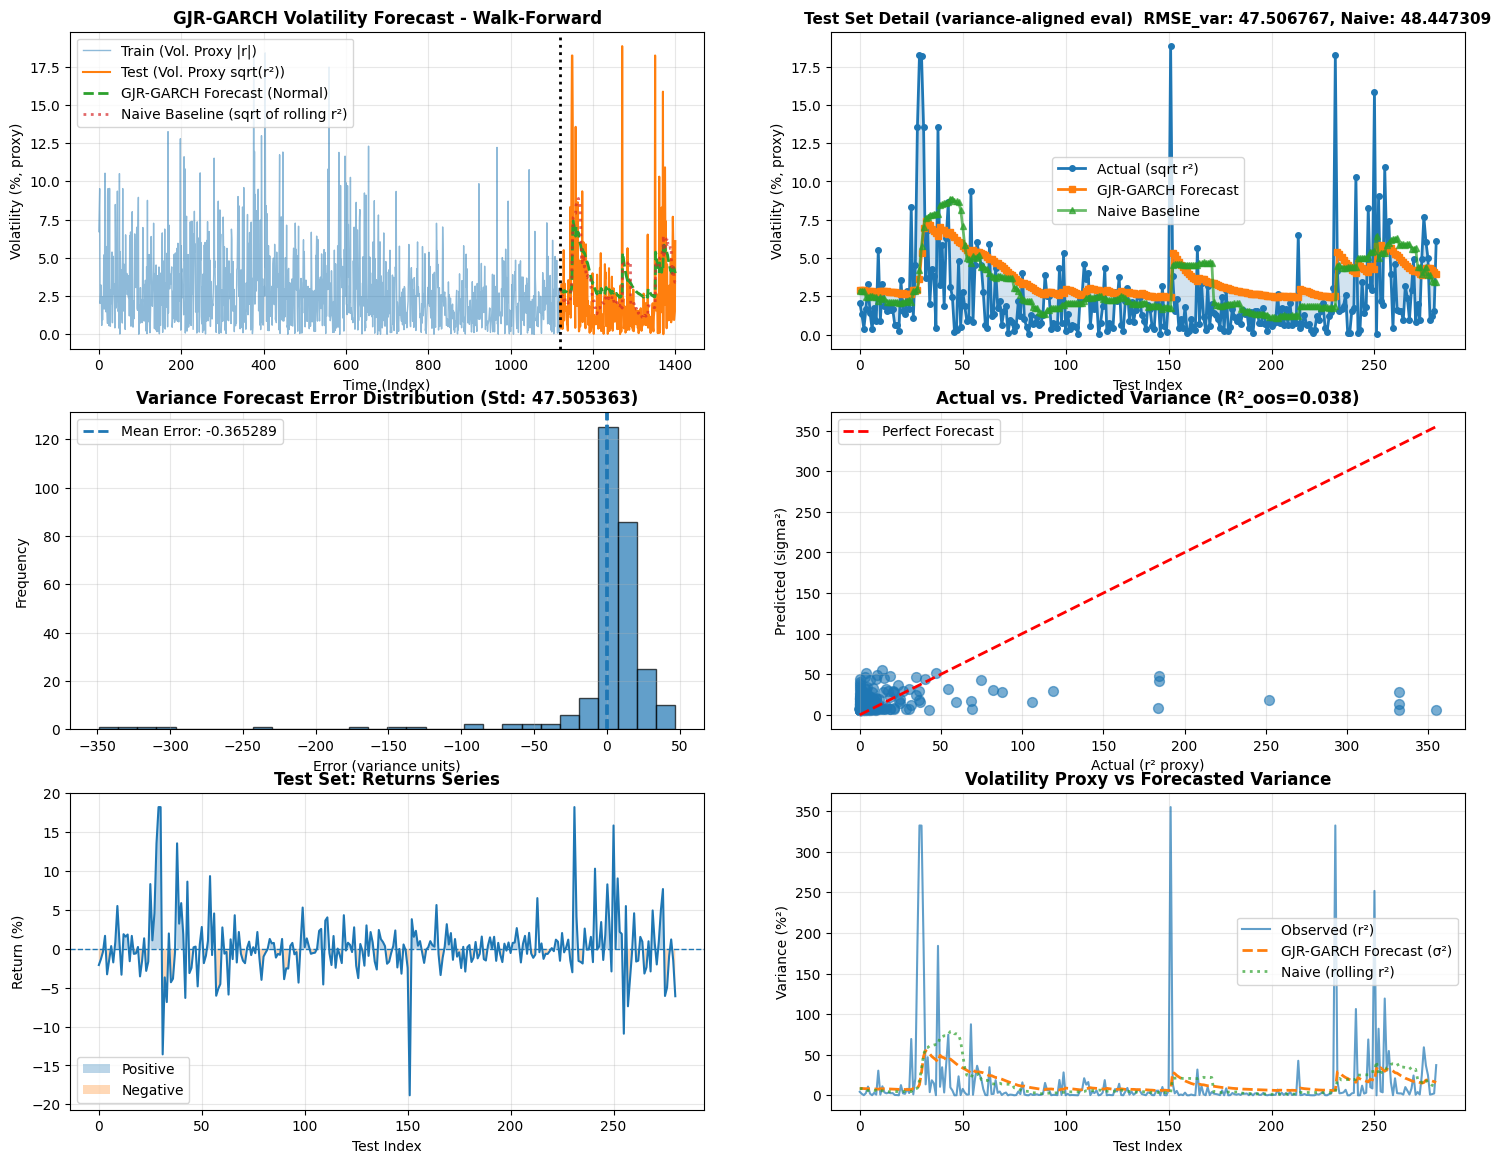


📋 SUMMARY REPORT - ETH 1D GJR-GARCH(1,1,1) - Normal Distribution

📁 DATA:
    • Total observations: 1401
    • Test period: 281 candles (~281 days)
    • Mean return: 0.0619%
    • Return std (unconditional): 3.8496%
    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)

🔧 MODEL:
    • GJR-GARCH(1,1,1) - Normal Distribution
    • (Glosten-Jagannathan-Runkle GARCH)
    • Parameters (from final walk-forward model):
      - ω: 0.553540
      - α: 0.060785
      - γ (o): -0.025254  [Threshold parameter]
      - β: 0.912233
    ✓ No 'nu' parameter (Correct for Normal dist).

📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):
    GARCH Model:
    • RMSE (var): 47.506767
    • MAE  (var): 19.383275
    • MAPE (var): 140326.76%
    • QLIKE:      3.711179

    Naive Baseline:
    • RMSE (var): 48.447309
    • MAE  (var): 19.683864
    • QLIKE:      3.987336

    Comparison:
    • R² (Out-of-Sample, vs Naive): 0.0385
    • RMSE Improvement vs Naive: +1.9

In [ ]:
# MODEL: GJR-GARCH(1,1,1)
# DISTRIBUTION: Normal (Gaussian) Distribution

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ETH 1D GJR-GARCH(1,1,1) (Normal Dist) ANALYSIS - WALK-FORWARD VALIDATION")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA AND CALCULATE RETURNS
# ============================================================================
print("\n[1/7] Loading data and calculating returns...")

raw = np.load("stocks_500.npy", allow_pickle=True).item()
data = {}

for key, df in raw.items():
    stock = key.replace('.csv', '')
    data[stock] = df

frames = []

for stock, df in data.items():
    # 把 index（日期）变成一列
    df = df.reset_index().rename(columns={'index': 'timestamp'})
    # 将日期转换为 datetime，与 sample 完全一致
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    # 加入股票列
    df['stock'] = stock
    df = df.sort_values('timestamp').reset_index(drop=True)
    # Calculate log returns (in %)
    df['returns'] = np.log(df['close'] / df['close'].shift(1)) * 100
    df = df.dropna(subset=['returns'])  # Drop the first row (NaN)
    df['realized_var'] = df['returns'] ** 2

    frames.append(df)




df=frames[6] #选择想处理的股票

print(f"✓ Total observations: {len(df)}")
print(f"✓ Date range: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
print(f"✓ Price range: ${df['close'].min():.2f} → ${df['close'].max():.2f}")

# Return statistics
print(f"\n📊 Return Statistics:")
print(f"    Mean: {df['returns'].mean():.4f}%")
print(f"    Std Dev: {df['returns'].std():.4f}%")
print(f"    Min: {df['returns'].min():.4f}%")
print(f"    Max: {df['returns'].max():.4f}%")
print(f"    Skewness: {df['returns'].skew():.4f}")
print(f"    Kurtosis: {df['returns'].kurtosis():.4f}")

# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (80%-20%)
# ============================================================================
print("\n[2/7] Splitting data (80% train - 20% test)...")

returns_series = df['returns']
rv_series = df['realized_var']   #平方项
train_size = int(len(returns_series) * 0.8)

train_returns = returns_series.iloc[:train_size]
test_returns = returns_series.iloc[train_size:]

train_rv = rv_series.iloc[:train_size]  #平方项
test_rv  = rv_series.iloc[train_size:] 

# Rolling window size (used for naive baseline)
vol_window = 20  

print(f"✓ Training set: {train_size} observations")
print(f"✓ Test set: {len(test_returns)} observations")
print(f"✓ Test period: {df['timestamp'].iloc[train_size]} → {df['timestamp'].iloc[-1]}")

# ============================================================================
# STEP 3: TRAIN BASELINE GJR-GARCH(1,1,1) - NORMAL DISTRIBUTION MODEL
# ============================================================================
print("\n[3/7] Training baseline GJR-GARCH(1,1,1) - Normal distribution model...")

# GJR-GARCH: vol='GARCH', p=1, o=1, q=1
baseline_model = arch_model(train_returns, vol='GARCH', p=1, o=1, q=1,
                            dist='normal', 
                            rescale=False)
baseline_fitted = baseline_model.fit(disp='off')
params = baseline_fitted.params

print(f"\n📊 GJR-GARCH(1,1,1) - Normal Distribution (Baseline Model):")
print(f"    (Glosten-Jagannathan-Runkle GARCH - Threshold Model)")
print(f"\n    Available Parameters: {list(params.index)}")

print(f"\n    Model Parameters:")
print(f"    ω (omega): {params.get('omega', 'N/A'):.6f}")

alpha = params.get('alpha[1]', 0)
print(f"    α (alpha): {alpha:.6f}")

# GJR-GARCH 'o' parameter (threshold/gamma)
gamma = params.get('o[1]', params.get('gamma[1]', 0)) # Check for o[1] or gamma[1]
print(f"    γ (gamma/o): {gamma:.6f}  [Threshold parameter]")

beta = params.get('beta[1]', 0)
print(f"    β (beta):  {beta:.6f}")

# 'nu' parameter CHECK (MANTIKSAL HATA DÜZELTİLDİ)
if 'nu' in params.index:
    print(f"    ⚠️ WARNING: 'nu' parameter found, which is inconsistent with dist='normal'.")
else:
    print(f"    ✓ No 'nu' parameter found (Correct for Normal dist).")


# GJR-GARCH stationarity: α + γ/2 + β < 1
persistence = alpha + (gamma / 2.0) + beta
print(f"\n    Volatility Persistence (α + γ/2 + β): {persistence:.6f}")

if persistence < 1.0:
    print(f"    ✅ Model is stationary (Condition: {persistence:.4f} < 1)")
else:
    print(f"    ⚠️ Model is non-stationary (Condition: {persistence:.4f} ≥ 1)")

# Asymmetry analysis - GJR-GARCH expects gamma > 0
print(f"\n    📊 Asymmetry Analysis (Leverage Effect):")
if gamma > 0.1:
    print(f"    📉 Strong leverage effect (γ={gamma:.4f})")
    print(f"    → Negative shocks increase volatility significantly more.")
    neg_effect = alpha + gamma
    pos_effect = alpha
    ratio = neg_effect / pos_effect if pos_effect > 1e-6 else 1
    print(f"    → Negative shock impact (α+γ) = {neg_effect:.4f}")
    print(f"    → Positive shock impact (α)   = {pos_effect:.4f} (Ratio: {ratio:.2f}x)")
elif gamma > 0:
    print(f"    ✓ Leverage effect present (γ={gamma:.4f})")
    print(f"    → Negative shocks are more impactful.")
else:
    print(f"    ⚖️ No leverage effect (γ={gamma:.4f} <= 0). (Model behaves like standard GARCH)")


# ============================================================================
# STEP 4: WALK-FORWARD VALIDATION
# ============================================================================
print("\n[4/7] Starting walk-forward validation...")
print("      (GARCH model will be refit at each step)")

# Store predictions
predictions_var = []
actual_var = []
naive_var = []
final_fitted_model = None

# For each test point
for i in range(len(test_returns)):
    # Current training data (train + test up to this point)
    if i > 0:
        history = np.concatenate([train_returns, test_returns[:i]])
        rv_history = np.concatenate([train_rv, actual_var[:i]])
    else:
        history = train_returns
        rv_history = train_rv
    
    try:
        # Train GJR-GARCH(1,1,1) - Normal distribution
        model = arch_model(history, vol='GARCH', p=1, o=1, q=1,
                           dist='normal', 
                           rescale=False)
        fitted = model.fit(disp='off')
        final_fitted_model = fitted 
        
        # 1-step ahead volatility forecast
        forecast = fitted.forecast(horizon=1, reindex=False)
        predicted_variance = float(forecast.variance.values[-1, 0])
        predictions_var.append(predicted_variance)

        
        # ACTUAL VOLATILITY: Simple proxy (absolute return)
        actual_var.append(float(test_rv.iloc[i]))

        
        # NAIVE FORECAST: Mean of all actual volatility seen so far
        window = rv_history[-vol_window:]# 过去 vol_window 个 realized_var 的均值
        naive_pred = float(np.mean(window))
        naive_var.append(naive_pred)

        
    except Exception as e:
        print(f"    ⚠️ Error at step {i+1}: {str(e)[:50]}")
        # In case of error, use the last known volatility
        if len(predictions_var) > 0:
            predictions_var.append(predictions_var[-1])
        else:
            # For the very first prediction, use train volatility
            predictions_var.append(np.mean(np.abs(train_returns[-vol_window:])))
        
        actual_var.append(abs(test_returns[i])**2)
        
        if i > 0:
            naive_var.append(np.mean(actual_var[:i]))
        else:
            naive_var.append(np.mean(np.abs(train_returns[-vol_window:])))
    
    # Show progress
    if (i + 1) % 10 == 0 or i == len(test_returns) - 1:
        print(f"    Progress: {i+1}/{len(test_returns)} completed")

predictions_var = np.array(predictions_var)
actual_var = np.array(actual_var)
naive_var = np.array(naive_var)

# ============================================================================
# STEP 5: PERFORMANCE METRICS  (Variance-level, aligned with GARCH)
# ============================================================================
print("\n[5/7] Calculating performance metrics...")

# Ensure numpy arrays
actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Safety: avoid zeros in denominators / logs
eps = 1e-12
pred_var_safe = np.maximum(predictions_var, eps)
naive_var_safe = np.maximum(naive_var, eps)

# --------------------
# Metrics on variance
# --------------------
rmse_var = np.sqrt(mean_squared_error(actual_var, predictions_var))
mae_var = mean_absolute_error(actual_var, predictions_var)
mape_var = np.mean(np.abs((actual_var - predictions_var) / (actual_var + eps))) * 100

# QLIKE (standard for variance forecasting)
qlike_garch = np.mean(actual_var / pred_var_safe + np.log(pred_var_safe))
qlike_naive = np.mean(actual_var / naive_var_safe + np.log(naive_var_safe))

# Out-of-sample R² relative to naive baseline (Campbell-Thompson style)
ss_res = np.sum((actual_var - predictions_var) ** 2)
ss_tot = np.sum((actual_var - naive_var) ** 2)
r2_oos = 1 - (ss_res / ss_tot)

# Naive model performance (variance)
naive_rmse_var = np.sqrt(mean_squared_error(actual_var, naive_var))
naive_mae_var = mean_absolute_error(actual_var, naive_var)

print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target: r^2 proxy):")
print(f"    GARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline (Rolling Mean of r^2):")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):.2f}%")

# --------------------
# Descriptive stats
# --------------------
print(f"\n📊 Variance Statistics (Test Set):")
print(f"    Actual variance proxy (r^2):")
print(f"    • Mean: {np.mean(actual_var):.6f}")
print(f"    • Std:  {np.std(actual_var):.6f}")
print(f"    • Min:  {np.min(actual_var):.6f}")
print(f"    • Max:  {np.max(actual_var):.6f}")

print(f"\n    GARCH predicted variance (sigma^2):")
print(f"    • Mean: {np.mean(predictions_var):.6f}")
print(f"    • Std:  {np.std(predictions_var):.6f}")

print(f"\n    Naive predicted variance:")
print(f"    • Mean: {np.mean(naive_var):.6f}")
print(f"    • Std:  {np.std(naive_var):.6f}")

# Optional: also report volatility-level (std) for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol = np.sqrt(np.maximum(predictions_var, 0))
naive_vol = np.sqrt(np.maximum(naive_var, 0))

print(f"\n📌 (Optional) Volatility-level summary (sqrt of variance):")
print(f"    Actual vol proxy:")
print(f"    • Mean: {np.mean(actual_vol):.6f}")
print(f"    • Std:  {np.std(actual_vol):.6f}")
print(f"    GARCH predicted vol:")
print(f"    • Mean: {np.mean(pred_vol):.6f}")
print(f"    • Std:  {np.std(pred_vol):.6f}")
print(f"    Naive predicted vol:")
print(f"    • Mean: {np.mean(naive_vol):.6f}")
print(f"    • Std:  {np.std(naive_vol):.6f}")

# ============================================================================
# STEP 6: VISUALIZATION (aligned)
# ============================================================================
print("\n[6/7] Generating plots...")

# Ensure numpy
train_returns_np = np.asarray(train_returns, dtype=float)  # Series/ndarray都可
test_returns_np  = np.asarray(test_returns, dtype=float)

actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Convert variance -> volatility for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol   = np.sqrt(np.maximum(predictions_var, 0))
naive_vol  = np.sqrt(np.maximum(naive_var, 0))

# A consistent "train volatility proxy" for the full-series plot
train_vol_proxy = np.sqrt(np.maximum((train_returns_np**2), 0))  # = abs(train_returns)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# 1. Full series: volatility proxy + forecasts on test
train_x = np.arange(len(train_vol_proxy))
test_x = np.arange(len(train_vol_proxy), len(train_vol_proxy) + len(actual_vol))

axes[0, 0].plot(train_x, train_vol_proxy, label='Train (Vol. Proxy |r|)',
                alpha=0.5, linewidth=1)
axes[0, 0].plot(test_x, actual_vol, label='Test (Vol. Proxy sqrt(r²))',
                linewidth=1.5)
axes[0, 0].plot(test_x, pred_vol, label='GJR-GARCH Forecast (Normal)',
                linestyle='--', linewidth=2)
axes[0, 0].plot(test_x, naive_vol, label='Naive Baseline (sqrt of rolling r²)',
                linestyle=':', linewidth=2, alpha=0.7)
axes[0, 0].axvline(x=len(train_vol_proxy), color='black', linestyle=':', linewidth=2)
axes[0, 0].set_title('GJR-GARCH Volatility Forecast - Walk-Forward', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Time (Index)')
axes[0, 0].set_ylabel('Volatility (%, proxy)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Test detail (volatility scale)
axes[0, 1].plot(actual_vol, label='Actual (sqrt r²)',
                linewidth=2, marker='o', markersize=4)
axes[0, 1].plot(pred_vol, label='GJR-GARCH Forecast',
                linewidth=2, marker='s', markersize=4)
axes[0, 1].plot(naive_vol, label='Naive Baseline',
                linewidth=2, marker='^', markersize=4, alpha=0.7)
axes[0, 1].fill_between(range(len(actual_vol)), actual_vol, pred_vol, alpha=0.2)
axes[0, 1].set_title(
    f'Test Set Detail (variance-aligned eval)  RMSE_var: {rmse_var:.6f}, Naive: {naive_rmse_var:.6f}',
    fontweight='bold', fontsize=11
)
axes[0, 1].set_xlabel('Test Index')
axes[0, 1].set_ylabel('Volatility (%, proxy)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Error distribution (variance level is more principled)
errors_var = predictions_var - actual_var 
axes[1, 0].hist(errors_var, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, linestyle='--', linewidth=2)
axes[1, 0].axvline(x=np.mean(errors_var), linestyle='--', linewidth=2,
                   label=f'Mean Error: {np.mean(errors_var):.6f}')
axes[1, 0].set_title(f'Variance Forecast Error Distribution (Std: {np.std(errors_var):.6f})',
                     fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Error (variance units)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter plot (variance)
axes[1, 1].scatter(actual_var, predictions_var, alpha=0.6, s=50)
minv = min(actual_var.min(), predictions_var.min())
maxv = max(actual_var.max(), predictions_var.max())
axes[1, 1].plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Perfect Forecast')
axes[1, 1].set_title(f'Actual vs. Predicted Variance (R²_oos={r2_oos:.3f})',
                     fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Actual (r² proxy)')
axes[1, 1].set_ylabel('Predicted (sigma²)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Returns time series
test_x_returns = np.arange(len(test_returns_np))
axes[2, 0].plot(test_x_returns, test_returns_np, linewidth=1.5)
axes[2, 0].axhline(y=0, linestyle='--', linewidth=1)
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np > 0), alpha=0.3, label='Positive')
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np <= 0), alpha=0.3, label='Negative')
axes[2, 0].set_title('Test Set: Returns Series', fontweight='bold', fontsize=12)
axes[2, 0].set_xlabel('Test Index')
axes[2, 0].set_ylabel('Return (%)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Volatility clustering (variance view)
squared_returns = test_returns_np ** 2
axes[2, 1].plot(squared_returns, linewidth=1.5, alpha=0.7, label='Observed (r²)')
axes[2, 1].plot(predictions_var, linewidth=2, linestyle='--', label='GJR-GARCH Forecast (σ²)')
axes[2, 1].plot(naive_var, linewidth=2, linestyle=':', alpha=0.7, label='Naive (rolling r²)')
axes[2, 1].set_title('Volatility Proxy vs Forecasted Variance', fontweight='bold', fontsize=12)
axes[2, 1].set_xlabel('Test Index')
axes[2, 1].set_ylabel('Variance (%²)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout
plt.savefig('gjrgarch_normal_dist_1d_walkforward_analysis_ETH.png', dpi=300, bbox_inches='tight') 
print("✓ Plot saved: gjrgarch_normal_dist_1d_walkforward_analysis_ETH.png")
plt.show()

# ============================================================================
# STEP 7: SUMMARY REPORT (Variance-aligned)
# ============================================================================
print("\n" + "="*80)
print("📋 SUMMARY REPORT - ETH 1D GJR-GARCH(1,1,1) - Normal Distribution") 
print("="*80)

print(f"\n📁 DATA:")
print(f"    • Total observations: {len(df)}")
print(f"    • Test period: {len(test_returns)} candles (~{len(test_returns)} days)")
print(f"    • Mean return: {df['returns'].mean():.4f}%")
print(f"    • Return std (unconditional): {df['returns'].std():.4f}%")
print(f"    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)")

print(f"\n🔧 MODEL:")
print(f"    • GJR-GARCH(1,1,1) - Normal Distribution") 
print(f"    • (Glosten-Jagannathan-Runkle GARCH)")

# Parameters
if final_fitted_model:
    params = final_fitted_model.params
    print(f"    • Parameters (from final walk-forward model):")
else:
    params = baseline_fitted.params
    print(f"    • Parameters (from baseline model - WARNING: loop might have failed):")


alpha_val = params.get('alpha[1]', 0)
beta_val = params.get('beta[1]', 0)
gamma_val = params.get('o[1]', params.get('gamma[1]', 0)) # Get o[1] or gamma[1]

print(f"      - ω: {params.get('omega', 'N/A'):.6f}")
print(f"      - α: {alpha_val:.6f}")
print(f"      - γ (o): {gamma_val:.6f}  [Threshold parameter]")
print(f"      - β: {beta_val:.6f}")


if 'nu' in params.index:
    print(f"    ⚠️ WARNING: 'nu' parameter found, inconsistent with 'dist=normal'.")
else:
    print(f"    ✓ No 'nu' parameter (Correct for Normal dist).")



# Metrics (variance-level)
print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):")
print(f"    GARCH Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline:")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):+.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):+.2f}%")

print(f"\n💡 EVALUATION:")

# RMSE evaluation (variance-level)
rmse_improvement = ((naive_rmse_var - rmse_var) / naive_rmse_var * 100)
if rmse_improvement > 10:
    print(f"    ✅  GJR-GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (substantial)")
elif rmse_improvement > 5:
    print(f"    ✓  GJR-GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (moderate)")
elif rmse_improvement > 0:
    print(f"    ⚠️  GJR-GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (slight)")
else:
    print(f"    ❌  GJR-GARCH worsens RMSE by {abs(rmse_improvement):.1f}% vs naive")

# R²_oos evaluation (variance-level)
if r2_oos > 0.3:
    print(f"    ✅ R²_oos={r2_oos:.3f} - substantially better than naive")
elif r2_oos > 0.1:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - moderately better than naive")
elif r2_oos > 0:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - only slightly better than naive")
else:
    print(f"    ❌ R²_oos={r2_oos:.3f} - worse than naive")


# Asymmetry (Leverage Effect) - Gamma
print(f"\n    • Asymmetry (Leverage Effect):")
if gamma_val > 0.1:
    print(f"    • 📉 Strong leverage effect (γ={gamma_val:.4f}) - Negative shocks are dominant.")
    neg_effect = alpha_val + gamma_val
    pos_effect = alpha_val
    ratio = neg_effect / pos_effect if pos_effect > 1e-6 else 1
    print(f"    → Neg/Pos shock impact ratio: {ratio:.2f}x")
elif gamma_val > 0:
    print(f"    • ✓ Leverage effect present (γ={gamma_val:.4f}) - Negative shocks are more impactful.")
else:
    print(f"    • ⚖️ No leverage effect (γ={gamma_val:.4f} <= 0). (Model behaves like standard GARCH)")



# Volatility Persistence
persistence = alpha_val + (gamma_val / 2.0) + beta_val
print(f"    • Volatility Persistence (α + γ/2 + β = {persistence:.4f}):")
if persistence > 0.95:
    print("    • ⚠️ High persistence - shocks have a very long-lasting effect")
else:
    print("    • ✓ Moderate persistence - shocks decay gradually")




# Note on distribution
print(f"    • Distribution Note:")
print(f"    • Model used 'normal' dist. Given Kurtosis is {df['returns'].kurtosis():.2f}, 't' or 'skewt' dist may be better.")


print(f"\n📈 VOLATILITY CLUSTERING:")
squared_returns = test_returns ** 2
acorr_sq_returns = np.corrcoef(squared_returns[:-1], squared_returns[1:])[0, 1]
print(f"    • Squared returns autocorrelation: {acorr_sq_returns:.4f}")
if acorr_sq_returns > 0.1:
    print("    ✅ Volatility clustering is present (GJR-GARCH is appropriate)")
else:
    print("    ⚠️ Weak volatility clustering")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

print("\n💡 GJR-GARCH ADVANTAGES:")
print("    • ✅ Models asymmetric shocks (leverage effect via 'γ' parameter)")
print("    • ✅ Simpler and often more stable than EGARCH")
print("    • ✅ Easy to interpret: (α) for good news, (α+γ) for bad news")
print("    • ❌ This model used 'normal' dist, which may not capture 'fat tails'.")


print("\n💡 NEXT STEPS:")
print("    • Compare this model's R²/RMSE against the GARCH and EGARCH models")
print("    • Re-run this GJR-GARCH model with 'dist=t' or 'dist=skewt' (likely better)")
print("    • Calculate Value at Risk (VaR)")

ETH 1D GJR-GARCH(1,1,1) (Student's t-Dist) ANALYSIS - WALK-FORWARD VALIDATION

[1/7] Loading data and calculating returns...
✓ Total observations: 1401
✓ Date range: 2020-01-03 00:00:00 → 2025-10-17 00:00:00
✓ Price range: $40.64 → $197.02

📊 Return Statistics:
    Mean: 0.0619%
    Std Dev: 3.8496%
    Min: -18.8403%
    Max: 18.2346%
    Skewness: 0.4159
    Kurtosis: 3.0958

[2/7] Splitting data (80% train - 20% test)...
✓ Training set: 1120 observations
✓ Test set: 281 observations
✓ Test period: 2024-08-16 00:00:00 → 2025-10-17 00:00:00

[3/7] Training baseline GJR-GARCH(1,1,1) - Student's t-distribution model...

📊 GJR-GARCH(1,1,1) - Student's t-Distribution (Baseline Model):
    (Glosten-Jagannathan-Runkle GARCH - Threshold Model)

    Available Parameters: ['mu', 'omega', 'alpha[1]', 'gamma[1]', 'beta[1]', 'nu']

    Model Parameters:
    ω (omega): 0.018455
    α (alpha): 0.019536
    γ (gamma/o): -0.004835  [Threshold parameter]
    β (beta):  0.980352

    📊 Distribution Sha

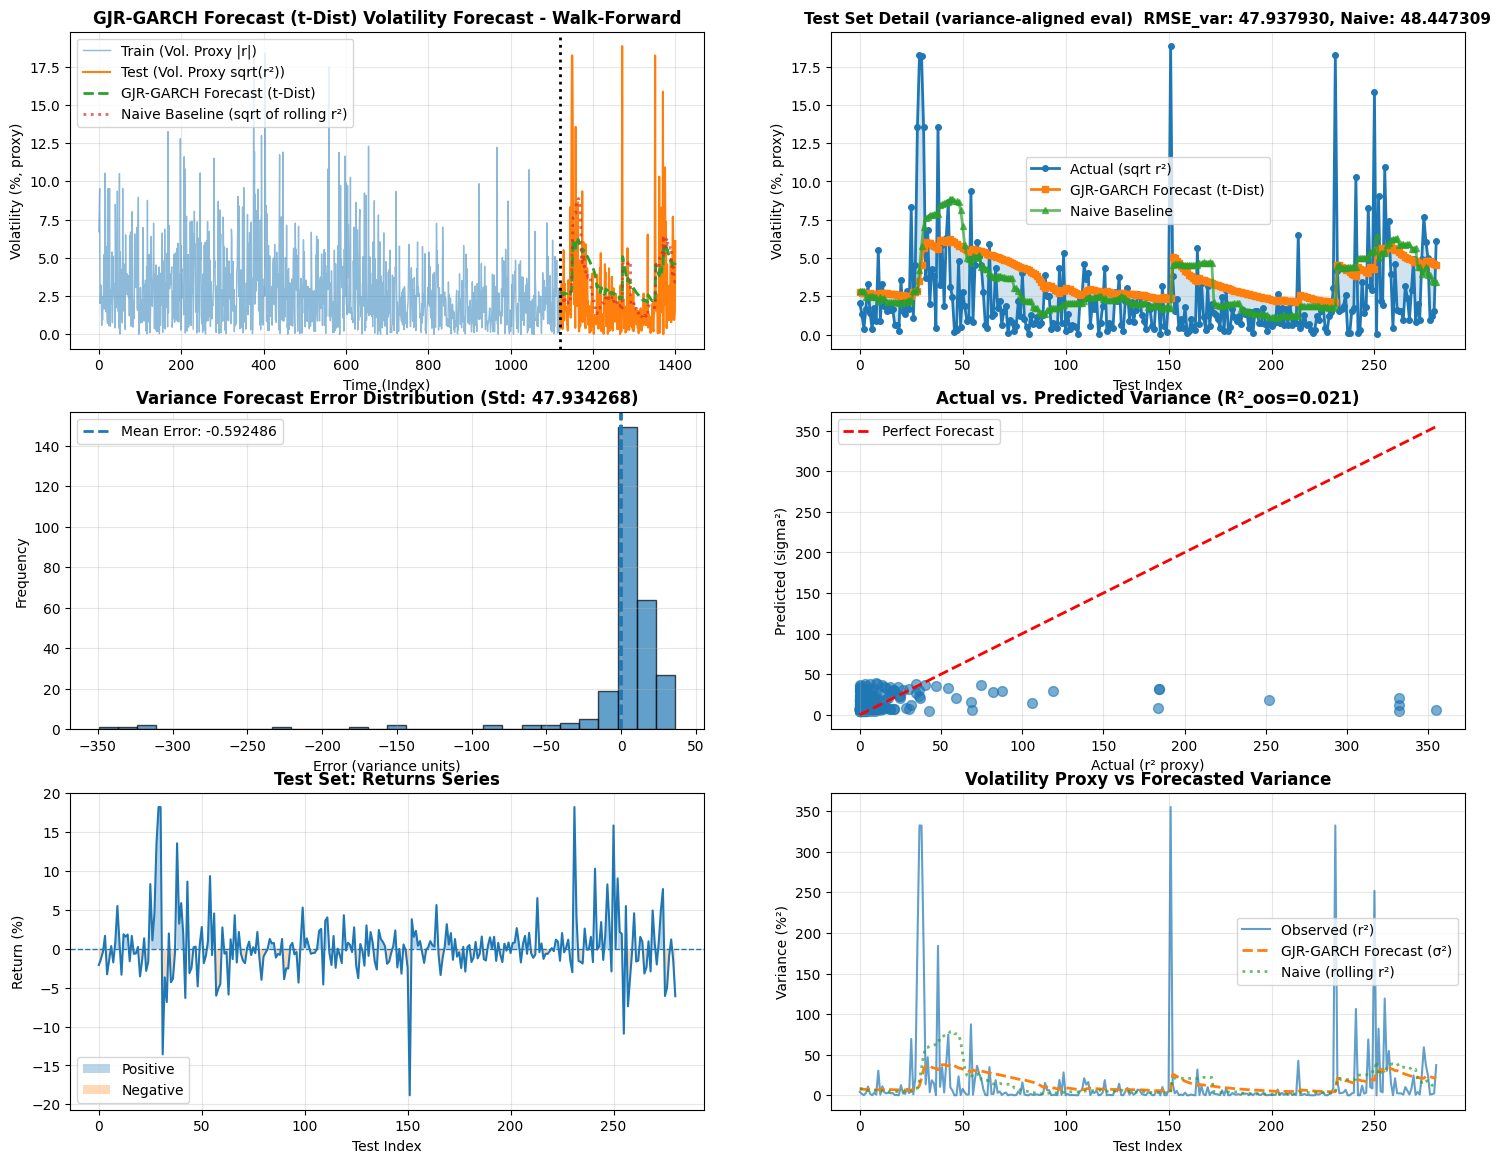


📋 SUMMARY REPORT - ETH 1D GJR-GARCH(1,1,1) - Student's t-Distribution

📁 DATA:
    • Total observations: 1401
    • Test period: 281 candles (~281 days)
    • Mean return: 0.0619%
    • Return std (unconditional): 3.8496%
    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)

🔧 MODEL:
    • GJR-GARCH(1,1,1) - Student's t-Distribution
    • (Glosten-Jagannathan-Runkle GARCH)
    • Parameters (from final walk-forward model):
      - ω: 0.077195
      - α: 0.044253
      - γ (o): -0.021386  [Threshold parameter]
      - β: 0.960573
      - ν: 4.571549  [Degrees of Freedom]

    • Validation: Walk-Forward (no data leakage)
    • Baseline: Rolling mean of abs(returns)

📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):
    GJR-GARCH (t-Dist) Model:
    • RMSE (var): 47.937930
    • MAE  (var): 19.365399
    • MAPE (var): 131323.96%
    • QLIKE:      3.843994

    Naive Baseline:
    • RMSE (var): 48.447309
    • MAE  (var): 19.683864
    • QLIKE:   

In [ ]:
# MODEL: GJR-GARCH(1,1,1) (Threshold GARCH)
# DISTRIBUTION: Student's t-Distribution (dist='t')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ETH 1D GJR-GARCH(1,1,1) (Student's t-Dist) ANALYSIS - WALK-FORWARD VALIDATION")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA AND CALCULATE RETURNS
# ============================================================================
print("\n[1/7] Loading data and calculating returns...")

raw = np.load("stocks_500.npy", allow_pickle=True).item()
data = {}

for key, df in raw.items():
    stock = key.replace('.csv', '')
    data[stock] = df

frames = []

for stock, df in data.items():
    # 把 index（日期）变成一列
    df = df.reset_index().rename(columns={'index': 'timestamp'})
    # 将日期转换为 datetime，与 sample 完全一致
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    # 加入股票列
    df['stock'] = stock
    df = df.sort_values('timestamp').reset_index(drop=True)
    # Calculate log returns (in %)
    df['returns'] = np.log(df['close'] / df['close'].shift(1)) * 100
    df = df.dropna(subset=['returns'])  # Drop the first row (NaN)
    df['realized_var'] = df['returns'] ** 2

    frames.append(df)




df=frames[6] #选择想处理的股票

print(f"✓ Total observations: {len(df)}")
print(f"✓ Date range: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
print(f"✓ Price range: ${df['close'].min():.2f} → ${df['close'].max():.2f}")

# Return statistics
print(f"\n📊 Return Statistics:")
print(f"    Mean: {df['returns'].mean():.4f}%")
print(f"    Std Dev: {df['returns'].std():.4f}%")
print(f"    Min: {df['returns'].min():.4f}%")
print(f"    Max: {df['returns'].max():.4f}%")
print(f"    Skewness: {df['returns'].skew():.4f}")
print(f"    Kurtosis: {df['returns'].kurtosis():.4f}")

# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (80%-20%)
# ============================================================================
print("\n[2/7] Splitting data (80% train - 20% test)...")

returns_series = df['returns']
rv_series = df['realized_var']   #平方项
train_size = int(len(returns_series) * 0.8)

train_returns = returns_series.iloc[:train_size]
test_returns = returns_series.iloc[train_size:]

train_rv = rv_series.iloc[:train_size]  #平方项
test_rv  = rv_series.iloc[train_size:] 

# Rolling window size (used for naive baseline)
vol_window = 20  

print(f"✓ Training set: {train_size} observations")
print(f"✓ Test set: {len(test_returns)} observations")
print(f"✓ Test period: {df['timestamp'].iloc[train_size]} → {df['timestamp'].iloc[-1]}")

# ============================================================================
# STEP 3: TRAIN BASELINE GJR-GARCH(1,1,1) - STUDENT'S T-DISTRIBUTION MODEL
# ============================================================================
print("\n[3/7] Training baseline GJR-GARCH(1,1,1) - Student's t-distribution model...")

# GJR-GARCH: vol='GARCH', p=1, o=1, q=1
baseline_model = arch_model(train_returns, vol='GARCH', p=1, o=1, q=1,
                            dist='t',  # Student's t-Distribution
                            rescale=False)
baseline_fitted = baseline_model.fit(disp='off')
params = baseline_fitted.params

print(f"\n📊 GJR-GARCH(1,1,1) - Student's t-Distribution (Baseline Model):")
print(f"    (Glosten-Jagannathan-Runkle GARCH - Threshold Model)")
print(f"\n    Available Parameters: {list(params.index)}")

print(f"\n    Model Parameters:")
print(f"    ω (omega): {params.get('omega', 'N/A'):.6f}")

alpha = params.get('alpha[1]', 0)
print(f"    α (alpha): {alpha:.6f}")

gamma = params.get('o[1]', params.get('gamma[1]', 0)) # Threshold parameter
print(f"    γ (gamma/o): {gamma:.6f}  [Threshold parameter]")

beta = params.get('beta[1]', 0)
print(f"    β (beta):  {beta:.6f}")

# 'nu' parameter check (Should exist for t-dist)
print(f"\n    📊 Distribution Shape (Baseline):")
if 'nu' in params.index:
    nu = params['nu']
    print(f"    ν (nu): {nu:.6f}  [Degrees of Freedom for t-Dist]")
    if nu < 5:
        print(f"    → Very fat tails (ν={nu:.2f}). Extreme events are frequent.")
    elif nu < 10:
        print(f"    → Fat tails (ν={nu:.2f}). More extreme events than normal.")
    else:
        print(f"    → Moderately fat tails (ν={nu:.2f}).")
else:
    print(f"    ⚠️ WARNING: 'nu' parameter not found, inconsistent with dist='t'.")

# GJR-GARCH stationarity: α + γ/2 + β < 1
persistence = alpha + (gamma / 2.0) + beta
print(f"\n    Volatility Persistence (α + γ/2 + β): {persistence:.6f}")

if persistence < 1.0:
    print(f"    ✅ Model is stationary (Condition: {persistence:.4f} < 1)")
else:
    print(f"    ⚠️ Model is non-stationary (Condition: {persistence:.4f} ≥ 1)")

# Asymmetry analysis - GJR-GARCH expects gamma > 0
print(f"\n    📊 Asymmetry Analysis (Leverage Effect):")
if gamma > 0.1:
    print(f"    📉 Strong leverage effect (γ={gamma:.4f})")
    print(f"    → Negative shocks increase volatility significantly more.")
    neg_effect = alpha + gamma
    pos_effect = alpha
    ratio = neg_effect / pos_effect if pos_effect > 1e-6 else 1
    print(f"    → Negative shock impact (α+γ) = {neg_effect:.4f}")
    print(f"    → Positive shock impact (α)   = {pos_effect:.4f} (Ratio: {ratio:.2f}x)")
elif gamma > 0:
    print(f"    ✓ Leverage effect present (γ={gamma:.4f})")
    print(f"    → Negative shocks are more impactful.")
else:
    print(f"    ⚖️ No leverage effect (γ={gamma:.4f} <= 0). (Model behaves like standard GARCH)")


# ============================================================================
# STEP 4: WALK-FORWARD VALIDATION
# ============================================================================
print("\n[4/7] Starting walk-forward validation...")
print("      (GARCH model will be refit at each step)")

# Store predictions
predictions_var = []
actual_var = []
naive_var = []
final_fitted_model = None

# For each test point
for i in range(len(test_returns)):
    # Current training data (train + test up to this point)
    if i > 0:
        history = np.concatenate([train_returns, test_returns[:i]])
        rv_history = np.concatenate([train_rv, actual_var[:i]])
    else:
        history = train_returns
        rv_history = train_rv
    
    try:
        # Train GJR-GARCH(1,1,1) - Student's t-distribution
        model = arch_model(history, vol='GARCH', p=1, o=1, q=1,
                           dist='t',
                           rescale=False)
        fitted = model.fit(disp='off')
        final_fitted_model = fitted # Capture the last successfully fitted model
        
        
        # 1-step ahead volatility forecast
        forecast = fitted.forecast(horizon=1, reindex=False)
        predicted_variance = float(forecast.variance.values[-1, 0])
        predictions_var.append(predicted_variance)

        
        # ACTUAL VOLATILITY: Simple proxy (absolute return)
        actual_var.append(float(test_rv.iloc[i]))

        
        # NAIVE FORECAST: Mean of all actual volatility seen so far
        window = rv_history[-vol_window:]# 过去 vol_window 个 realized_var 的均值
        naive_pred = float(np.mean(window))
        naive_var.append(naive_pred)

        
    except Exception as e:
        print(f"    ⚠️ Error at step {i+1}: {str(e)[:50]}")
        # In case of error, use the last known volatility
        if len(predictions_var) > 0:
            predictions_var.append(predictions_var[-1])
        else:
            # For the very first prediction, use train volatility
            predictions_var.append(np.mean(np.abs(train_returns[-vol_window:])))
        
        actual_var.append(abs(test_returns[i])**2)
        
        if i > 0:
            naive_var.append(np.mean(actual_var[:i]))
        else:
            naive_var.append(np.mean(np.abs(train_returns[-vol_window:])))
    
    # Show progress
    if (i + 1) % 10 == 0 or i == len(test_returns) - 1:
        print(f"    Progress: {i+1}/{len(test_returns)} completed")

predictions_var = np.array(predictions_var)
actual_var = np.array(actual_var)
naive_var = np.array(naive_var)

# ============================================================================
# STEP 5: PERFORMANCE METRICS  (Variance-level, aligned with GARCH)
# ============================================================================
print("\n[5/7] Calculating performance metrics...")

# Ensure numpy arrays
actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Safety: avoid zeros in denominators / logs
eps = 1e-12
pred_var_safe = np.maximum(predictions_var, eps)
naive_var_safe = np.maximum(naive_var, eps)

# --------------------
# Metrics on variance
# --------------------
rmse_var = np.sqrt(mean_squared_error(actual_var, predictions_var))
mae_var = mean_absolute_error(actual_var, predictions_var)
mape_var = np.mean(np.abs((actual_var - predictions_var) / (actual_var + eps))) * 100

# QLIKE (standard for variance forecasting)
qlike_garch = np.mean(actual_var / pred_var_safe + np.log(pred_var_safe))
qlike_naive = np.mean(actual_var / naive_var_safe + np.log(naive_var_safe))

# Out-of-sample R² relative to naive baseline (Campbell-Thompson style)
ss_res = np.sum((actual_var - predictions_var) ** 2)
ss_tot = np.sum((actual_var - naive_var) ** 2)
r2_oos = 1 - (ss_res / ss_tot)

# Naive model performance (variance)
naive_rmse_var = np.sqrt(mean_squared_error(actual_var, naive_var))
naive_mae_var = mean_absolute_error(actual_var, naive_var)

print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target: r^2 proxy):")
print(f"    GJR-GARCH (t-Dist) Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline (Rolling Mean of r^2):")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):.2f}%")

# --------------------
# Descriptive stats
# --------------------
print(f"\n📊 Variance Statistics (Test Set):")
print(f"    Actual variance proxy (r^2):")
print(f"    • Mean: {np.mean(actual_var):.6f}")
print(f"    • Std:  {np.std(actual_var):.6f}")
print(f"    • Min:  {np.min(actual_var):.6f}")
print(f"    • Max:  {np.max(actual_var):.6f}")

print(f"\n    GJR-GARCH (t-Dist) predicted variance (sigma^2):")
print(f"    • Mean: {np.mean(predictions_var):.6f}")
print(f"    • Std:  {np.std(predictions_var):.6f}")

print(f"\n    Naive predicted variance:")
print(f"    • Mean: {np.mean(naive_var):.6f}")
print(f"    • Std:  {np.std(naive_var):.6f}")

# Optional: also report volatility-level (std) for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol = np.sqrt(np.maximum(predictions_var, 0))
naive_vol = np.sqrt(np.maximum(naive_var, 0))

print(f"\n📌 (Optional) Volatility-level summary (sqrt of variance):")
print(f"    Actual vol proxy:")
print(f"    • Mean: {np.mean(actual_vol):.6f}")
print(f"    • Std:  {np.std(actual_vol):.6f}")
print(f"    GARCH predicted vol:")
print(f"    • Mean: {np.mean(pred_vol):.6f}")
print(f"    • Std:  {np.std(pred_vol):.6f}")
print(f"    Naive predicted vol:")
print(f"    • Mean: {np.mean(naive_vol):.6f}")
print(f"    • Std:  {np.std(naive_vol):.6f}")

# ============================================================================
# STEP 6: VISUALIZATION (aligned)
# ============================================================================
print("\n[6/7] Generating plots...")

# Ensure numpy
train_returns_np = np.asarray(train_returns, dtype=float)  # Series/ndarray都可
test_returns_np  = np.asarray(test_returns, dtype=float)

actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Convert variance -> volatility for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol   = np.sqrt(np.maximum(predictions_var, 0))
naive_vol  = np.sqrt(np.maximum(naive_var, 0))

# A consistent "train volatility proxy" for the full-series plot
train_vol_proxy = np.sqrt(np.maximum((train_returns_np**2), 0))  # = abs(train_returns)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# 1. Full series: volatility proxy + forecasts on test
train_x = np.arange(len(train_vol_proxy))
test_x = np.arange(len(train_vol_proxy), len(train_vol_proxy) + len(actual_vol))

axes[0, 0].plot(train_x, train_vol_proxy, label='Train (Vol. Proxy |r|)',
                alpha=0.5, linewidth=1)
axes[0, 0].plot(test_x, actual_vol, label='Test (Vol. Proxy sqrt(r²))',
                linewidth=1.5)
axes[0, 0].plot(test_x, pred_vol, label='GJR-GARCH Forecast (t-Dist)',
                linestyle='--', linewidth=2)
axes[0, 0].plot(test_x, naive_vol, label='Naive Baseline (sqrt of rolling r²)',
                linestyle=':', linewidth=2, alpha=0.7)
axes[0, 0].axvline(x=len(train_vol_proxy), color='black', linestyle=':', linewidth=2)
axes[0, 0].set_title('GJR-GARCH Forecast (t-Dist) Volatility Forecast - Walk-Forward', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Time (Index)')
axes[0, 0].set_ylabel('Volatility (%, proxy)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Test detail (volatility scale)
axes[0, 1].plot(actual_vol, label='Actual (sqrt r²)',
                linewidth=2, marker='o', markersize=4)
axes[0, 1].plot(pred_vol, label='GJR-GARCH Forecast (t-Dist)',
                linewidth=2, marker='s', markersize=4)
axes[0, 1].plot(naive_vol, label='Naive Baseline',
                linewidth=2, marker='^', markersize=4, alpha=0.7)
axes[0, 1].fill_between(range(len(actual_vol)), actual_vol, pred_vol, alpha=0.2)
axes[0, 1].set_title(
    f'Test Set Detail (variance-aligned eval)  RMSE_var: {rmse_var:.6f}, Naive: {naive_rmse_var:.6f}',
    fontweight='bold', fontsize=11
)
axes[0, 1].set_xlabel('Test Index')
axes[0, 1].set_ylabel('Volatility (%, proxy)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Error distribution (variance level is more principled)
errors_var = predictions_var - actual_var 
axes[1, 0].hist(errors_var, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, linestyle='--', linewidth=2)
axes[1, 0].axvline(x=np.mean(errors_var), linestyle='--', linewidth=2,
                   label=f'Mean Error: {np.mean(errors_var):.6f}')
axes[1, 0].set_title(f'Variance Forecast Error Distribution (Std: {np.std(errors_var):.6f})',
                     fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Error (variance units)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter plot (variance)
axes[1, 1].scatter(actual_var, predictions_var, alpha=0.6, s=50)
minv = min(actual_var.min(), predictions_var.min())
maxv = max(actual_var.max(), predictions_var.max())
axes[1, 1].plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Perfect Forecast')
axes[1, 1].set_title(f'Actual vs. Predicted Variance (R²_oos={r2_oos:.3f})',
                     fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Actual (r² proxy)')
axes[1, 1].set_ylabel('Predicted (sigma²)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Returns time series
test_x_returns = np.arange(len(test_returns_np))
axes[2, 0].plot(test_x_returns, test_returns_np, linewidth=1.5)
axes[2, 0].axhline(y=0, linestyle='--', linewidth=1)
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np > 0), alpha=0.3, label='Positive')
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np <= 0), alpha=0.3, label='Negative')
axes[2, 0].set_title('Test Set: Returns Series', fontweight='bold', fontsize=12)
axes[2, 0].set_xlabel('Test Index')
axes[2, 0].set_ylabel('Return (%)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Volatility clustering (variance view)
squared_returns = test_returns_np ** 2
axes[2, 1].plot(squared_returns, linewidth=1.5, alpha=0.7, label='Observed (r²)')
axes[2, 1].plot(predictions_var, linewidth=2, linestyle='--', label='GJR-GARCH Forecast (σ²)')
axes[2, 1].plot(naive_var, linewidth=2, linestyle=':', alpha=0.7, label='Naive (rolling r²)')
axes[2, 1].set_title('Volatility Proxy vs Forecasted Variance', fontweight='bold', fontsize=12)
axes[2, 1].set_xlabel('Test Index')
axes[2, 1].set_ylabel('Variance (%²)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout
plt.savefig('gjrgarch_t_dist_1d_walkforward_analysis_ETH.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved: gjrgarch_t_dist_1d_walkforward_analysis_ETH.png")
plt.show()

# ============================================================================
# STEP 7: SUMMARY REPORT (Variance-aligned)
# ============================================================================
print("\n" + "="*80)
print("📋 SUMMARY REPORT - ETH 1D GJR-GARCH(1,1,1) - Student's t-Distribution")
print("="*80)

print(f"\n📁 DATA:")
print(f"    • Total observations: {len(df)}")
print(f"    • Test period: {len(test_returns)} candles (~{len(test_returns)} days)")
print(f"    • Mean return: {df['returns'].mean():.4f}%")
print(f"    • Return std (unconditional): {df['returns'].std():.4f}%")
print(f"    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)")

print(f"\n🔧 MODEL:")
print(f"    • GJR-GARCH(1,1,1) - Student's t-Distribution")
print(f"    • (Glosten-Jagannathan-Runkle GARCH)")


# Use parameters from the final model fitted during walk-forward
if final_fitted_model:
    params = final_fitted_model.params
    print(f"    • Parameters (from final walk-forward model):")
else:
    params = baseline_fitted.params # Fallback if loop failed
    print(f"    • Parameters (from baseline model - WARNING: loop might have failed):")



# Safely extract parameters
alpha_val = params.get('alpha[1]', 0)
beta_val = params.get('beta[1]', 0)
gamma_val = params.get('o[1]', params.get('gamma[1]', 0)) # Threshold param

print(f"      - ω: {params.get('omega', 'N/A'):.6f}")
print(f"      - α: {alpha_val:.6f}")
print(f"      - γ (o): {gamma_val:.6f}  [Threshold parameter]")
print(f"      - β: {beta_val:.6f}")

# 'nu' parameter check
if 'nu' in params.index:
    nu_val = params['nu']
    print(f"      - ν: {nu_val:.6f}  [Degrees of Freedom]")
else:
    nu_val = None # Set to None if not found
    print(f"    ⚠️ WARNING: 'nu' parameter not found, inconsistent with dist='t'.")

print(f"\n    • Validation: Walk-Forward (no data leakage)")
print(f"    • Baseline: Rolling mean of abs(returns)")

# Metrics (variance-level)
print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):")
print(f"    GJR-GARCH (t-Dist) Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline:")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):+.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):+.2f}%")

print(f"\n💡 EVALUATION:")

# RMSE evaluation (variance-level)
rmse_improvement = ((naive_rmse_var - rmse_var) / naive_rmse_var * 100)
if rmse_improvement > 10:
    print(f"    ✅ GJR-GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (substantial)")
elif rmse_improvement > 5:
    print(f"    ✓ GJR-GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (moderate)")
elif rmse_improvement > 0:
    print(f"    ⚠️ GJR-GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (slight)")
else:
    print(f"    ❌ GJR-GARCH worsens RMSE by {abs(rmse_improvement):.1f}% vs naive")

# R²_oos evaluation (variance-level)
if r2_oos > 0.3:
    print(f"    ✅ R²_oos={r2_oos:.3f} - substantially better than naive")
elif r2_oos > 0.1:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - moderately better than naive")
elif r2_oos > 0:
    print(f"    ⚠️ R²_oos={r2_oos:.3f} - only slightly better than naive")
else:
    print(f"    ❌ R²_oos={r2_oos:.3f} - worse than naive")

# Asymmetry (Leverage Effect) - Gamma
print(f"\n    • Asymmetry (Leverage Effect):")
if gamma_val > 0.1:
    print(f"    • 📉 Strong leverage effect (γ={gamma_val:.4f}) - Negative shocks are dominant.")
    neg_effect = alpha_val + gamma_val
    pos_effect = alpha_val
    ratio = neg_effect / pos_effect if pos_effect > 1e-6 else 1
    print(f"    → Neg/Pos shock impact ratio: {ratio:.2f}x")
elif gamma_val > 0:
    print(f"    • ✓ Leverage effect present (γ={gamma_val:.4f}) - Negative shocks are more impactful.")
else:
    print(f"    • ⚖️ No leverage effect (γ={gamma_val:.4f} <= 0). (Model behaves like standard GARCH)")

# Volatility Persistence
persistence = alpha_val + (gamma_val / 2.0) + beta_val
print(f"    • Volatility Persistence (α + γ/2 + β = {persistence:.4f}):")
if persistence > 0.95:
    print("    • ⚠️ High persistence - shocks have a very long-lasting effect")
else:
    print("    • ✓ Moderate persistence - shocks decay gradually")

# Distribution Shape - Nu (Tails)
print(f"    • Distribution Shape (Risk):")
if nu_val is not None:
    if nu_val < 5:
        print(f"    • ⚠️ Very high risk of extreme events (fat tails) (ν={nu_val:.2f})")
    elif nu_val < 10:
        print(f"    • ⚠️ High risk of extreme events (fat tails) (ν={nu_val:.2f})")
    else:
        print(f"    • ✅ Moderate risk of extreme events (ν={nu_val:.2f})")
else:
    print("    • ⚠️ 'nu' parameter (tails) could not be evaluated.")


print(f"\n📈 VOLATILITY CLUSTERING:")
squared_returns = test_returns ** 2
acorr_sq_returns = np.corrcoef(squared_returns[:-1], squared_returns[1:])[0, 1]
print(f"    • Squared returns autocorrelation: {acorr_sq_returns:.4f}")
if acorr_sq_returns > 0.1:
    print("    ✅ Volatility clustering is present (GJR-GARCH is appropriate)")
else:
    print("    ⚠️ Weak volatility clustering")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

print("\n💡 GJR-GARCH (t-Dist) ADVANTAGES:")
print("    • ✅ Models asymmetric shocks (leverage effect via 'γ' parameter)")
print("    • ✅ Models fat tails (high kurtosis via 'ν' parameter)")
print("    • ✅ Simpler and often more stable than EGARCH")
print("    • ✅ Easy to interpret: (α) for good news, (α+γ) for bad news")

print("\n💡 NEXT STEPS:")
print("    • Compare this model's R²/RMSE against all other models (GARCH, EGARCH, GJR-Normal)")
print("    • Try GJR-GARCH with 'dist=skewt' (to also capture skewness)")
print("    • Calculate Value at Risk (VaR) using the final t-distribution parameters")

ETH 1D GJR-GARCH(1,1,1) (Skewed t-Dist) ANALYSIS - WALK-FORWARD VALIDATION

[1/7] Loading data and calculating returns...
✓ Total observations: 1401
✓ Date range: 2020-01-03 00:00:00 → 2025-10-17 00:00:00
✓ Price range: $40.64 → $197.02

📊 Return Statistics:
    Mean: 0.0619%
    Std Dev: 3.8496%
    Min: -18.8403%
    Max: 18.2346%
    Skewness: 0.4159
    Kurtosis: 3.0958

[2/7] Splitting data (80% train - 20% test)...
✓ Training set: 1120 observations
✓ Test set: 281 observations
✓ Test period: 2024-08-16 00:00:00 → 2025-10-17 00:00:00

[3/7] Training baseline GJR-GARCH(1,1,1) - Skewed t-distribution model...

📊 GJR-GARCH(1,1,1) - Skewed t-Distribution (Baseline Model):
    (Glosten-Jagannathan-Runkle GARCH - Threshold Model)

    Available Parameters: ['mu', 'omega', 'alpha[1]', 'gamma[1]', 'beta[1]', 'eta', 'lambda']

    Model Parameters:
    ω (omega): 0.022667
    α (alpha): 0.019880
    γ (gamma/o): -0.006511  [Threshold parameter]
    β (beta):  0.980365

    📊 Distribution S

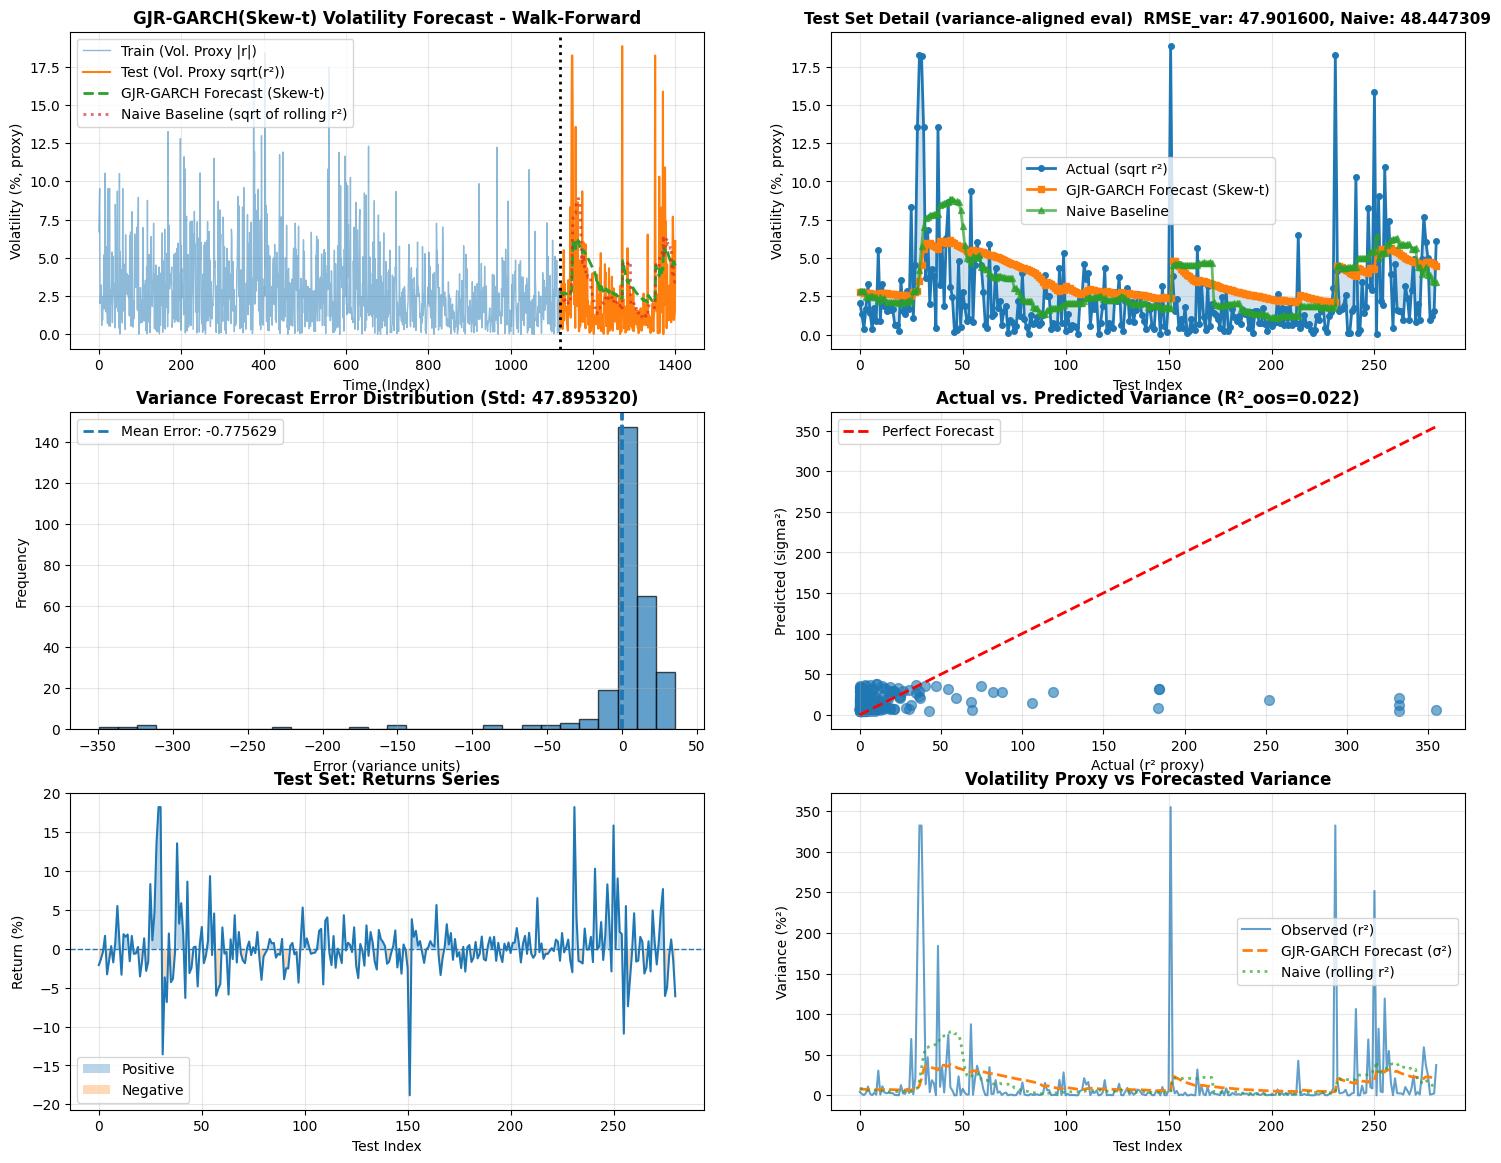


📋 SUMMARY REPORT - ETH 1D GJR-GARCH(1,1,1) - Skewed Student's t-Distribution

📁 DATA:
    • Total observations: 1401
    • Test period: 281 candles (~281 days)
    • Mean return: 0.0619%
    • Return std (unconditional): 3.8496%
    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)

🔧 MODEL:
    • GJR-GARCH(1,1,1) - Skewed Student's t-Distribution
    • (Glosten-Jagannathan-Runkle GARCH)
    • Parameters (from final walk-forward model):
      - ω: 0.080540
      - α: 0.042570
      - γ (o): -0.022989  [Threshold parameter]
      - β: 0.962312

    • Distribution Shape (Final Model):
    ⚠️ WARNING: 'nu' parameter not found, inconsistent with dist='skewt'.
      - λ: 0.110825  [Skewness Parameter]

    • Validation: Walk-Forward (no data leakage)
    • Baseline: Rolling mean of abs(returns)

📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):
    GJR-GARCH (Skew-t) Model:
    • RMSE (var): 47.901600
    • MAE  (var): 19.235899
    • MAPE (var): 1

In [ ]:
# MODEL: GJR-GARCH(1,1,1) (Threshold GARCH)
# DISTRIBUTION: Skewed Student's t-Distribution (dist='skewt')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ETH 1D GJR-GARCH(1,1,1) (Skewed t-Dist) ANALYSIS - WALK-FORWARD VALIDATION")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA AND CALCULATE RETURNS
# ============================================================================
print("\n[1/7] Loading data and calculating returns...")

raw = np.load("stocks_500.npy", allow_pickle=True).item()
data = {}

for key, df in raw.items():
    stock = key.replace('.csv', '')
    data[stock] = df

frames = []

for stock, df in data.items():
    # 把 index（日期）变成一列
    df = df.reset_index().rename(columns={'index': 'timestamp'})
    # 将日期转换为 datetime，与 sample 完全一致
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    # 加入股票列
    df['stock'] = stock
    df = df.sort_values('timestamp').reset_index(drop=True)
    # Calculate log returns (in %)
    df['returns'] = np.log(df['close'] / df['close'].shift(1)) * 100
    df = df.dropna(subset=['returns'])  # Drop the first row (NaN)
    df['realized_var'] = df['returns'] ** 2

    frames.append(df)




df=frames[6] #选择想处理的股票

print(f"✓ Total observations: {len(df)}")
print(f"✓ Date range: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
print(f"✓ Price range: ${df['close'].min():.2f} → ${df['close'].max():.2f}")

# Return statistics
print(f"\n📊 Return Statistics:")
print(f"    Mean: {df['returns'].mean():.4f}%")
print(f"    Std Dev: {df['returns'].std():.4f}%")
print(f"    Min: {df['returns'].min():.4f}%")
print(f"    Max: {df['returns'].max():.4f}%")
print(f"    Skewness: {df['returns'].skew():.4f}")
print(f"    Kurtosis: {df['returns'].kurtosis():.4f}")

# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (80%-20%)
# ============================================================================
print("\n[2/7] Splitting data (80% train - 20% test)...")

returns_series = df['returns']
rv_series = df['realized_var']   #平方项
train_size = int(len(returns_series) * 0.8)

train_returns = returns_series.iloc[:train_size]
test_returns = returns_series.iloc[train_size:]

train_rv = rv_series.iloc[:train_size]  #平方项
test_rv  = rv_series.iloc[train_size:] 

# Rolling window size (used for naive baseline)
vol_window = 20  

print(f"✓ Training set: {train_size} observations")
print(f"✓ Test set: {len(test_returns)} observations")
print(f"✓ Test period: {df['timestamp'].iloc[train_size]} → {df['timestamp'].iloc[-1]}")

# ============================================================================
# STEP 3: TRAIN BASELINE GJR-GARCH(1,1,1) - SKEWED T-DISTRIBUTION MODEL
# ============================================================================
print("\n[3/7] Training baseline GJR-GARCH(1,1,1) - Skewed t-distribution model...")

# GJR-GARCH: vol='GARCH', p=1, o=1, q=1
baseline_model = arch_model(train_returns, vol='GARCH', p=1, o=1, q=1,
                            dist='skewt',  # Skewed t-Distribution
                            rescale=False)
baseline_fitted = baseline_model.fit(disp='off')
params = baseline_fitted.params

print(f"\n📊 GJR-GARCH(1,1,1) - Skewed t-Distribution (Baseline Model):")
print(f"    (Glosten-Jagannathan-Runkle GARCH - Threshold Model)")
print(f"\n    Available Parameters: {list(params.index)}")

print(f"\n    Model Parameters:")
print(f"    ω (omega): {params.get('omega', 'N/A'):.6f}")

alpha = params.get('alpha[1]', 0)
print(f"    α (alpha): {alpha:.6f}")

gamma = params.get('o[1]', params.get('gamma[1]', 0)) # Threshold parameter
print(f"    γ (gamma/o): {gamma:.6f}  [Threshold parameter]")

beta = params.get('beta[1]', 0)
print(f"    β (beta):  {beta:.6f}")

# 'nu' and 'lambda' parameter CHECK
print(f"\n    📊 Distribution Shape Parameters (Baseline):")
if 'nu' in params.index:
    nu = params['nu']
    print(f"    ν (nu): {nu:.6f}  [Degrees of Freedom / Tail Fatness]")
    if nu < 5:
        print(f"    → Very fat tails (ν={nu:.2f}). Extreme events are frequent.")
    elif nu < 10:
        print(f"    → Fat tails (ν={nu:.2f}). More extreme events than normal.")
    else:
        print(f"    → Moderately fat tails (ν={nu:.2f}).")
else:
    print(f"    ⚠️ WARNING: 'nu' parameter not found, inconsistent with dist='skewt'.")

if 'lambda' in params.index:
    lam = params['lambda']
    print(f"    λ (lambda): {lam:.6f}  [Skewness Parameter]")
    if lam < -0.1:
        print(f"    → Negatively skewed (λ={lam:.2f}). Large negative returns are more likely.")
    elif lam > 0.1:
        print(f"    → Positively skewed (λ={lam:.2f}). Large positive returns are more likely.")
    else:
        print(f"    → Approximately symmetric (λ={lam:.2f}).")
else:
    print(f"    ⚠️ WARNING: 'lambda' parameter not found, inconsistent with dist='skewt'.")


# GJR-GARCH stationarity: α + γ/2 + β < 1
persistence = alpha + (gamma / 2.0) + beta
print(f"\n    Volatility Persistence (α + γ/2 + β): {persistence:.6f}")

if persistence < 1.0:
    print(f"    ✅ Model is stationary (Condition: {persistence:.4f} < 1)")
else:
    print(f"    ⚠️ Model is non-stationary (Condition: {persistence:.4f} ≥ 1)")

# Asymmetry analysis - GJR-GARCH expects gamma > 0
print(f"\n    📊 Asymmetry Analysis (Leverage Effect):")
if gamma > 0.1:
    print(f"    📉 Strong leverage effect (γ={gamma:.4f})")
    print(f"    → Negative shocks increase volatility significantly more.")
    neg_effect = alpha + gamma
    pos_effect = alpha
    ratio = neg_effect / pos_effect if pos_effect > 1e-6 else 1
    print(f"    → Negative shock impact (α+γ) = {neg_effect:.4f}")
    print(f"    → Positive shock impact (α)   = {pos_effect:.4f} (Ratio: {ratio:.2f}x)")
elif gamma > 0:
    print(f"    ✓ Leverage effect present (γ={gamma:.4f})")
    print(f"    → Negative shocks are more impactful.")
else:
    print(f"    ⚖️ No leverage effect (γ={gamma:.4f} <= 0). (Model behaves like standard GARCH)")


# ============================================================================
# STEP 4: WALK-FORWARD VALIDATION
# ============================================================================
print("\n[4/7] Starting walk-forward validation...")
print("      (GARCH model will be refit at each step)")

# Store predictions
predictions_var = []
actual_var = []
naive_var = []
final_fitted_model = None

# For each test point
for i in range(len(test_returns)):
    # Current training data (train + test up to this point)
    if i > 0:
        history = np.concatenate([train_returns, test_returns[:i]])
        rv_history = np.concatenate([train_rv, actual_var[:i]])
    else:
        history = train_returns
        rv_history = train_rv
    
    
    try:
        # Train GJR-GARCH(1,1,1) - Skewed t-distribution
        model = arch_model(history, vol='GARCH', p=1, o=1, q=1,
                           dist='skewt',
                           rescale=False)
        fitted = model.fit(disp='off')
        final_fitted_model = fitted 
        
        # 1-step ahead volatility forecast
        forecast = fitted.forecast(horizon=1, reindex=False)
        predicted_variance = float(forecast.variance.values[-1, 0])
        predictions_var.append(predicted_variance)

        
        # ACTUAL VOLATILITY: Simple proxy (absolute return)
        actual_var.append(float(test_rv.iloc[i]))

        
        # NAIVE FORECAST: Mean of all actual volatility seen so far
        window = rv_history[-vol_window:]# 过去 vol_window 个 realized_var 的均值
        naive_pred = float(np.mean(window))
        naive_var.append(naive_pred)

        
    except Exception as e:
        print(f"    ⚠️ Error at step {i+1}: {str(e)[:50]}")
        # In case of error, use the last known volatility
        if len(predictions_var) > 0:
            predictions_var.append(predictions_var[-1])
        else:
            # For the very first prediction, use train volatility
            predictions_var.append(np.mean(np.abs(train_returns[-vol_window:])))
        
        actual_var.append(abs(test_returns[i])**2)
        
        if i > 0:
            naive_var.append(np.mean(actual_var[:i]))
        else:
            naive_var.append(np.mean(np.abs(train_returns[-vol_window:])))
    
    # Show progress
    if (i + 1) % 10 == 0 or i == len(test_returns) - 1:
        print(f"    Progress: {i+1}/{len(test_returns)} completed")

predictions_var = np.array(predictions_var)
actual_var = np.array(actual_var)
naive_var = np.array(naive_var)

# ============================================================================
# STEP 5: PERFORMANCE METRICS  (Variance-level, aligned with GARCH)
# ============================================================================
print("\n[5/7] Calculating performance metrics...")

# Ensure numpy arrays
actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Safety: avoid zeros in denominators / logs
eps = 1e-12
pred_var_safe = np.maximum(predictions_var, eps)
naive_var_safe = np.maximum(naive_var, eps)

# --------------------
# Metrics on variance
# --------------------
rmse_var = np.sqrt(mean_squared_error(actual_var, predictions_var))
mae_var = mean_absolute_error(actual_var, predictions_var)
mape_var = np.mean(np.abs((actual_var - predictions_var) / (actual_var + eps))) * 100

# QLIKE (standard for variance forecasting)
qlike_garch = np.mean(actual_var / pred_var_safe + np.log(pred_var_safe))
qlike_naive = np.mean(actual_var / naive_var_safe + np.log(naive_var_safe))

# Out-of-sample R² relative to naive baseline (Campbell-Thompson style)
ss_res = np.sum((actual_var - predictions_var) ** 2)
ss_tot = np.sum((actual_var - naive_var) ** 2)
r2_oos = 1 - (ss_res / ss_tot)

# Naive model performance (variance)
naive_rmse_var = np.sqrt(mean_squared_error(actual_var, naive_var))
naive_mae_var = mean_absolute_error(actual_var, naive_var)

print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target: r^2 proxy):")
print(f"   GJR-GARCH (Skew-t) Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline (Rolling Mean of r^2):")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):.2f}%")

# --------------------
# Descriptive stats
# --------------------
print(f"\n📊 Variance Statistics (Test Set):")
print(f"    Actual variance proxy (r^2):")
print(f"    • Mean: {np.mean(actual_var):.6f}")
print(f"    • Std:  {np.std(actual_var):.6f}")
print(f"    • Min:  {np.min(actual_var):.6f}")
print(f"    • Max:  {np.max(actual_var):.6f}")

print(f"\n    GJR-GARCH (Skew-t) predicted variance (sigma^2):")
print(f"    • Mean: {np.mean(predictions_var):.6f}")
print(f"    • Std:  {np.std(predictions_var):.6f}")

print(f"\n    Naive predicted variance:")
print(f"    • Mean: {np.mean(naive_var):.6f}")
print(f"    • Std:  {np.std(naive_var):.6f}")

# Optional: also report volatility-level (std) for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol = np.sqrt(np.maximum(predictions_var, 0))
naive_vol = np.sqrt(np.maximum(naive_var, 0))

print(f"\n📌 (Optional) Volatility-level summary (sqrt of variance):")
print(f"    Actual vol proxy:")
print(f"    • Mean: {np.mean(actual_vol):.6f}")
print(f"    • Std:  {np.std(actual_vol):.6f}")
print(f"    GJR-GARCH Predicted vol:")
print(f"    • Mean: {np.mean(pred_vol):.6f}")
print(f"    • Std:  {np.std(pred_vol):.6f}")
print(f"    Naive predicted vol:")
print(f"    • Mean: {np.mean(naive_vol):.6f}")
print(f"    • Std:  {np.std(naive_vol):.6f}")

# ============================================================================
# STEP 6: VISUALIZATION (aligned)
# ============================================================================
print("\n[6/7] Generating plots...")

# Ensure numpy
train_returns_np = np.asarray(train_returns, dtype=float)  # Series/ndarray都可
test_returns_np  = np.asarray(test_returns, dtype=float)

actual_var = np.asarray(actual_var, dtype=float)
predictions_var = np.asarray(predictions_var, dtype=float)
naive_var = np.asarray(naive_var, dtype=float)

# Convert variance -> volatility for interpretability
actual_vol = np.sqrt(np.maximum(actual_var, 0))
pred_vol   = np.sqrt(np.maximum(predictions_var, 0))
naive_vol  = np.sqrt(np.maximum(naive_var, 0))

# A consistent "train volatility proxy" for the full-series plot
train_vol_proxy = np.sqrt(np.maximum((train_returns_np**2), 0))  # = abs(train_returns)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# 1. Full series: volatility proxy + forecasts on test
train_x = np.arange(len(train_vol_proxy))
test_x = np.arange(len(train_vol_proxy), len(train_vol_proxy) + len(actual_vol))

axes[0, 0].plot(train_x, train_vol_proxy, label='Train (Vol. Proxy |r|)',
                alpha=0.5, linewidth=1)
axes[0, 0].plot(test_x, actual_vol, label='Test (Vol. Proxy sqrt(r²))',
                linewidth=1.5)
axes[0, 0].plot(test_x, pred_vol, label='GJR-GARCH Forecast (Skew-t)',
                linestyle='--', linewidth=2)
axes[0, 0].plot(test_x, naive_vol, label='Naive Baseline (sqrt of rolling r²)',
                linestyle=':', linewidth=2, alpha=0.7)
axes[0, 0].axvline(x=len(train_vol_proxy), color='black', linestyle=':', linewidth=2)
axes[0, 0].set_title('GJR-GARCH(Skew-t) Volatility Forecast - Walk-Forward', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Time (Index)')
axes[0, 0].set_ylabel('Volatility (%, proxy)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Test detail (volatility scale)
axes[0, 1].plot(actual_vol, label='Actual (sqrt r²)',
                linewidth=2, marker='o', markersize=4)
axes[0, 1].plot(pred_vol, label='GJR-GARCH Forecast (Skew-t)',
                linewidth=2, marker='s', markersize=4)
axes[0, 1].plot(naive_vol, label='Naive Baseline',
                linewidth=2, marker='^', markersize=4, alpha=0.7)
axes[0, 1].fill_between(range(len(actual_vol)), actual_vol, pred_vol, alpha=0.2)
axes[0, 1].set_title(
    f'Test Set Detail (variance-aligned eval)  RMSE_var: {rmse_var:.6f}, Naive: {naive_rmse_var:.6f}',
    fontweight='bold', fontsize=11
)
axes[0, 1].set_xlabel('Test Index')
axes[0, 1].set_ylabel('Volatility (%, proxy)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Error distribution (variance level is more principled)
errors_var = predictions_var - actual_var 
axes[1, 0].hist(errors_var, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, linestyle='--', linewidth=2)
axes[1, 0].axvline(x=np.mean(errors_var), linestyle='--', linewidth=2,
                   label=f'Mean Error: {np.mean(errors_var):.6f}')
axes[1, 0].set_title(f'Variance Forecast Error Distribution (Std: {np.std(errors_var):.6f})',
                     fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Error (variance units)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter plot (variance)
axes[1, 1].scatter(actual_var, predictions_var, alpha=0.6, s=50)
minv = min(actual_var.min(), predictions_var.min())
maxv = max(actual_var.max(), predictions_var.max())
axes[1, 1].plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Perfect Forecast')
axes[1, 1].set_title(f'Actual vs. Predicted Variance (R²_oos={r2_oos:.3f})',
                     fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Actual (r² proxy)')
axes[1, 1].set_ylabel('Predicted (sigma²)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Returns time series
test_x_returns = np.arange(len(test_returns_np))
axes[2, 0].plot(test_x_returns, test_returns_np, linewidth=1.5)
axes[2, 0].axhline(y=0, linestyle='--', linewidth=1)
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np > 0), alpha=0.3, label='Positive')
axes[2, 0].fill_between(test_x_returns, test_returns_np, 0,
                        where=(test_returns_np <= 0), alpha=0.3, label='Negative')
axes[2, 0].set_title('Test Set: Returns Series', fontweight='bold', fontsize=12)
axes[2, 0].set_xlabel('Test Index')
axes[2, 0].set_ylabel('Return (%)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Volatility clustering (variance view)
squared_returns = test_returns_np ** 2
axes[2, 1].plot(squared_returns, linewidth=1.5, alpha=0.7, label='Observed (r²)')
axes[2, 1].plot(predictions_var, linewidth=2, linestyle='--', label='GJR-GARCH Forecast (σ²)')
axes[2, 1].plot(naive_var, linewidth=2, linestyle=':', alpha=0.7, label='Naive (rolling r²)')
axes[2, 1].set_title('Volatility Proxy vs Forecasted Variance', fontweight='bold', fontsize=12)
axes[2, 1].set_xlabel('Test Index')
axes[2, 1].set_ylabel('Variance (%²)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout
plt.savefig('gjrgarch_skewt_dist_1d_walkforward_analysis_ETH.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved: gjrgarch_skewt_dist_1d_walkforward_analysis_ETH.png")
plt.show()

# ============================================================================
# STEP 7: SUMMARY REPORT (Variance-aligned)
# ============================================================================
print("\n" + "="*80)
print("📋 SUMMARY REPORT - ETH 1D GJR-GARCH(1,1,1) - Skewed Student's t-Distribution")
print("="*80)

print(f"\n📁 DATA:")
print(f"    • Total observations: {len(df)}")
print(f"    • Test period: {len(test_returns)} candles (~{len(test_returns)} days)")
print(f"    • Mean return: {df['returns'].mean():.4f}%")
print(f"    • Return std (unconditional): {df['returns'].std():.4f}%")
print(f"    • Variance proxy for evaluation: squared return r² (optionally smoothed by rolling mean)")

print(f"\n🔧 MODEL:")
print(f"    • GJR-GARCH(1,1,1) - Skewed Student's t-Distribution")
print(f"    • (Glosten-Jagannathan-Runkle GARCH)")

# Use parameters from the final model fitted during walk-forward
if final_fitted_model:
    params = final_fitted_model.params
    print(f"    • Parameters (from final walk-forward model):")
else:
    params = baseline_fitted.params # Fallback if loop failed
    print(f"    • Parameters (from baseline model - WARNING: loop might have failed):")

# Safely extract parameters
alpha_val = params.get('alpha[1]', 0)
beta_val = params.get('beta[1]', 0)
gamma_val = params.get('o[1]', params.get('gamma[1]', 0)) # Threshold param

print(f"      - ω: {params.get('omega', 'N/A'):.6f}")
print(f"      - α: {alpha_val:.6f}")
print(f"      - γ (o): {gamma_val:.6f}  [Threshold parameter]")
print(f"      - β: {beta_val:.6f}")

# 'nu' and 'lambda' parameters
print(f"\n    • Distribution Shape (Final Model):")
if 'nu' in params.index:
    nu_val = params['nu']
    print(f"      - ν: {nu_val:.6f}  [Degrees of Freedom / Tail Fatness]")
else:
    nu_val = None
    print(f"    ⚠️ WARNING: 'nu' parameter not found, inconsistent with dist='skewt'.")

if 'lambda' in params.index:
    lambda_val = params['lambda']
    print(f"      - λ: {lambda_val:.6f}  [Skewness Parameter]")
else:
    lambda_val = None
    print(f"    ⚠️ WARNING: 'lambda' parameter not found, inconsistent with dist='skewt'.")




print(f"\n    • Validation: Walk-Forward (no data leakage)")
print(f"    • Baseline: Rolling mean of abs(returns)")

# Metrics (variance-level)
print(f"\n📊 VARIANCE FORECAST PERFORMANCE (target = r² proxy):")
print(f"    GJR-GARCH (Skew-t) Model:")
print(f"    • RMSE (var): {rmse_var:.6f}")
print(f"    • MAE  (var): {mae_var:.6f}")
print(f"    • MAPE (var): {mape_var:.2f}%")
print(f"    • QLIKE:      {qlike_garch:.6f}")

print(f"\n    Naive Baseline:")
print(f"    • RMSE (var): {naive_rmse_var:.6f}")
print(f"    • MAE  (var): {naive_mae_var:.6f}")
print(f"    • QLIKE:      {qlike_naive:.6f}")

print(f"\n    Comparison:")
print(f"    • R² (Out-of-Sample, vs Naive): {r2_oos:.4f}")
print(f"    • RMSE Improvement vs Naive: {((naive_rmse_var - rmse_var) / naive_rmse_var * 100):+.2f}%")
print(f"    • QLIKE Improvement vs Naive: {((qlike_naive - qlike_garch) / abs(qlike_naive) * 100):+.2f}%")

print(f"\n💡 EVALUATION:")

# RMSE evaluation (variance-level)
rmse_improvement = ((naive_rmse_var - rmse_var) / naive_rmse_var * 100)
if rmse_improvement > 10:
    print(f"    ✅ GJR-GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (substantial)")
elif rmse_improvement > 5:
    print(f"    ✓ GJR-GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (moderate)")
elif rmse_improvement > 0:
    print(f"    ⚠️ GJR-GARCH improves RMSE by {rmse_improvement:.1f}% vs naive (slight)")
else:
    print(f"    ❌ GJR-GARCH worsens RMSE by {abs(rmse_improvement):.1f}% vs naive")

# Asymmetry (Leverage Effect) - Gamma
print(f"\n    • Asymmetry (Leverage Effect):")
if gamma_val > 0.1:
    print(f"    • 📉 Strong leverage effect (γ={gamma_val:.4f}) - Negative shocks are dominant.")
    neg_effect = alpha_val + gamma_val
    pos_effect = alpha_val
    ratio = neg_effect / pos_effect if pos_effect > 1e-6 else 1
    print(f"    → Neg/Pos shock impact ratio: {ratio:.2f}x")
elif gamma_val > 0:
    print(f"    • ✓ Leverage effect present (γ={gamma_val:.4f}) - Negative shocks are more impactful.")
else:
    print(f"    • ⚖️ No leverage effect (γ={gamma_val:.4f} <= 0). (Model behaves like standard GARCH)")

# Volatility Persistence
persistence = alpha_val + (gamma_val / 2.0) + beta_val
print(f"    • Volatility Persistence (α + γ/2 + β = {persistence:.4f}):")
if persistence > 0.95:
    print("    • ⚠️ High persistence - shocks have a very long-lasting effect")
else:
    print("    • ✓ Moderate persistence - shocks decay gradually")

# Distribution Shape - Nu (Tails) and Lambda (Skew)
print(f"    • Distribution Shape (Risk):")
if nu_val is not None:
    if nu_val < 5:
        print(f"    • ⚠️ Very high risk of extreme events (fat tails) (ν={nu_val:.2f})")
    elif nu_val < 10:
        print(f"    • ⚠️ High risk of extreme events (fat tails) (ν={nu_val:.2f})")
    else:
        print(f"    • ✅ Moderate risk of extreme events (ν={nu_val:.2f})")
else:
    print("    • ⚠️ 'nu' parameter (tails) could not be evaluated.")

if lambda_val is not None:
    if lambda_val < -0.1:
        print(f"    • 📉 Distribution is negatively skewed (λ={lambda_val:.2f}).")
    elif lambda_val > 0.1:
        print(f"    • 📈 Distribution is positively skewed (λ={lambda_val:.2f}).")
    else:
        print(f"    • ⚖️ Distribution is roughly symmetric (λ={lambda_val:.2f}).")
else:
    print("    • ⚠️ 'lambda' parameter (skew) could not be evaluated.")


print(f"\n📈 VOLATILITY CLUSTERING:")
squared_returns = test_returns ** 2
acorr_sq_returns = np.corrcoef(squared_returns[:-1], squared_returns[1:])[0, 1]
print(f"    • Squared returns autocorrelation: {acorr_sq_returns:.4f}")
if acorr_sq_returns > 0.1:
    print("    ✅ Volatility clustering is present (GJR-GARCH is appropriate)")
else:
    print("    ⚠️ Weak volatility clustering")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

print("\n💡 GJR-GARCH (Skew-t) ADVANTAGES:")
print("    • ✅ Models asymmetric shocks (leverage effect via 'γ' parameter)")
print("    • ✅ Models fat tails (high kurtosis via 'ν' parameter)")
print("    • ✅ Models return skewness (asymmetry via 'λ' lambda)")
print("    • ✅ Simpler and often more stable than EGARCH")

print("\n💡 NEXT STEPS:")
print("    • Compare this model's R²/RMSE against all other models (GARCH, EGARCH, GJR-Normal/t)")
print("    • Calculate Value at Risk (VaR) using the final skewt parameters")
print("    • Consider model selection criteria (AIC/BIC) across models")